# Task-routed init-scale geometry and transfer

This notebook compares **task-routed** two-module RNNs (25 units per module, `nb_steps=2`) across **initialization scale** and **communication sparsity**.

**Factors:**
- `input_routing = "task_routed"` (fixed)
- `dim_hidden = 25`, `nb_steps = 2`, `common_readout = True`, `common_input = False` (fixed)
- `sparsity` ∈ {no_comms, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0}
- `init_scale` ∈ {1.0 (default), 0.5, 0.1, 0.01}

**Outcomes:**
- **Transfer interference**: error difference (initial B − final A1) per similarity condition (same/near/far)
- **Accuracy & loss**: per phase (post_A, post_B, post_A2)
- **PCA geometry**: dimensionality (n PCs for 95%/99% variance) and 2D PC1–PC2 for combined/core/comms pathways

In [1]:
# 1. Setup and configuration

import sys
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Similarity colour scheme (fixed across all figures)
SIMILARITY_ORDER = ['same', 'near', 'far']
SIMILARITY_PALETTE = {'same': 'green', 'near': 'orange', 'far': 'blue'}


project_root = Path(os.getcwd()).resolve()
while not (project_root / "a1b2").exists():
    if project_root == project_root.parent:
        raise RuntimeError("Project root (containing a1b2) not found.")
    project_root = project_root.parent
sys.path.insert(0, str(project_root))
os.chdir(project_root)

from a1b2.utils.run_config import build_run_id
from a1b2.analysis import transfer_interference as ann
from a1b2.analysis.transfer_interference import prepare_pca_single_task
from a1b2.utils.figure_settings import task_colours
from a1b2.utils.figure_utils import plot_split_stim, get_axis_limits

data_folder = project_root / "data"
sim_folder = data_folder / "simulations"
config_path = project_root / "a1b2" / "models" / "experiments.json"
with open(config_path, "r") as f:
    settings = json.load(f)

print("Project root:", project_root)
print("Simulations folder:", sim_folder)

Project root: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular
Simulations folder: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/data/simulations


In [2]:
# 2. Select task-routed two-module runs across init_scale and sparsity

TARGET_ARCH = "two_module_rnn"
TARGET_DIM_HIDDEN = 25
TARGET_NB_STEPS = 2
TARGET_ROUTING = "task_routed"
TARGET_COMMON_READOUT = True
TARGET_COMMON_INPUT = False

def is_task_routed_init_scale(c):
    if c.get("arch") != TARGET_ARCH:
        return False
    if c.get("dim_hidden") != TARGET_DIM_HIDDEN:
        return False
    if c.get("nb_steps", 1) != TARGET_NB_STEPS:
        return False
    if c.get("input_routing", "shared") != TARGET_ROUTING:
        return False
    if c.get("common_readout", True) is not TARGET_COMMON_READOUT:
        return False
    if c.get("common_input", False) is not TARGET_COMMON_INPUT:
        return False
    init_scale = c.get("init_scale", None)
    if init_scale is None:
        return True
    return float(init_scale) in (0.7, 0.5, 0.1, 0.01)

selected = [c for c in settings["conditions"] if is_task_routed_init_scale(c)]
rows = []
for c in selected:
    init_scale = c.get("init_scale", None)
    if init_scale is None:
        init_scale = 1.0
    run_id = build_run_id(c)
    path = sim_folder / run_id
    sp = c.get("sparsity", 1.0)
    if sp == 0 or "no_comms" in c.get("name", ""):
        sp_label = "no_comms"
    else:
        sp_label = str(sp)
    rows.append({
        "name": c.get("name"),
        "run_id": run_id,
        "init_scale": float(init_scale),
        "sparsity": float(sp),
        "sparsity_label": sp_label,
        "path_exists": path.exists(),
        "path": str(path),
    })

taskrouted_init = pd.DataFrame(rows)
display(taskrouted_init)
valid = taskrouted_init[taskrouted_init["path_exists"]].copy()
print("Valid runs (path exists):", len(valid))

,name,run_id,init_scale,sparsity,sparsity_label,path_exists,path
0,two_module_rnn_25_task_routed_nb2,two_module_rnn_25_task_routed_nb2_nb2_task_rou...,1.00,1.0,1,True,/home/kat/workspace/Structure-Function-Analysi...
1,two_module_rnn_25_task_routed_low_sparse_nb2,two_module_rnn_25_task_routed_low_sparse_nb2_n...,1.00,0.3,0.3,True,/home/kat/workspace/Structure-Function-Analysi...
2,two_module_rnn_25_task_routed_sp05_nb2,two_module_rnn_25_task_routed_sp05_nb2_nb2_tas...,1.00,0.5,0.5,True,/home/kat/workspace/Structure-Function-Analysi...
3,two_module_rnn_25_task_routed_sp07_nb2,two_module_rnn_25_task_routed_sp07_nb2_nb2_tas...,1.00,0.7,0.7,True,/home/kat/workspace/Structure-Function-Analysi...
4,two_module_rnn_25_task_routed_sp01_nb2,two_module_rnn_25_task_routed_sp01_nb2_nb2_tas...,1.00,0.1,0.1,True,/home/kat/workspace/Structure-Function-Analysi...
5,two_module_rnn_25_task_routed_sp09_nb2,two_module_rnn_25_task_routed_sp09_nb2_nb2_tas...,1.00,0.9,0.9,True,/home/kat/workspace/Structure-Function-Analysi...
6,two_module_rnn_25_task_routed_no_comms_nb2,two_module_rnn_25_task_routed_no_comms_nb2_nb2...,1.00,0.0,no_comms,True,/home/kat/workspace/Structure-Function-Analysi...
7,two_module_rnn_25_task_routed_nb2_init0.1,two_module_rnn_25_task_routed_nb2_init0.1_nb2_...,0.10,1.0,1,True,/home/kat/workspace/Structure-Function-Analysi...
8,two_module_rnn_25_task_routed_nb2_init0.5,two_module_rnn_25_task_routed_nb2_init0.5_nb2_...,0.50,1.0,1,True,/home/kat/workspace/Structure-Function-Analysi...
9,two_module_rnn_25_task_routed_nb2_init0.7,two_module_rnn_25_task_routed_nb2_init0.7_nb2_...,0.70,1.0,1,True,/home/kat/workspace/Structure-Function-Analysi...


Valid runs (path exists): 25


In [3]:
# 3. Load ANN data for valid runs (same/near/far schedules)

all_ann_data = {}
for _, row in valid.iterrows():
    run_id = row["run_id"]
    path = Path(row["path"])
    ann_data = ann.load_ann_data(str(path), load_rnn_extra=True)
    if len(ann_data.get("same", [])) > 0 and len(ann_data.get("near", [])) > 0 and len(ann_data.get("far", [])) > 0:
        all_ann_data[run_id] = {
            "data": ann_data,
            "init_scale": row["init_scale"],
            "sparsity": row["sparsity"],
            "sparsity_label": row["sparsity_label"],
        }

run_labels = list(all_ann_data.keys())
print("Loaded", len(run_labels), "task-routed runs with all three similarity conditions.")
for rid in run_labels:
    b = all_ann_data[rid]
    d = b["data"]
    print(f"  sp={b['sparsity_label']} init_scale={b['init_scale']}: same={len(d['same'])} near={len(d['near'])} far={len(d['far'])}")

BadZipFile: File is not a zip file

In [ ]:
# 4. Compute per-participant metrics: transfer, accuracy, loss, representation

transfer_records = []
accuracy_records = []
loss_records = []
rep_records = []

for run_id in run_labels:
    bundle = all_ann_data[run_id]
    ann_data = bundle["data"]
    sparsity = bundle["sparsity"]
    sp_label = bundle["sparsity_label"]
    init_scale = bundle["init_scale"]

    for cond_name, entries in ann_data.items():
        for entry in entries:
            pid = str(entry["participant"])

            # Transfer (error_diff)
            acc = np.asarray(entry["accuracy"])
            if acc.ndim == 3:
                # 3 conditions × n_phase × n_trials; use matching condition index
                cond_idx = ["same", "near", "far"].index(cond_name) if cond_name in ["same", "near", "far"] else 0
                acc_cond = acc[cond_idx]
            else:
                acc_cond = acc
            if acc_cond.ndim >= 2 and acc_cond.shape[0] >= 2:
                A1_acc = acc_cond[0, 1::2] if acc_cond.ndim == 2 else np.asarray(acc_cond[0]).flatten()[1::2]
                B_acc = acc_cond[1, 1::2] if acc_cond.ndim == 2 else np.asarray(acc_cond[1]).flatten()[1::2]
                if len(A1_acc) >= 6 and len(B_acc) >= 6:
                    final_A1 = float(np.mean(A1_acc[-6:]))
                    init_B = float(np.mean(B_acc[:6]))
                    transfer_records.append({
                        "run_id": run_id,
                        "init_scale": init_scale,
                        "sparsity": sparsity,
                        "sparsity_label": sp_label,
                        "condition": cond_name,
                        "participant": pid,
                        "error_diff": init_B - final_A1,
                    })

            # Accuracy per phase
            if acc_cond.size > 0:
                n_ph = acc_cond.shape[0]
                for ph in range(min(3, n_ph)):
                    phase_name = ["post_A", "post_B", "post_A2"][ph]
                    mean_acc = float(np.nanmean(acc_cond[ph]))
                    accuracy_records.append({
                        "run_id": run_id,
                        "init_scale": init_scale,
                        "sparsity_label": sp_label,
                        "condition": cond_name,
                        "phase": phase_name,
                        "participant": pid,
                        "mean_accuracy": mean_acc,
                    })

            # Loss per phase
            losses = entry.get("losses")
            if losses is not None:
                loss_arr = np.asarray(losses)
                if loss_arr.ndim == 3:
                    loss_cond = loss_arr[cond_idx]
                else:
                    loss_cond = loss_arr
                n_ph = loss_cond.shape[0]
                for ph in range(min(3, n_ph)):
                    phase_name = ["post_A", "post_B", "post_A2"][ph]
                    mean_loss = float(np.nanmean(loss_cond[ph]))
                    loss_records.append({
                        "run_id": run_id,
                        "init_scale": init_scale,
                        "sparsity_label": sp_label,
                        "condition": cond_name,
                        "phase": phase_name,
                        "participant": pid,
                        "mean_loss": mean_loss,
                    })

            # Representation metrics (combined/core/comms)
            for phase_idx, phase_name in [(0, "post_A"), (1, "post_B"), (2, "post_A2")]:
                if f"hiddens_post_phase_{phase_idx}" not in entry:
                    continue
                for path in ("combined", "core", "comms"):
                    try:
                        hids = ann._get_last_step_geometry_hids(entry, phase_idx, path=path)
                    except (KeyError, ValueError):
                        continue
                    metrics = ann.compute_state_representation_metrics(
                        hids, variance_thresholds=(0.95, 0.99), top_k=2
                    )
                    row = {
                        "run_id": run_id,
                        "init_scale": init_scale,
                        "sparsity_label": sp_label,
                        "condition": cond_name,
                        "participant": pid,
                        "phase": phase_name,
                        "pathway": path,
                        "var_topk": metrics["var_topk"],
                    }
                    for thr, n in metrics["n_components"].items():
                        row[f"n_pcs_{int(thr*100)}"] = n
                    rep_records.append(row)

transfer_df = pd.DataFrame(transfer_records)
accuracy_df = pd.DataFrame(accuracy_records)
loss_df = pd.DataFrame(loss_records)
rep_df = pd.DataFrame(rep_records)

print("transfer_df:", transfer_df.shape)
print("accuracy_df:", accuracy_df.shape)
print("loss_df:", loss_df.shape)
print("rep_df:", rep_df.shape)
display(transfer_df.head(), accuracy_df.head(), rep_df.head())

transfer_df: (6118, 7)
accuracy_df: (18354, 7)
loss_df: (18354, 7)
rep_df: (42390, 10)


,run_id,init_scale,sparsity,sparsity_label,condition,participant,error_diff
0,two_module_rnn_25_task_routed_nb2_nb2_task_rou...,1.0,1.0,1,same,sim_study2_same_sub9,-0.272899
1,two_module_rnn_25_task_routed_nb2_nb2_task_rou...,1.0,1.0,1,same,sim_study1_same_sub58,-0.413142
2,two_module_rnn_25_task_routed_nb2_nb2_task_rou...,1.0,1.0,1,same,sim_study2_same_sub32,-0.404253
3,two_module_rnn_25_task_routed_nb2_nb2_task_rou...,1.0,1.0,1,same,sim_study1_same_sub9,-0.429243
4,two_module_rnn_25_task_routed_nb2_nb2_task_rou...,1.0,1.0,1,same,sim_study1_same_sub40,-0.741111


,run_id,init_scale,sparsity_label,condition,phase,participant,mean_accuracy
0,two_module_rnn_25_task_routed_nb2_nb2_task_rou...,1.0,1,same,post_A,sim_study2_same_sub9,0.912595
1,two_module_rnn_25_task_routed_nb2_nb2_task_rou...,1.0,1,same,post_B,sim_study2_same_sub9,0.995583
2,two_module_rnn_25_task_routed_nb2_nb2_task_rou...,1.0,1,same,post_A2,sim_study2_same_sub9,0.918092
3,two_module_rnn_25_task_routed_nb2_nb2_task_rou...,1.0,1,same,post_A,sim_study1_same_sub58,0.919219
4,two_module_rnn_25_task_routed_nb2_nb2_task_rou...,1.0,1,same,post_B,sim_study1_same_sub58,0.994605


,run_id,init_scale,sparsity_label,condition,participant,phase,pathway,var_topk,n_pcs_95,n_pcs_99
0,two_module_rnn_25_task_routed_nb2_nb2_task_rou...,1.0,1,same,sim_study2_same_sub9,post_A,combined,0.497022,10,11
1,two_module_rnn_25_task_routed_nb2_nb2_task_rou...,1.0,1,same,sim_study2_same_sub9,post_B,combined,0.612096,9,11
2,two_module_rnn_25_task_routed_nb2_nb2_task_rou...,1.0,1,same,sim_study2_same_sub9,post_A2,combined,0.595593,9,11
3,two_module_rnn_25_task_routed_nb2_nb2_task_rou...,1.0,1,same,sim_study1_same_sub58,post_A,combined,0.453047,10,11
4,two_module_rnn_25_task_routed_nb2_nb2_task_rou...,1.0,1,same,sim_study1_same_sub58,post_B,combined,0.569013,9,11


In [ ]:
# show rep_df for all init_scale = 0.1, pathway = combined and condition = same
rep_df[(rep_df["init_scale"] == 0.1) & (rep_df["pathway"] == "combined") & (rep_df["condition"] == "same")]


,run_id,init_scale,sparsity_label,condition,participant,phase,pathway,var_topk,n_pcs_95,n_pcs_99
6336,two_module_rnn_25_task_routed_low_sparse_nb2_i...,0.1,0.3,same,sim_study2_same_sub9,post_A,combined,0.954584,2,3
6339,two_module_rnn_25_task_routed_low_sparse_nb2_i...,0.1,0.3,same,sim_study2_same_sub9,post_B,combined,0.970925,2,3
6342,two_module_rnn_25_task_routed_low_sparse_nb2_i...,0.1,0.3,same,sim_study2_same_sub9,post_A2,combined,0.972762,2,3
6345,two_module_rnn_25_task_routed_low_sparse_nb2_i...,0.1,0.3,same,sim_study1_same_sub58,post_A,combined,0.931212,3,3
6348,two_module_rnn_25_task_routed_low_sparse_nb2_i...,0.1,0.3,same,sim_study1_same_sub58,post_B,combined,0.953076,2,3
...,...,...,...,...,...,...,...,...,...,...
36093,two_module_rnn_25_task_routed_no_comms_nb2_ini...,0.1,no_comms,same,sim_study2_same_sub58,post_B,combined,0.965499,2,3
36096,two_module_rnn_25_task_routed_no_comms_nb2_ini...,0.1,no_comms,same,sim_study2_same_sub58,post_A2,combined,0.968580,2,3
36099,two_module_rnn_25_task_routed_no_comms_nb2_ini...,0.1,no_comms,same,sim_study2_same_sub56,post_A,combined,0.959364,2,3
36102,two_module_rnn_25_task_routed_no_comms_nb2_ini...,0.1,no_comms,same,sim_study2_same_sub56,post_B,combined,0.974659,2,3


## 5. Transfer interference across init_scale and sparsity

,sparsity_label,init_scale,condition,error_diff
0,0.1,1.0,far,-0.382985
1,0.1,1.0,near,-0.397801
2,0.1,1.0,same,-0.397413
3,0.3,0.1,far,-0.364893
4,0.3,0.1,near,-0.372446


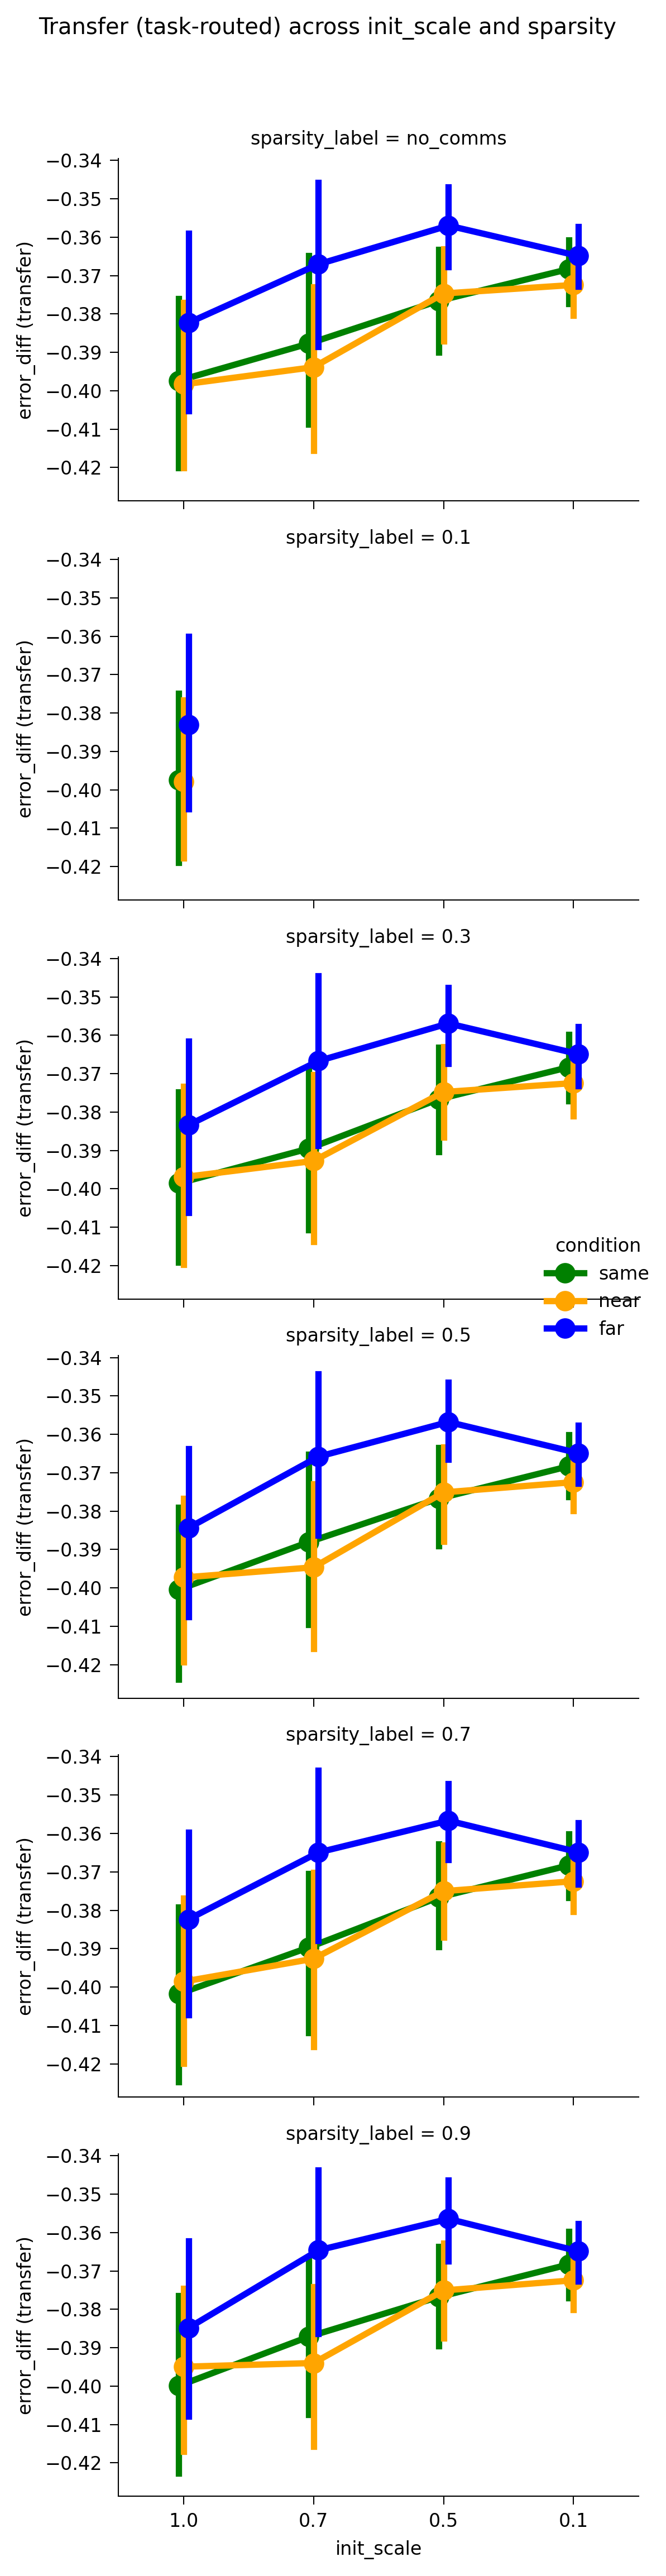

In [ ]:
if not transfer_df.empty:
    transfer_summary = (
        transfer_df.groupby(["sparsity_label", "init_scale", "condition"], as_index=False)["error_diff"].mean()
    )
    display(transfer_summary.head())

    # Plot: error_diff vs init_scale, rows = sparsity, hue = condition
    init_order = sorted(transfer_df["init_scale"].unique(), reverse=True)
    sp_order = ["no_comms", "0.1", "0.3", "0.5", "0.7", "0.9", "1.0"]
    sp_order = [s for s in sp_order if s in transfer_df["sparsity_label"].values]
    g = sns.catplot(
        data=transfer_df,
        x="init_scale",
        y="error_diff",
        hue="condition",
        palette=SIMILARITY_PALETTE,
        row="sparsity_label",
        kind="point",
        dodge=True,
        order=init_order,
        hue_order=["same", "near", "far"],
        row_order=sp_order,
        height=2.5,
        aspect=1.3,
    )
    g.set_axis_labels("init_scale", "error_diff (transfer)")
    g.fig.suptitle("Transfer (task-routed) across init_scale and sparsity", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No transfer data.")

## 6. Accuracy and loss across init_scale

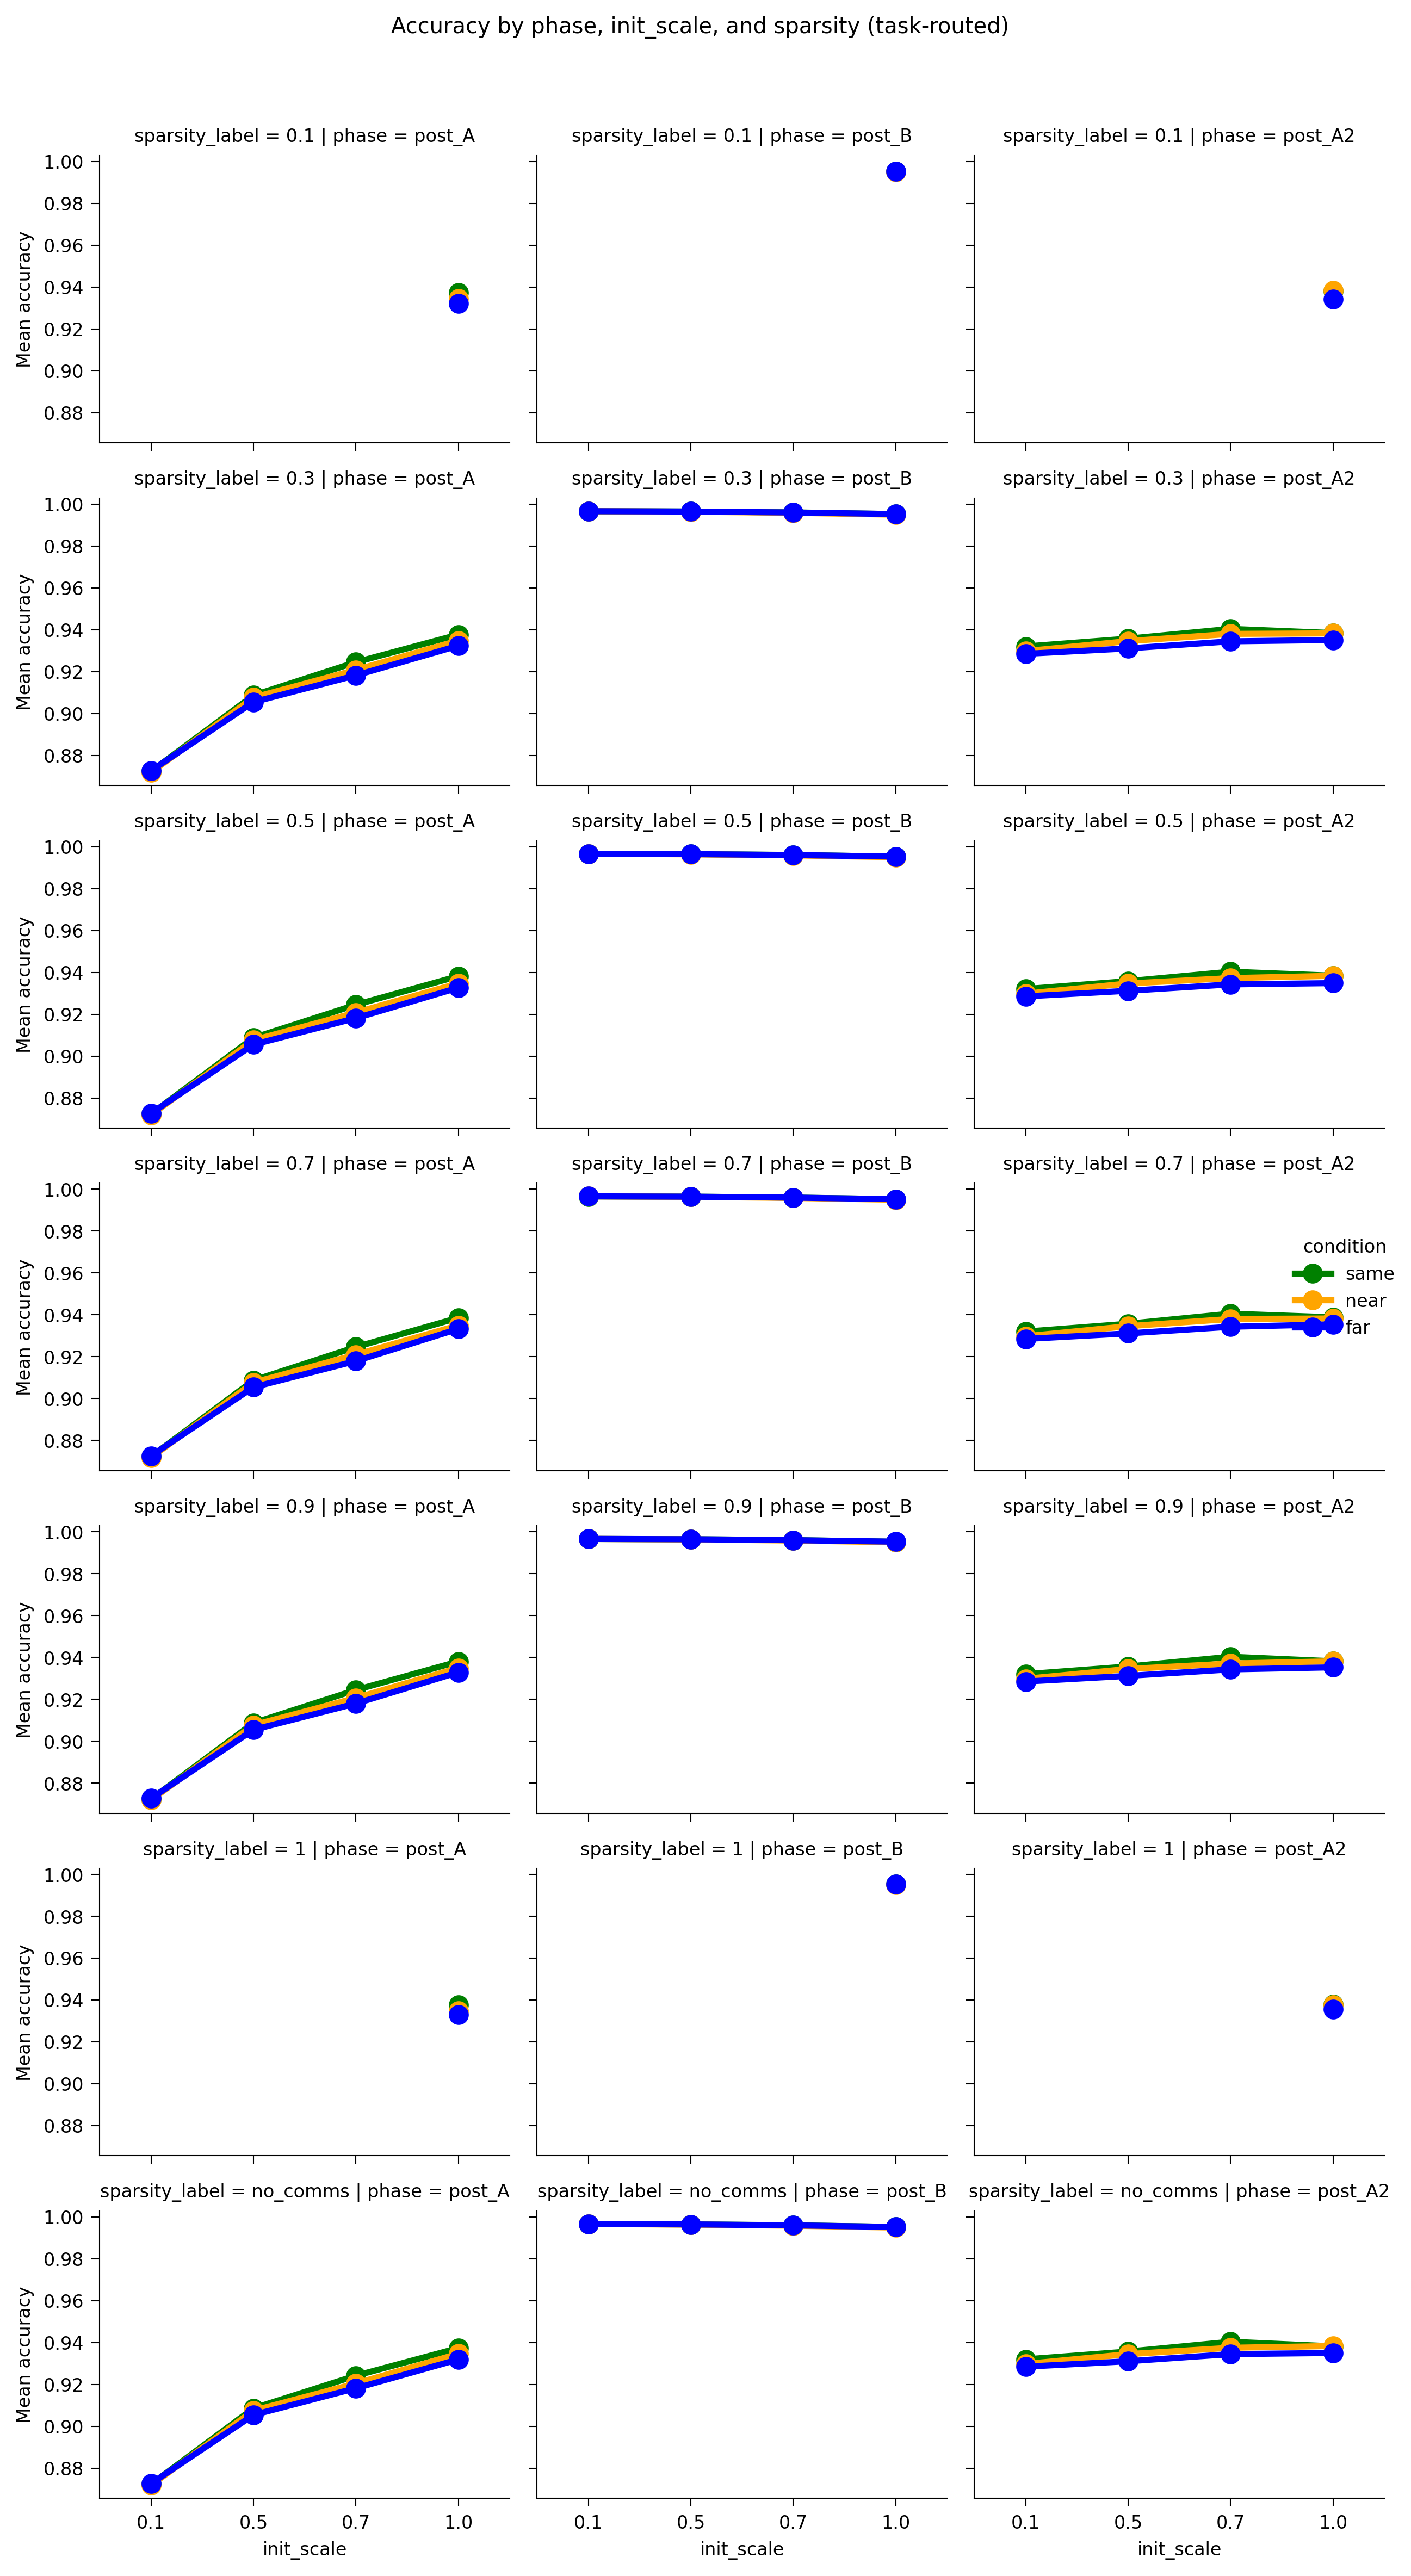

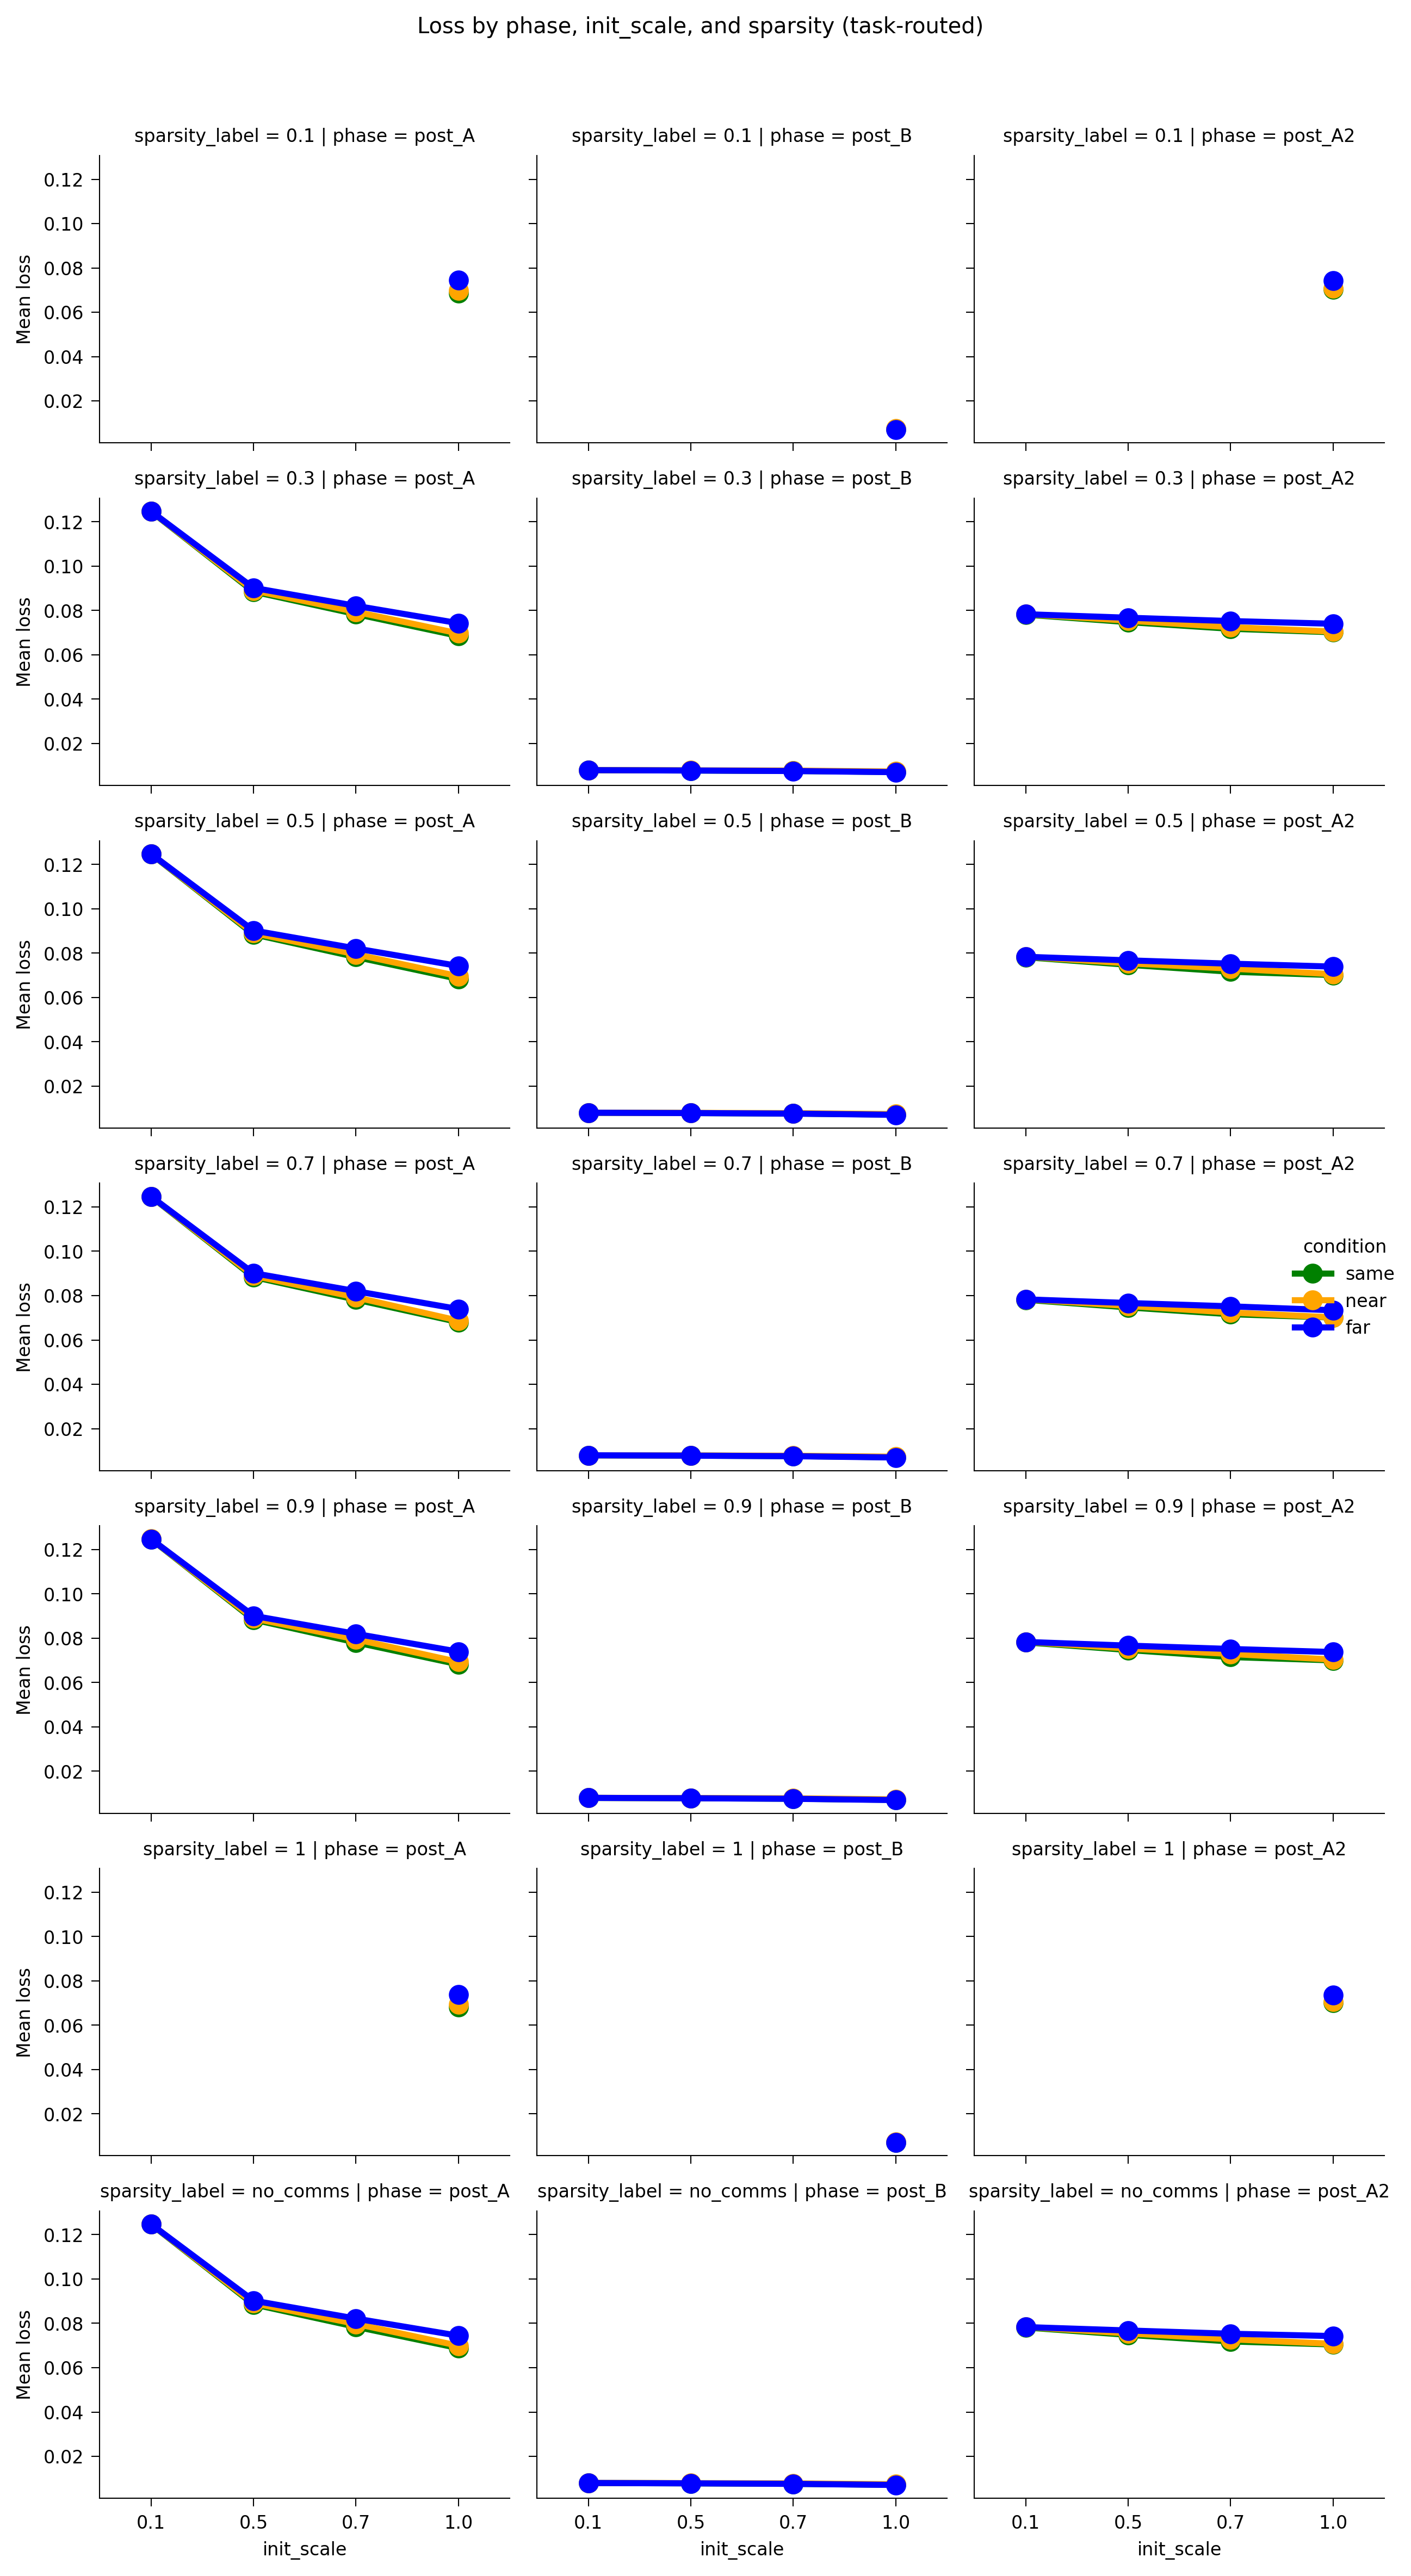

In [ ]:
phase_order = ["post_A", "post_B", "post_A2"]

if not accuracy_df.empty:
    acc_agg = (
        accuracy_df.groupby(["sparsity_label", "init_scale", "condition", "phase"], as_index=False)["mean_accuracy"].mean()
    )
    g = sns.catplot(
        data=acc_agg,
        x="init_scale",
        y="mean_accuracy",
        hue="condition",
        palette=SIMILARITY_PALETTE,
        col="phase",
        row="sparsity_label",
        kind="point",
        hue_order=["same", "near", "far"],
        col_order=phase_order,
        height=2.2,
        aspect=1.2,
    )
    g.set_axis_labels("init_scale", "Mean accuracy")
    g.fig.suptitle("Accuracy by phase, init_scale, and sparsity (task-routed)", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No accuracy data.")

if not loss_df.empty:
    loss_agg = (
        loss_df.groupby(["sparsity_label", "init_scale", "condition", "phase"], as_index=False)["mean_loss"].mean()
    )
    g = sns.catplot(
        data=loss_agg,
        x="init_scale",
        y="mean_loss",
        hue="condition",
        palette=SIMILARITY_PALETTE,
        col="phase",
        row="sparsity_label",
        kind="point",
        hue_order=["same", "near", "far"],
        col_order=phase_order,
        height=2.2,
        aspect=1.2,
    )
    g.set_axis_labels("init_scale", "Mean loss")
    g.fig.suptitle("Loss by phase, init_scale, and sparsity (task-routed)", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No loss data.")

## 7. PCA dimensionality across init_scale (post-A2)

,run_id,sparsity_label,init_scale,condition,phase,pathway,var_topk,n_pcs_95,n_pcs_99
0,two_module_rnn_25_task_routed_low_sparse_nb2_i...,0.3,0.1,far,post_A,combined,0.949429,2.475248,3.000000
1,two_module_rnn_25_task_routed_low_sparse_nb2_i...,0.3,0.1,far,post_A,comms,0.948045,2.495050,3.000000
2,two_module_rnn_25_task_routed_low_sparse_nb2_i...,0.3,0.1,far,post_A,core,0.950544,2.425743,3.000000
3,two_module_rnn_25_task_routed_low_sparse_nb2_i...,0.3,0.1,far,post_A2,combined,0.598149,4.000000,4.000000
4,two_module_rnn_25_task_routed_low_sparse_nb2_i...,0.3,0.1,far,post_A2,comms,0.613927,4.000000,4.000000
...,...,...,...,...,...,...,...,...,...
463,two_module_rnn_25_task_routed_sp09_nb2_nb2_tas...,0.9,1.0,near,post_A2,combined,0.592273,9.039604,11.000000
464,two_module_rnn_25_task_routed_sp09_nb2_nb2_tas...,0.9,1.0,near,post_B,combined,0.607454,9.009901,11.000000
465,two_module_rnn_25_task_routed_sp09_nb2_nb2_tas...,0.9,1.0,same,post_A,combined,0.494210,9.543689,11.000000
466,two_module_rnn_25_task_routed_sp09_nb2_nb2_tas...,0.9,1.0,same,post_A2,combined,0.600737,9.009709,11.000000


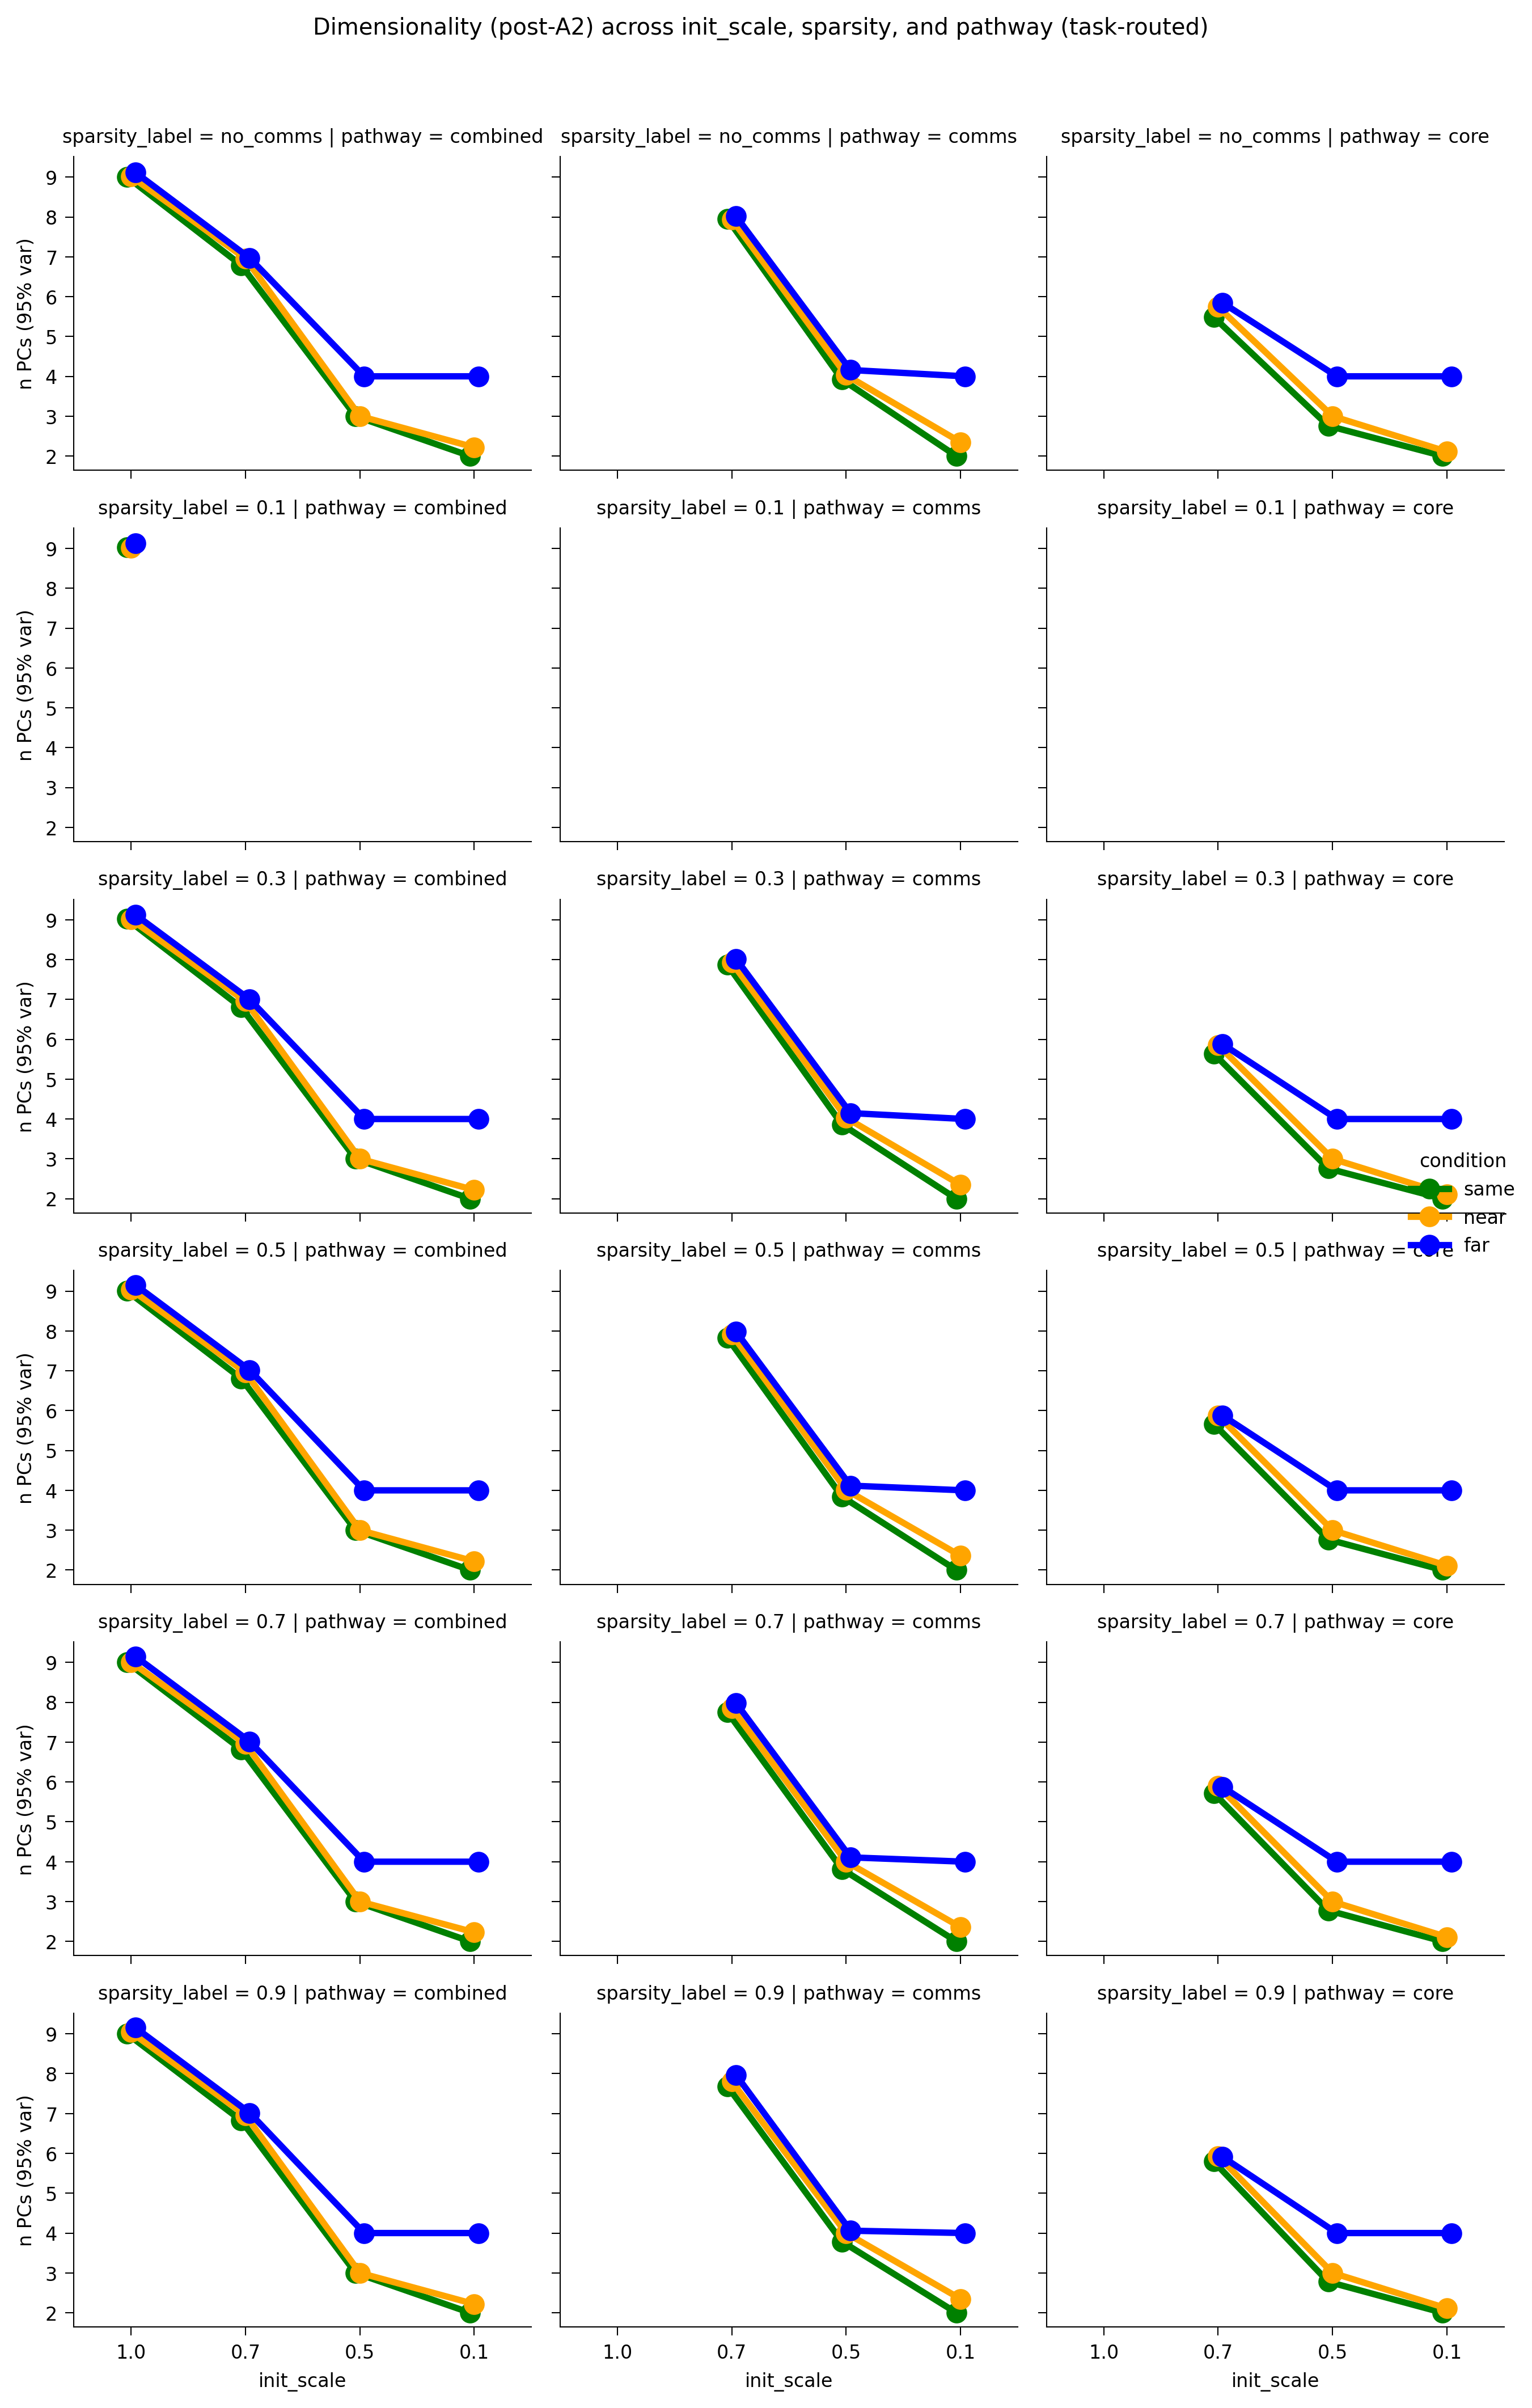

In [ ]:
if not rep_df.empty:
    agg_dict = {c: "mean" for c in ["var_topk", "n_pcs_95", "n_pcs_99"] if c in rep_df.columns}
    rep_summary = rep_df.groupby(
        ["run_id", "sparsity_label", "init_scale", "condition", "phase", "pathway"], as_index=False
    ).agg(agg_dict)
    display(rep_summary)

    # n_pcs_95 vs init_scale, by sparsity and pathway
    if "n_pcs_95" in rep_summary.columns:
        sub = rep_summary[rep_summary["phase"] == "post_A2"]
        init_order = sorted(sub["init_scale"].unique(), reverse=True)
        sp_order = ["no_comms", "0.1", "0.3", "0.5", "0.7", "0.9", "1.0"]
        sp_order = [s for s in sp_order if s in sub["sparsity_label"].values]
        g = sns.catplot(
            data=sub,
            x="init_scale",
            y="n_pcs_95",
            hue="condition",
            palette=SIMILARITY_PALETTE,
            col="pathway",
            row="sparsity_label",
            kind="point",
            dodge=True,
            order=init_order,
            hue_order=["same", "near", "far"],
            row_order=sp_order,
            height=2.3,
            aspect=1.2,
        )
        g.set_axis_labels("init_scale", "n PCs (95% var)")
        g.fig.suptitle("Dimensionality (post-A2) across init_scale, sparsity, and pathway (task-routed)", y=1.02)
        plt.tight_layout()
        plt.show()
else:
    rep_summary = pd.DataFrame()
    print("No representation data.")

## 8. PCA geometry (PC1–PC2, combined, post-A2)

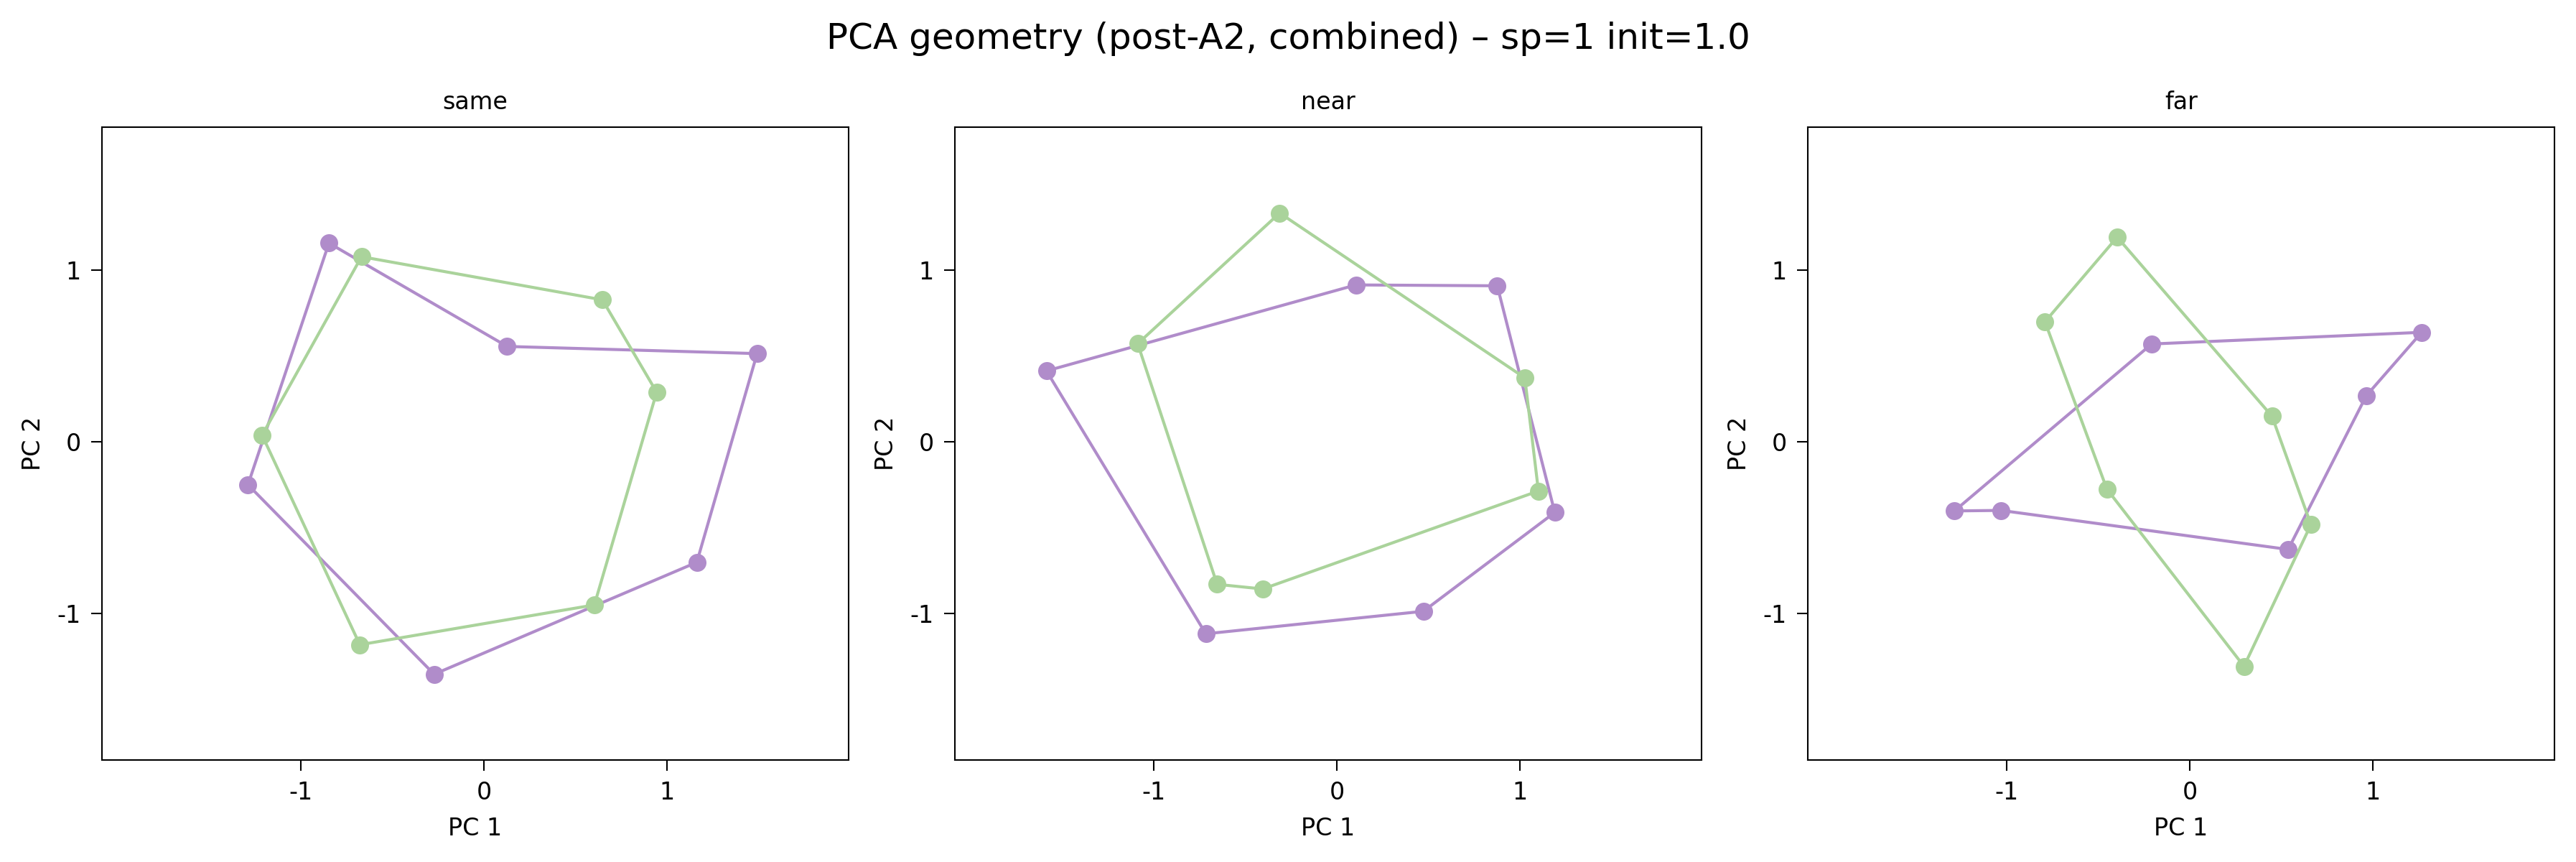

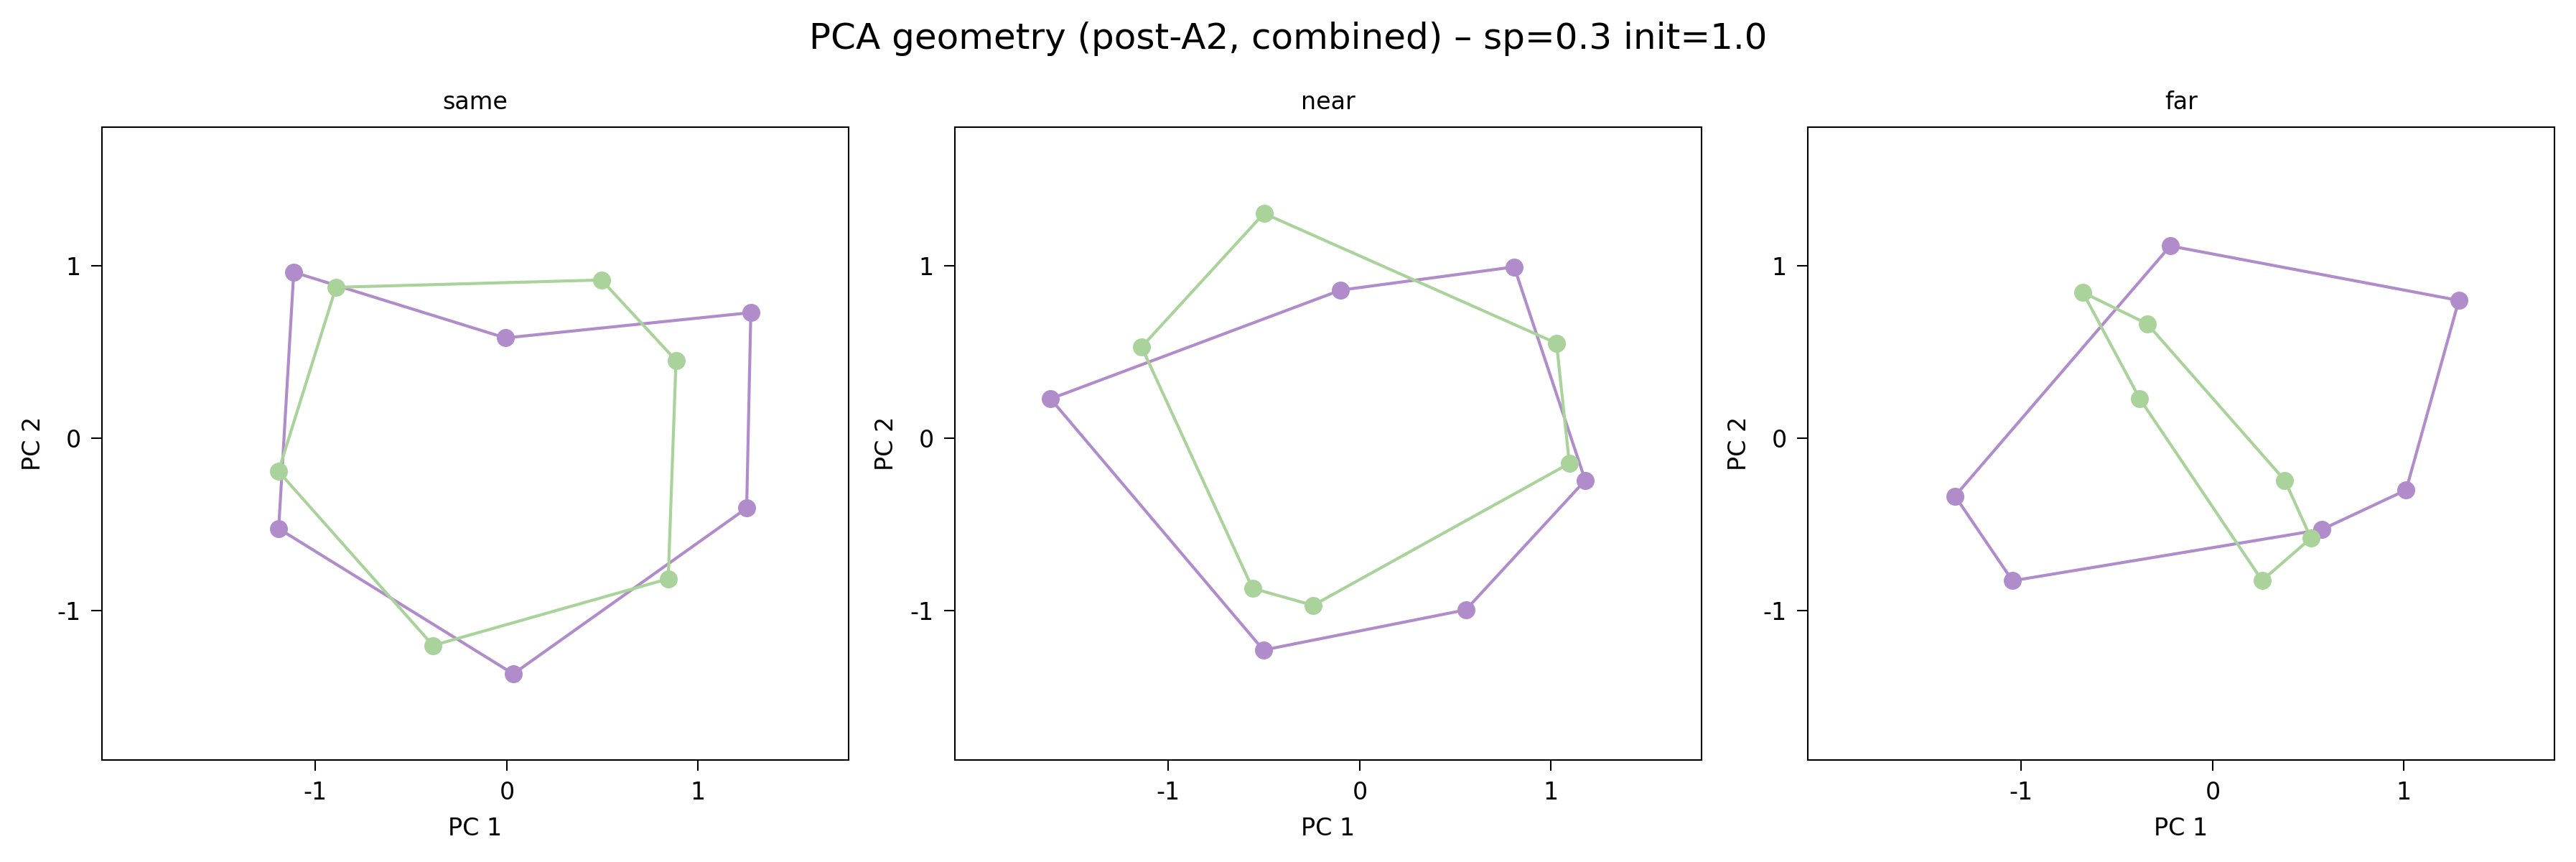

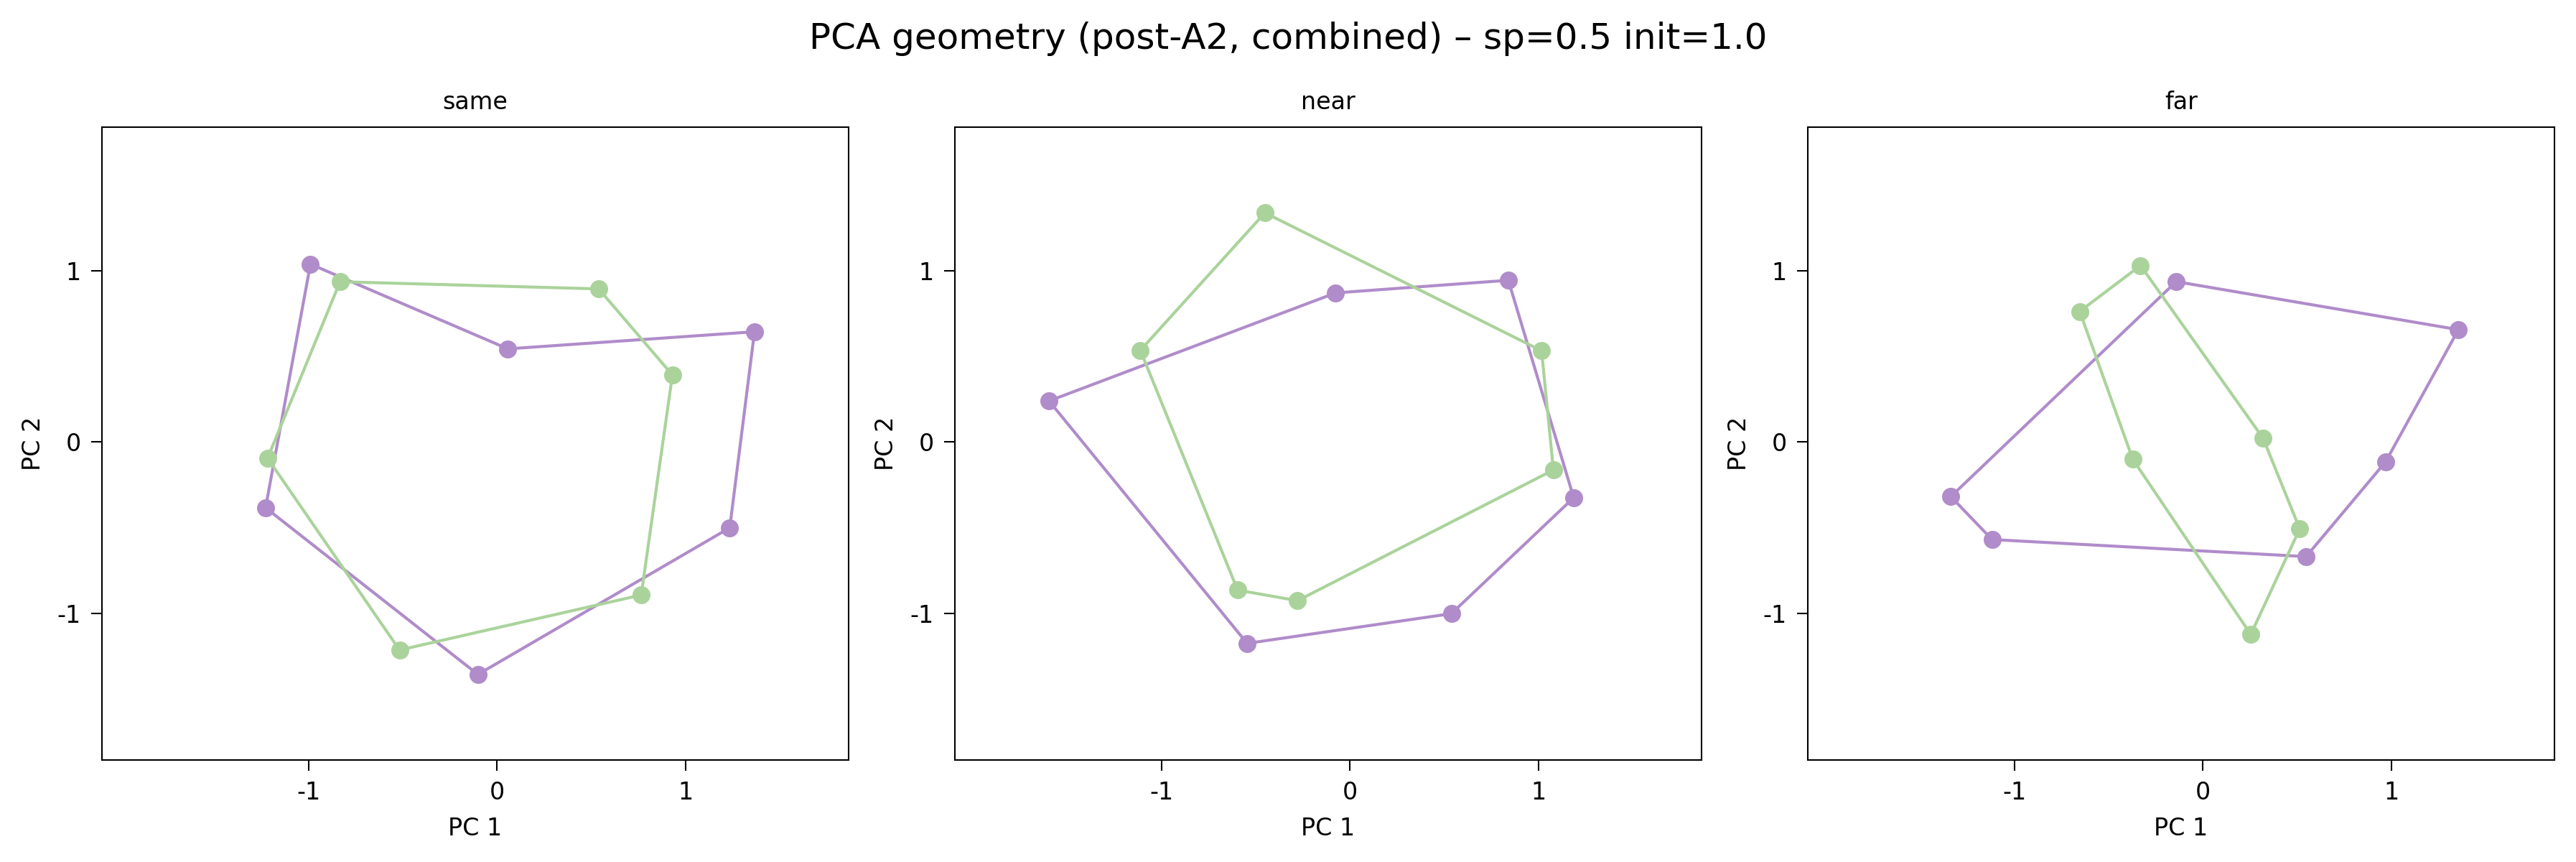

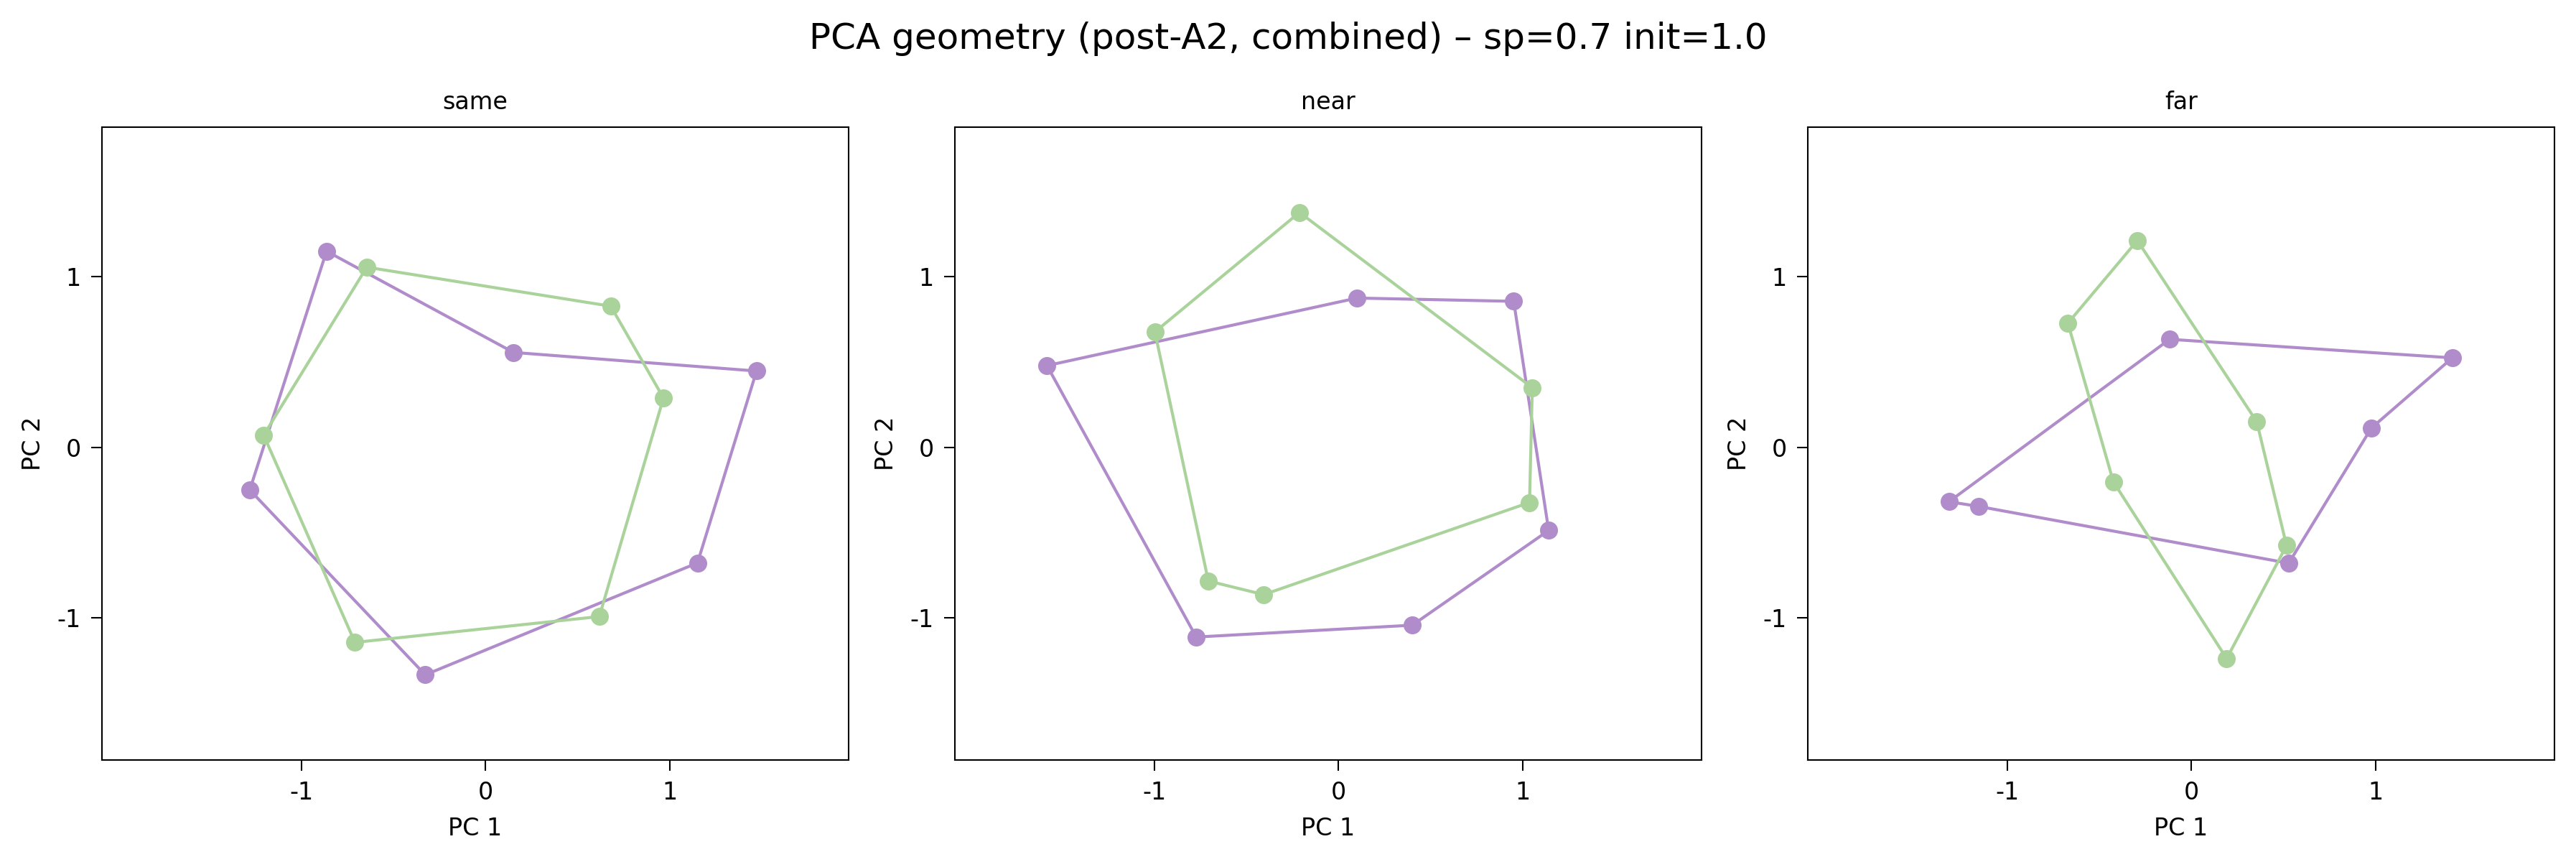

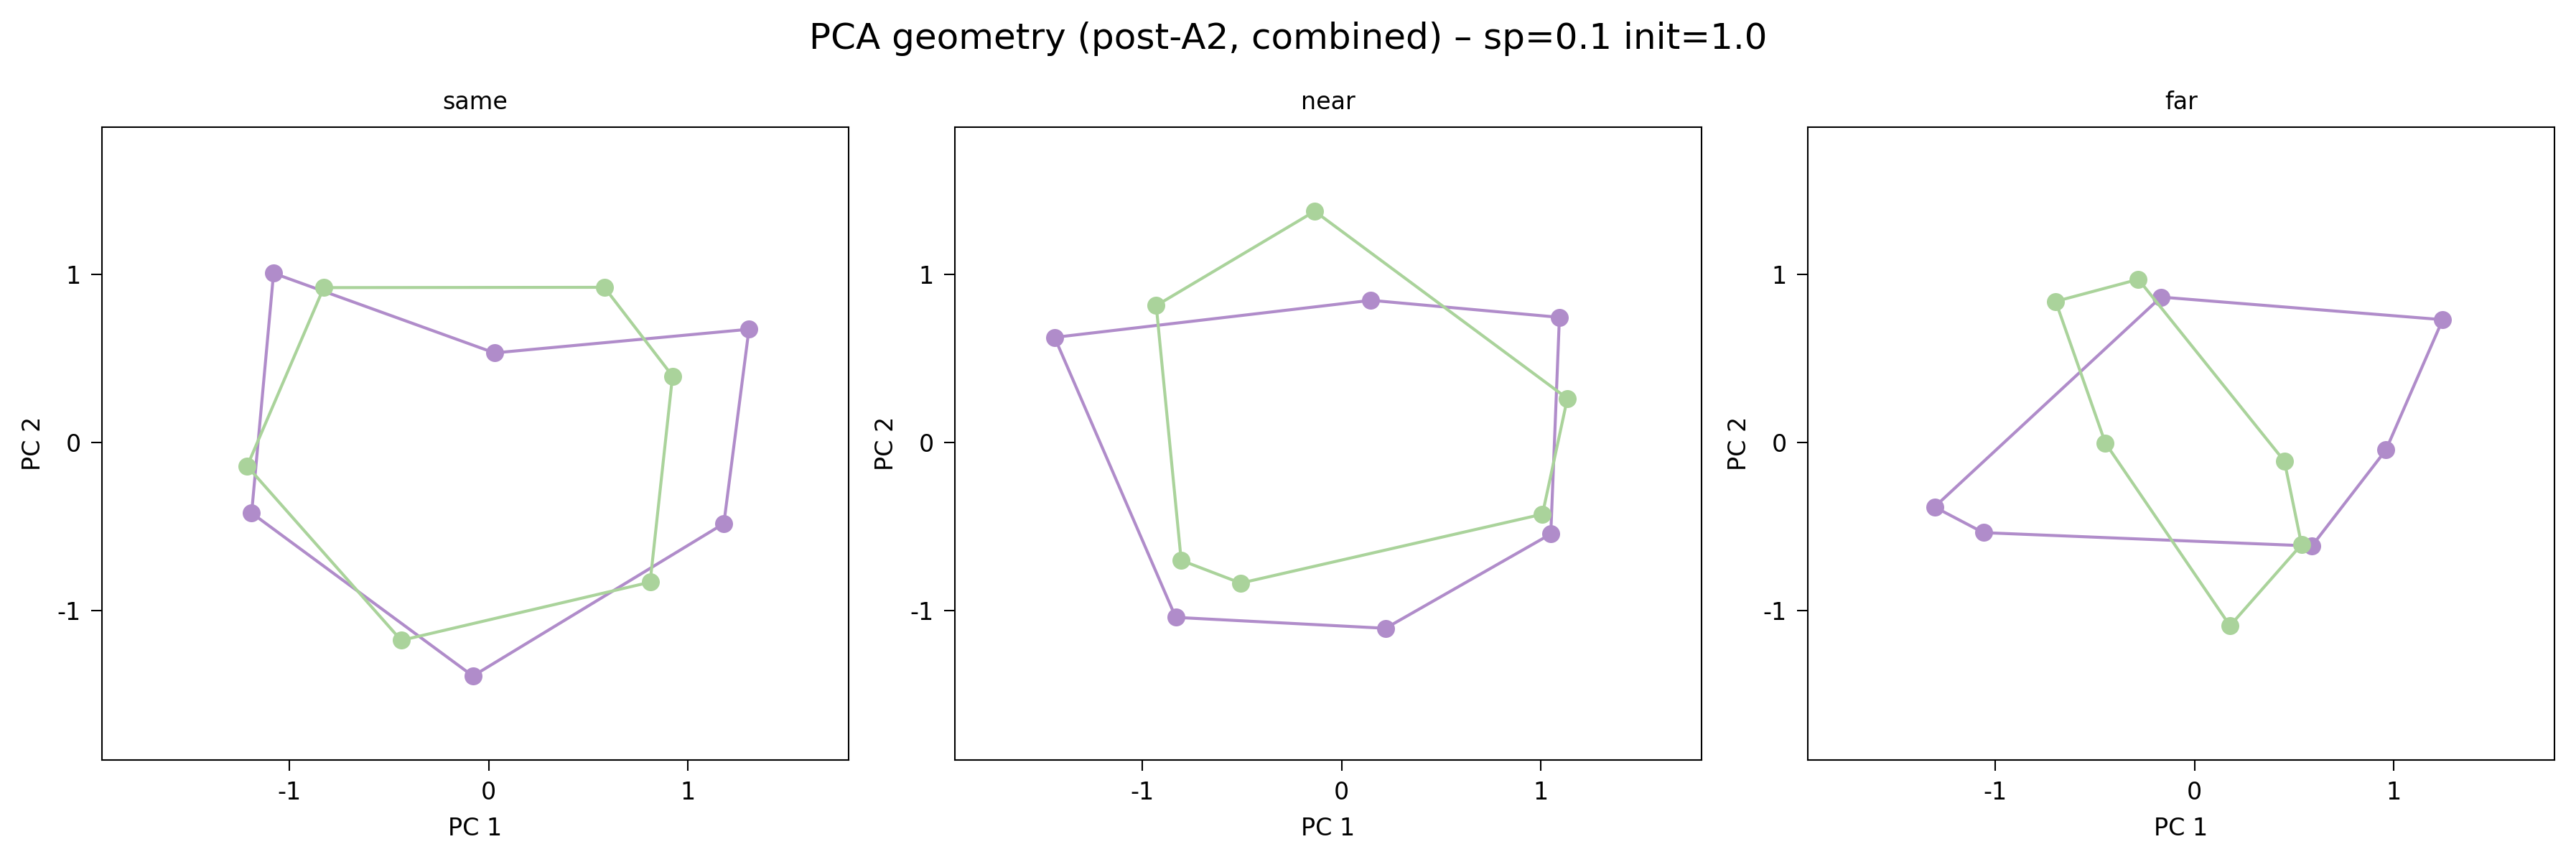

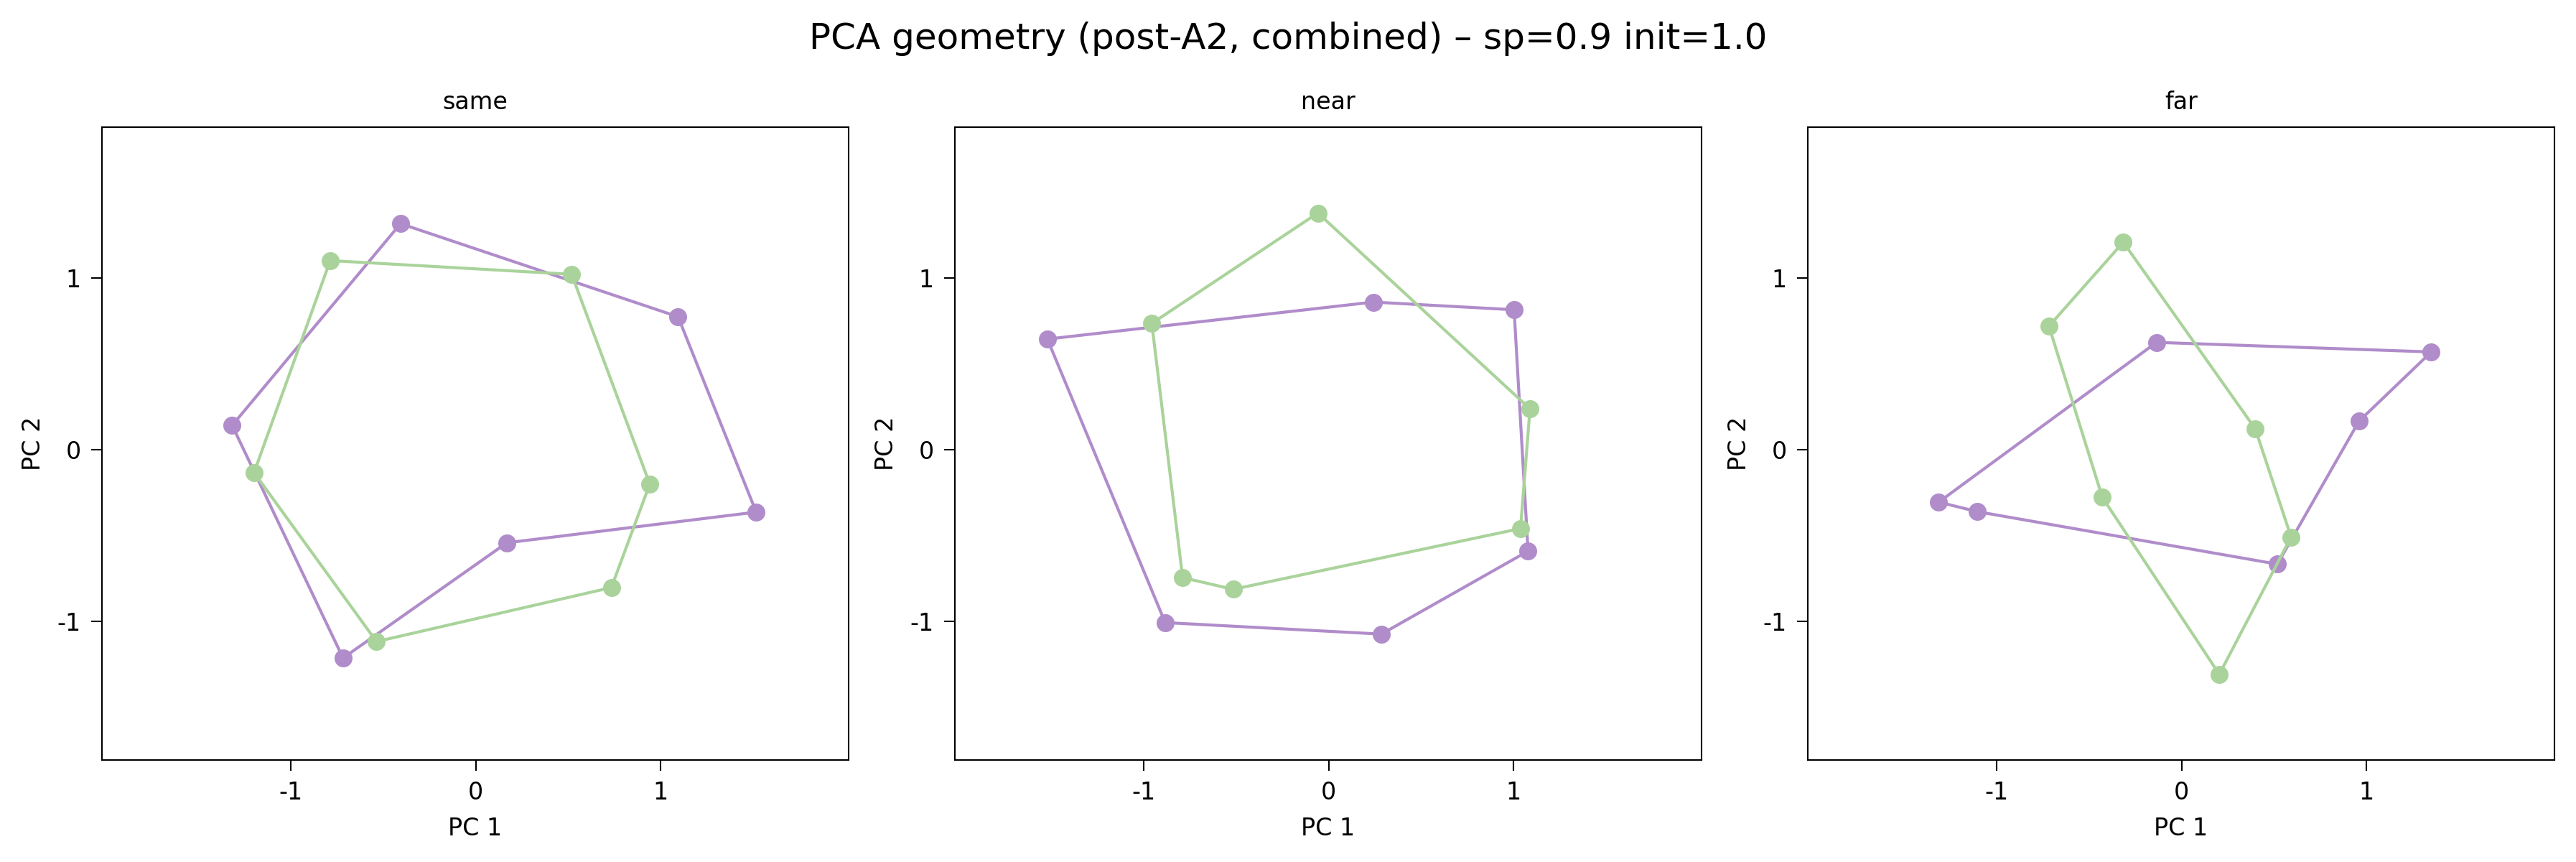

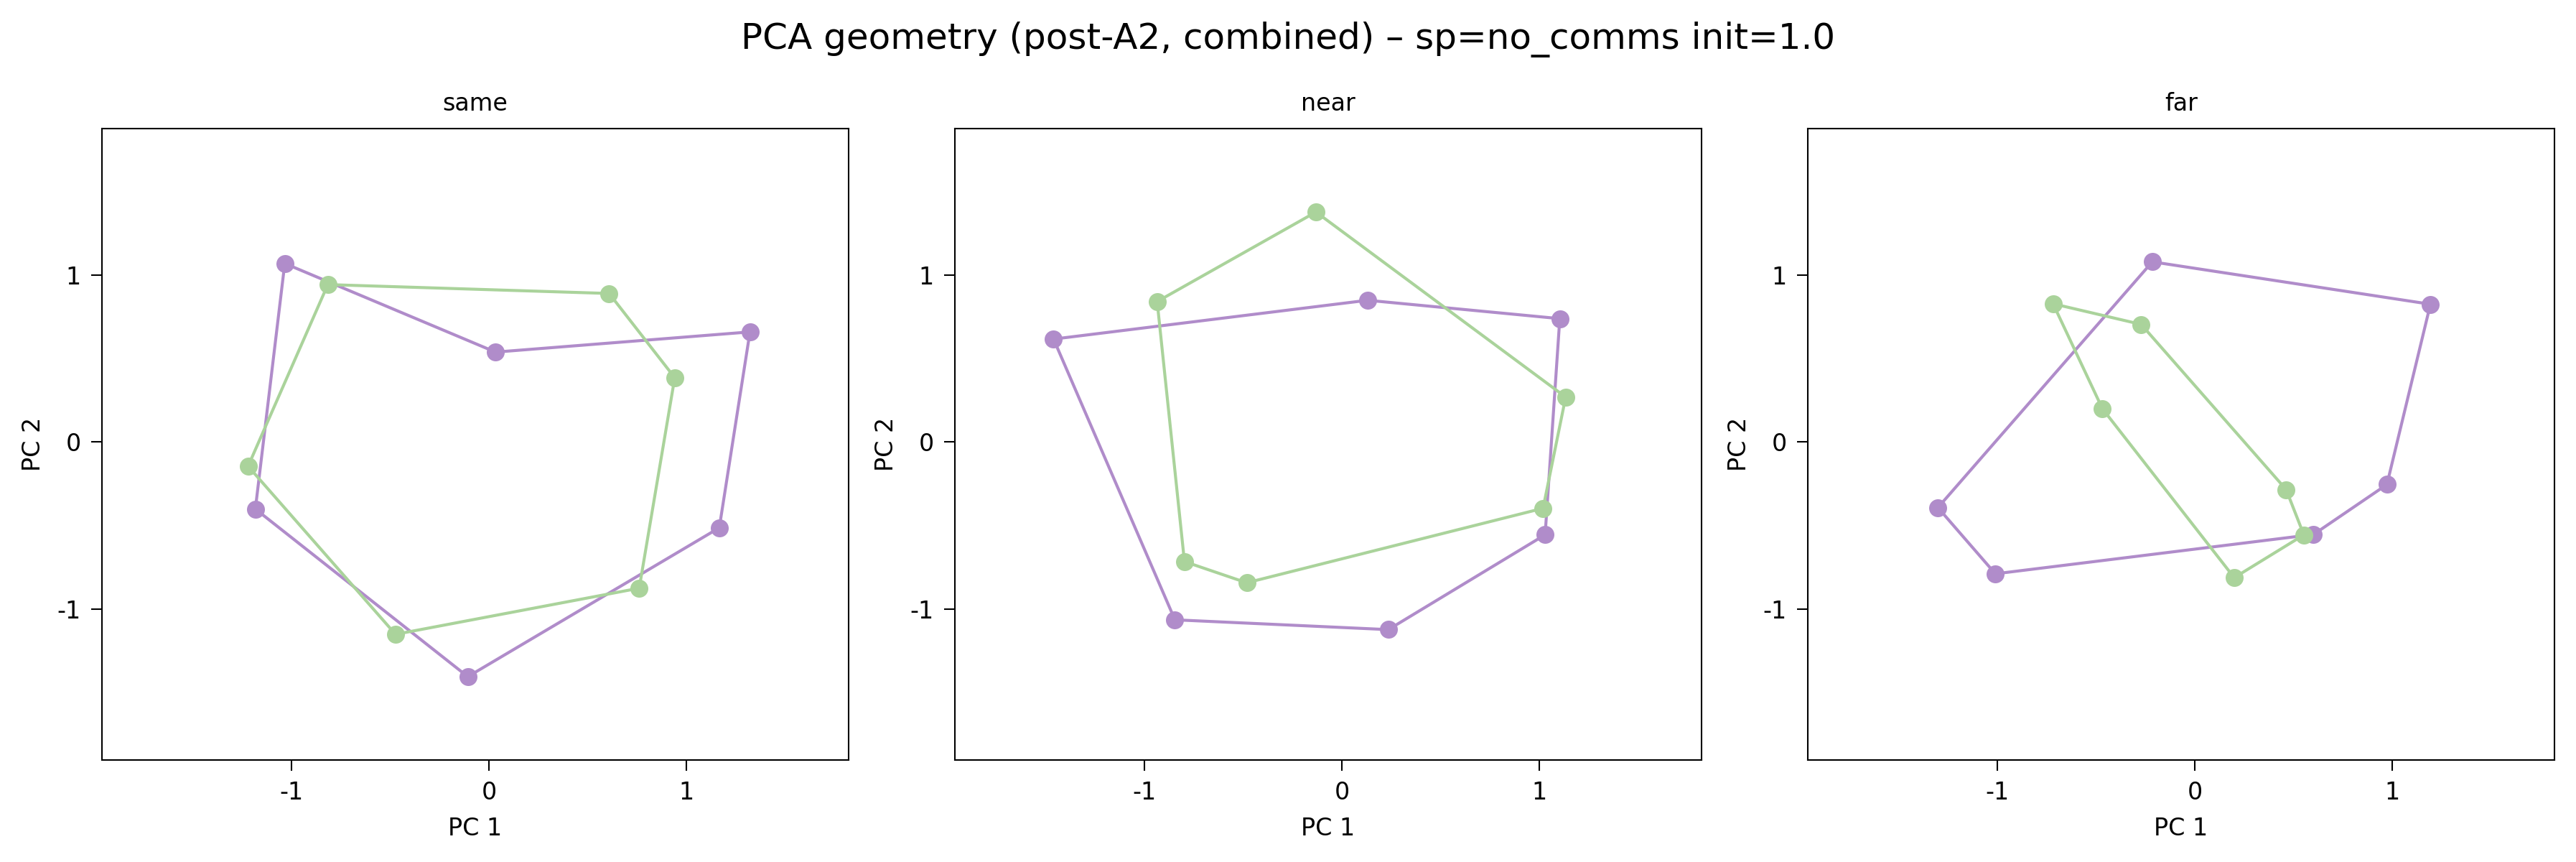

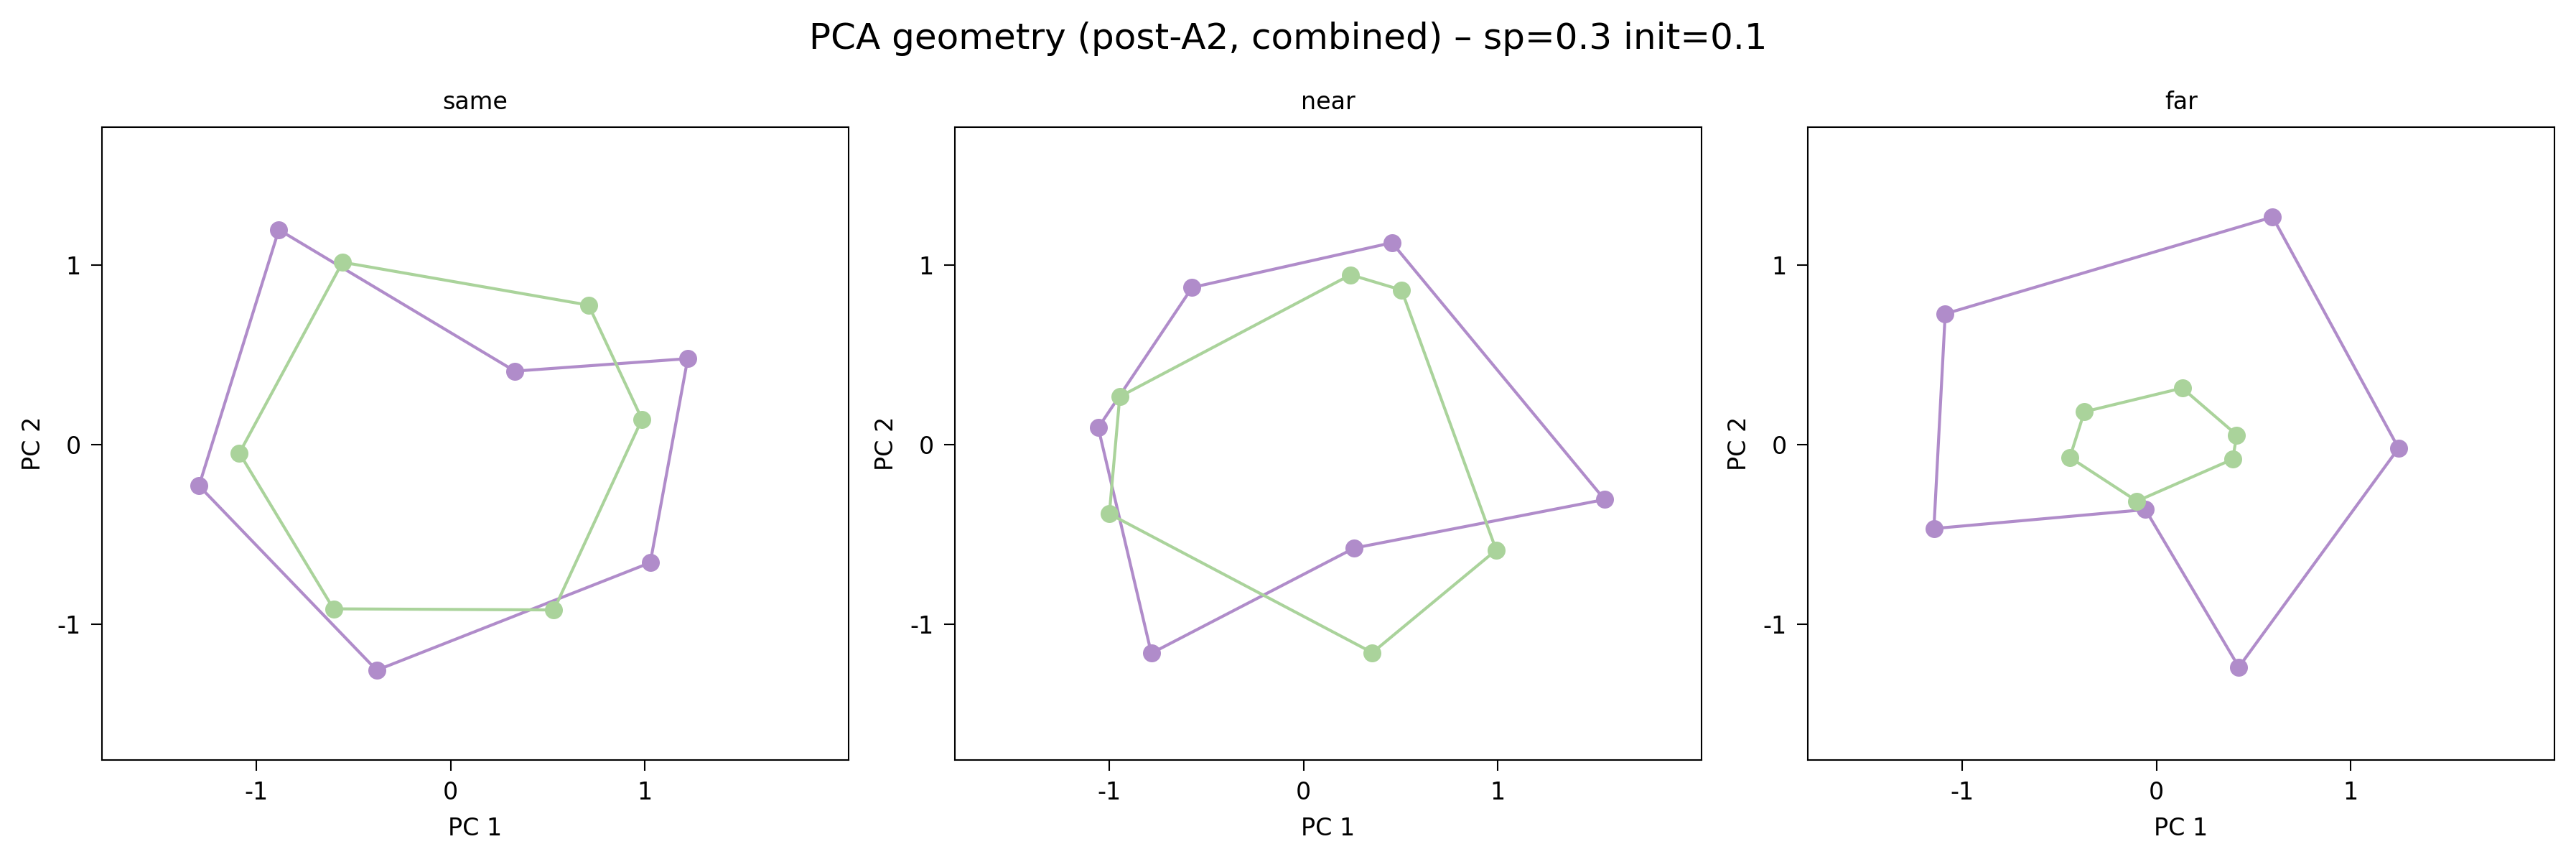

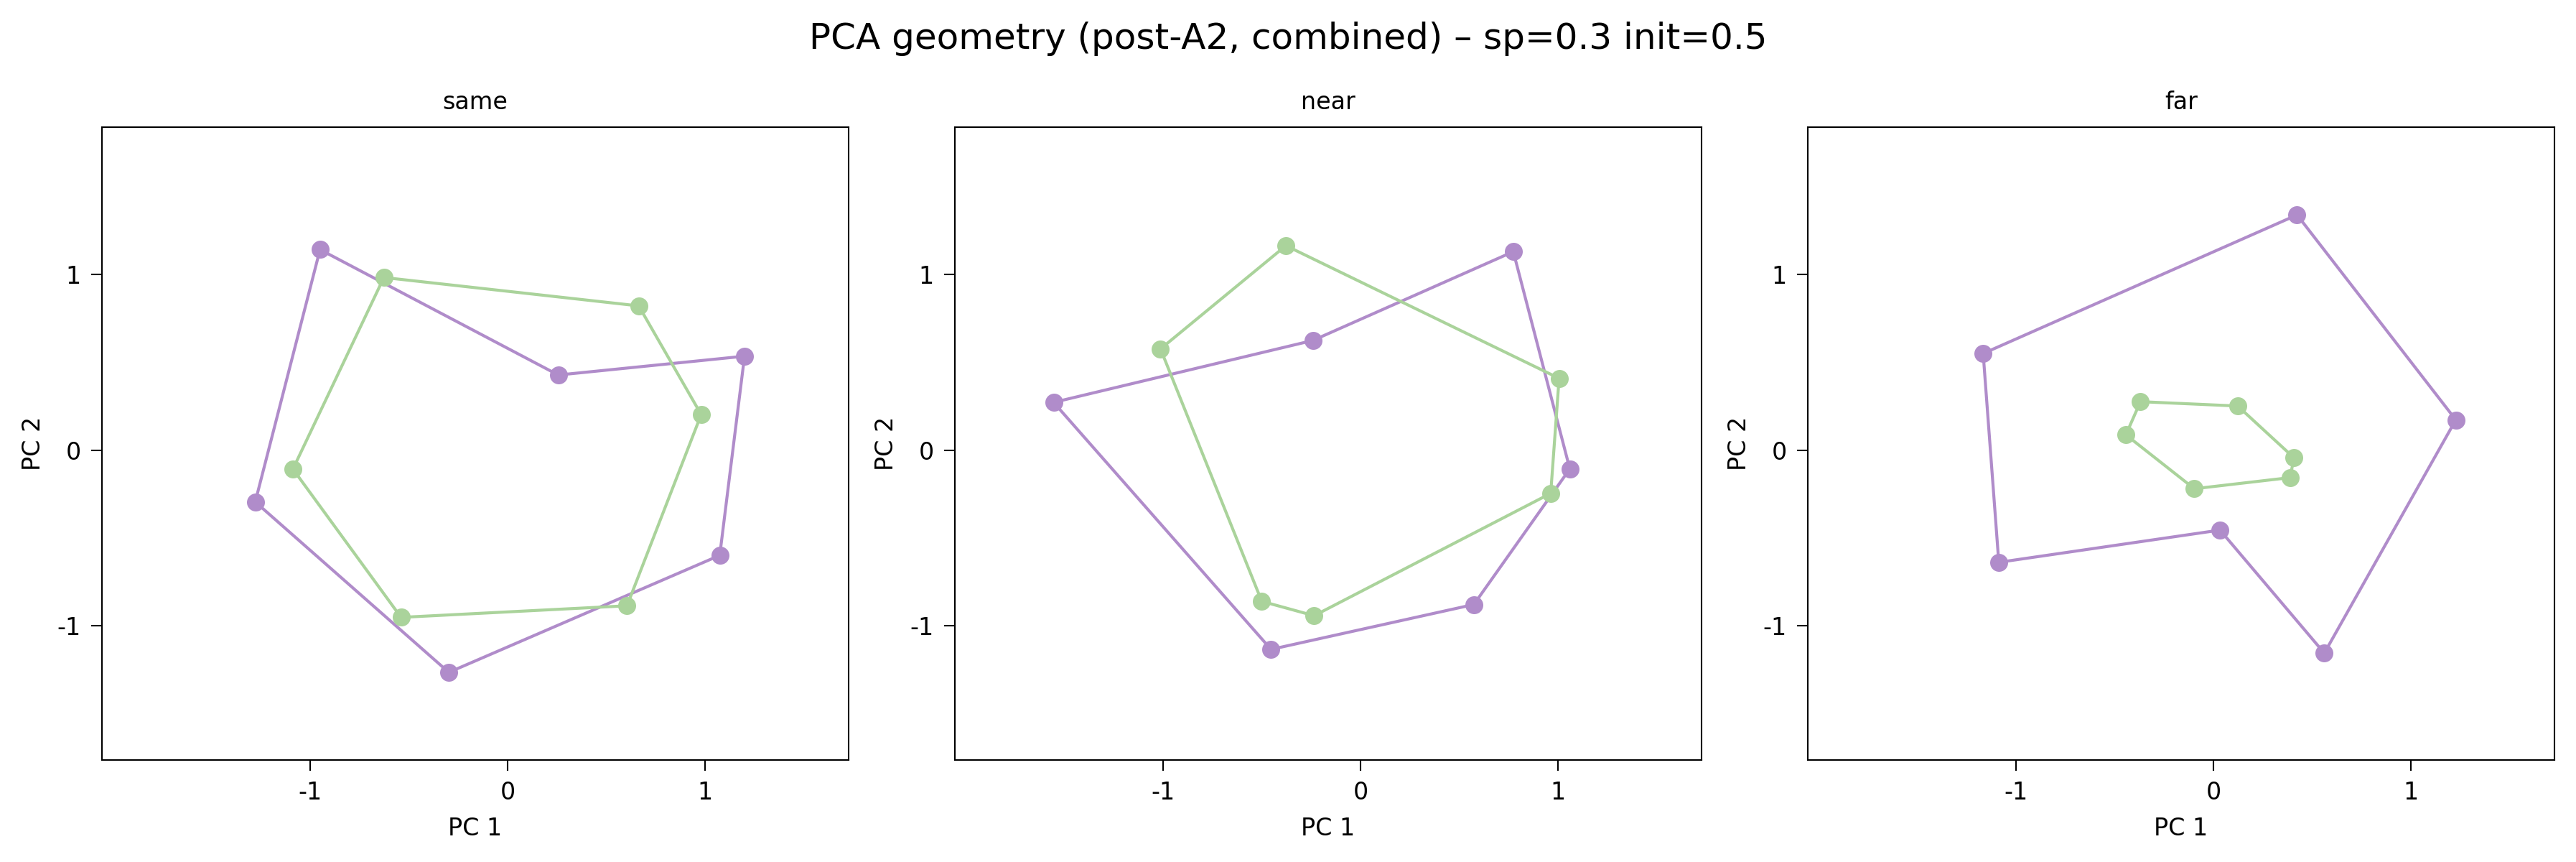

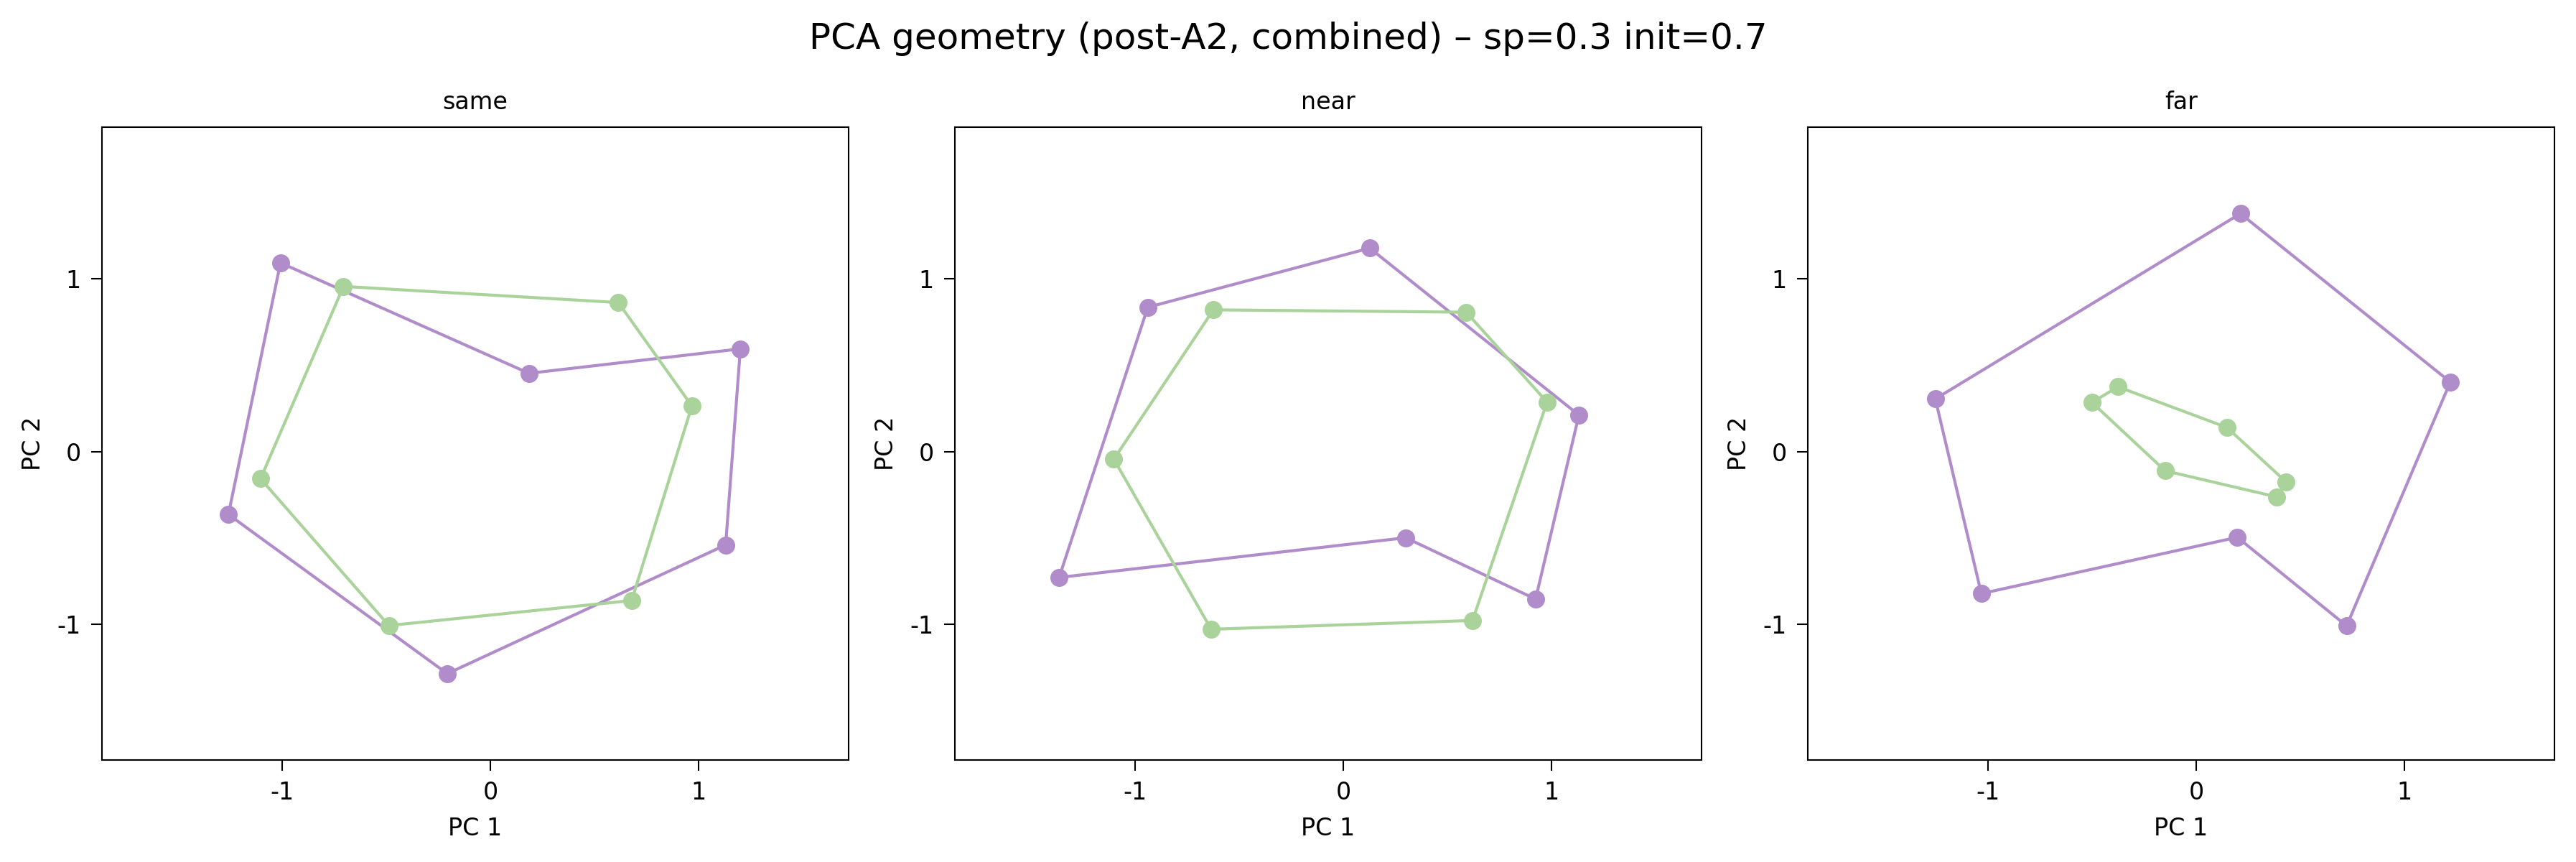

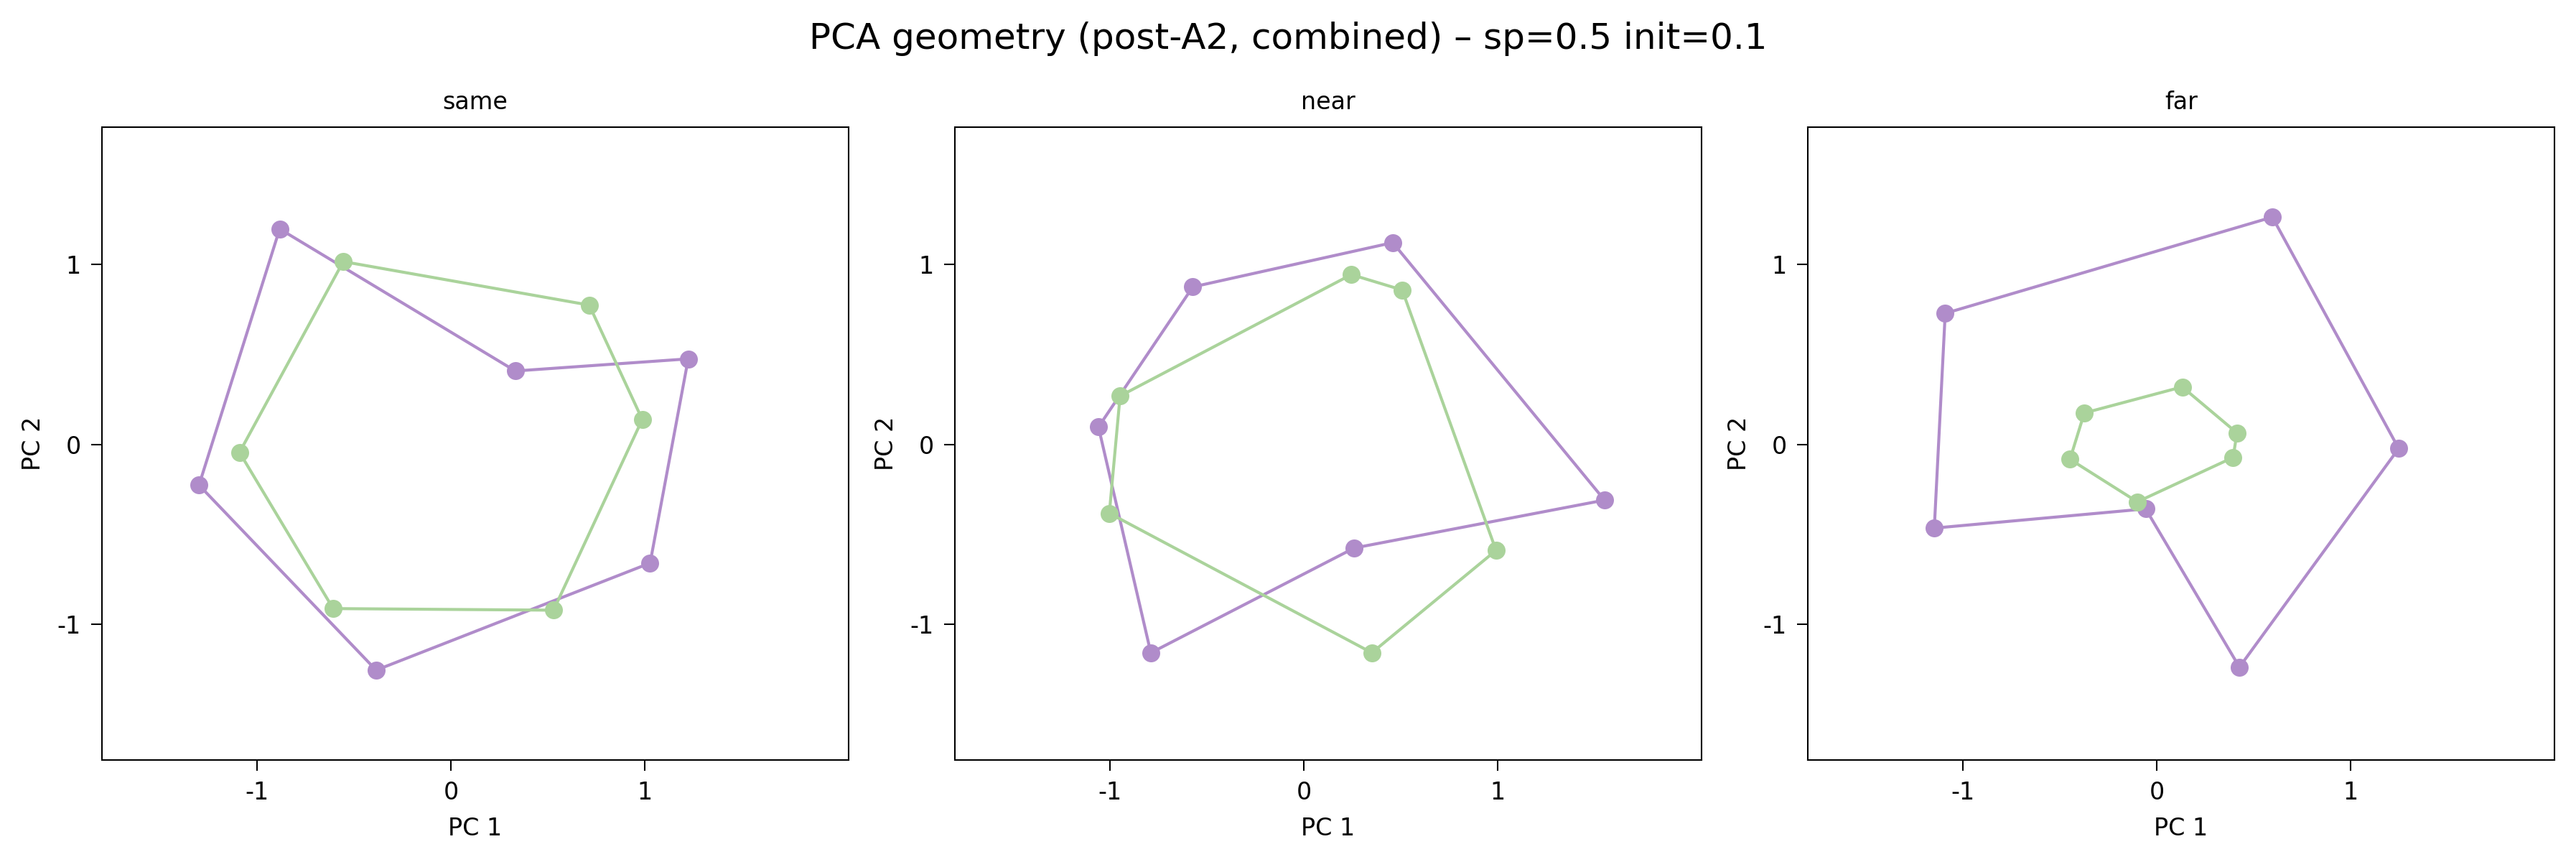

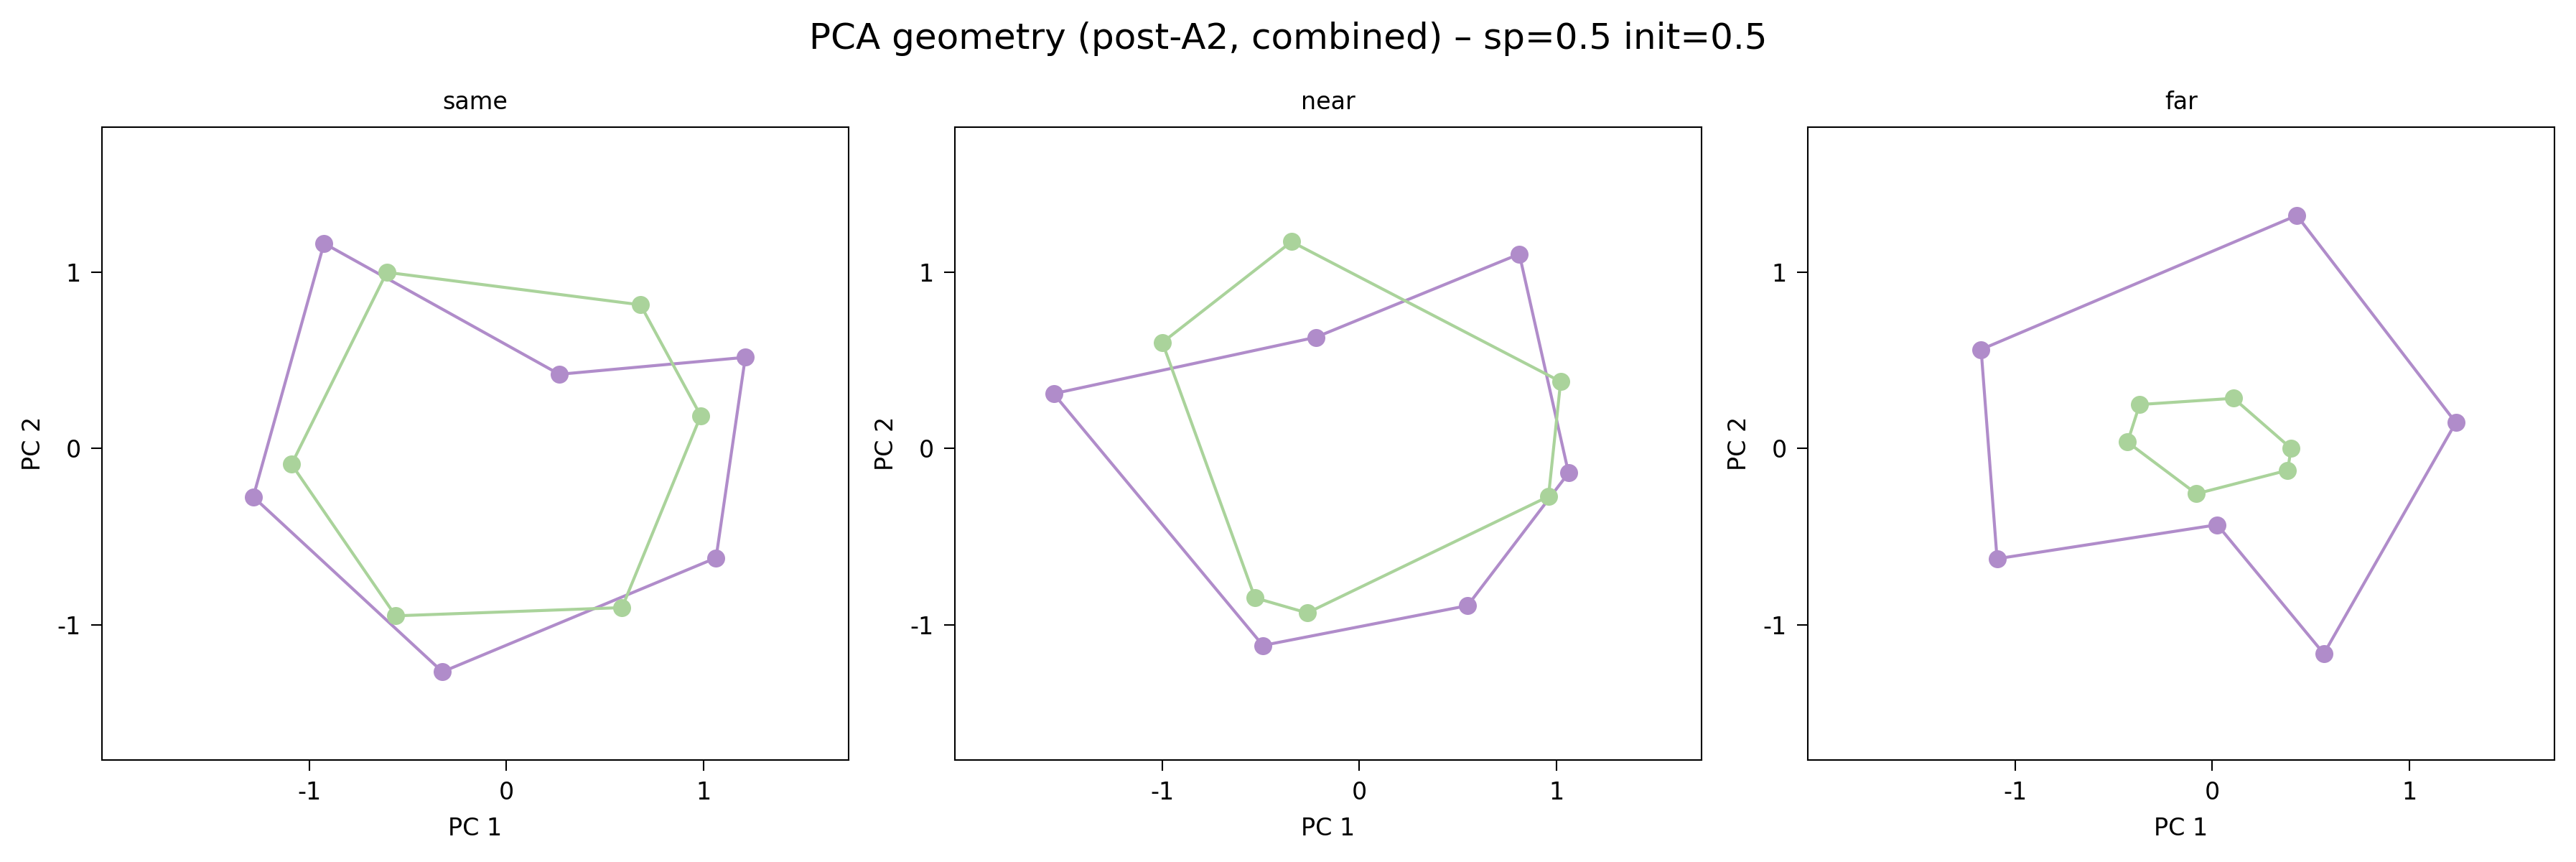

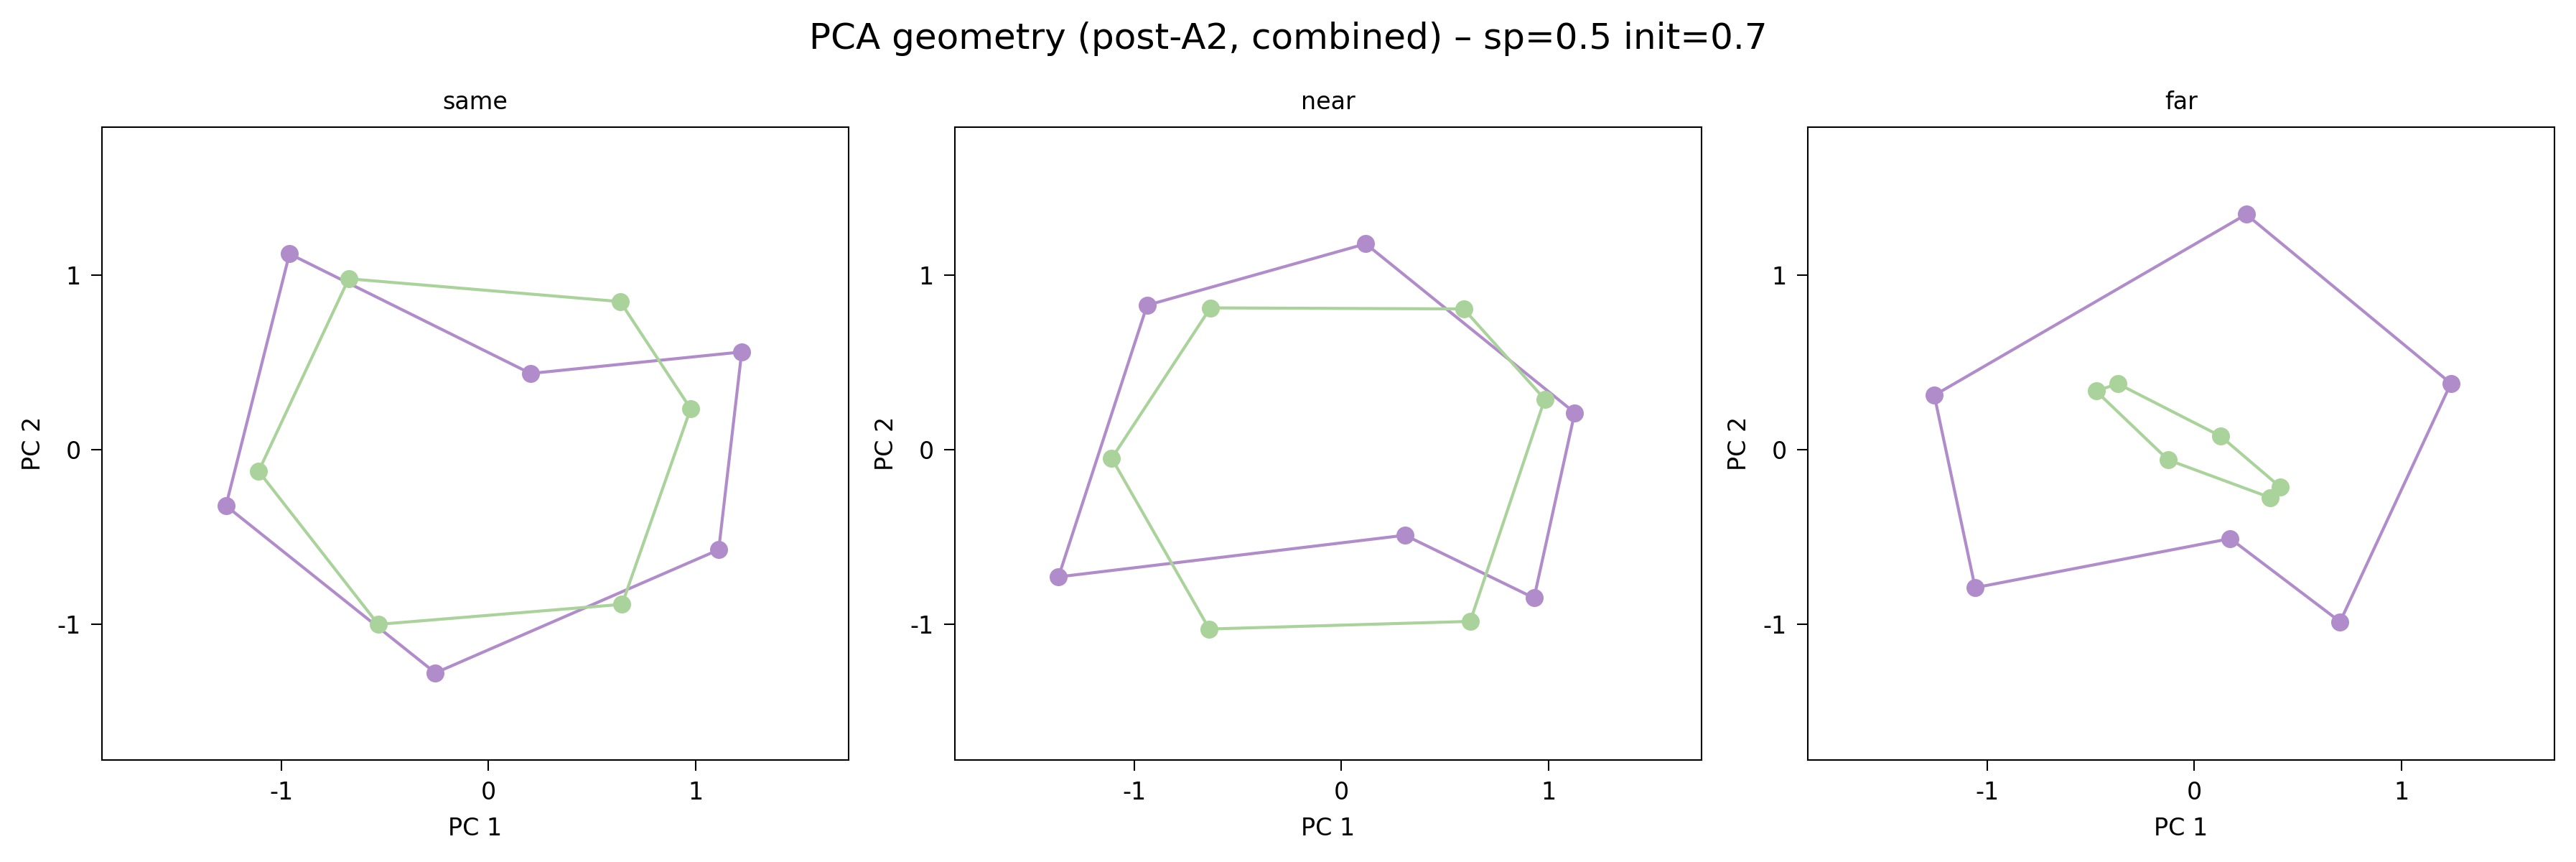

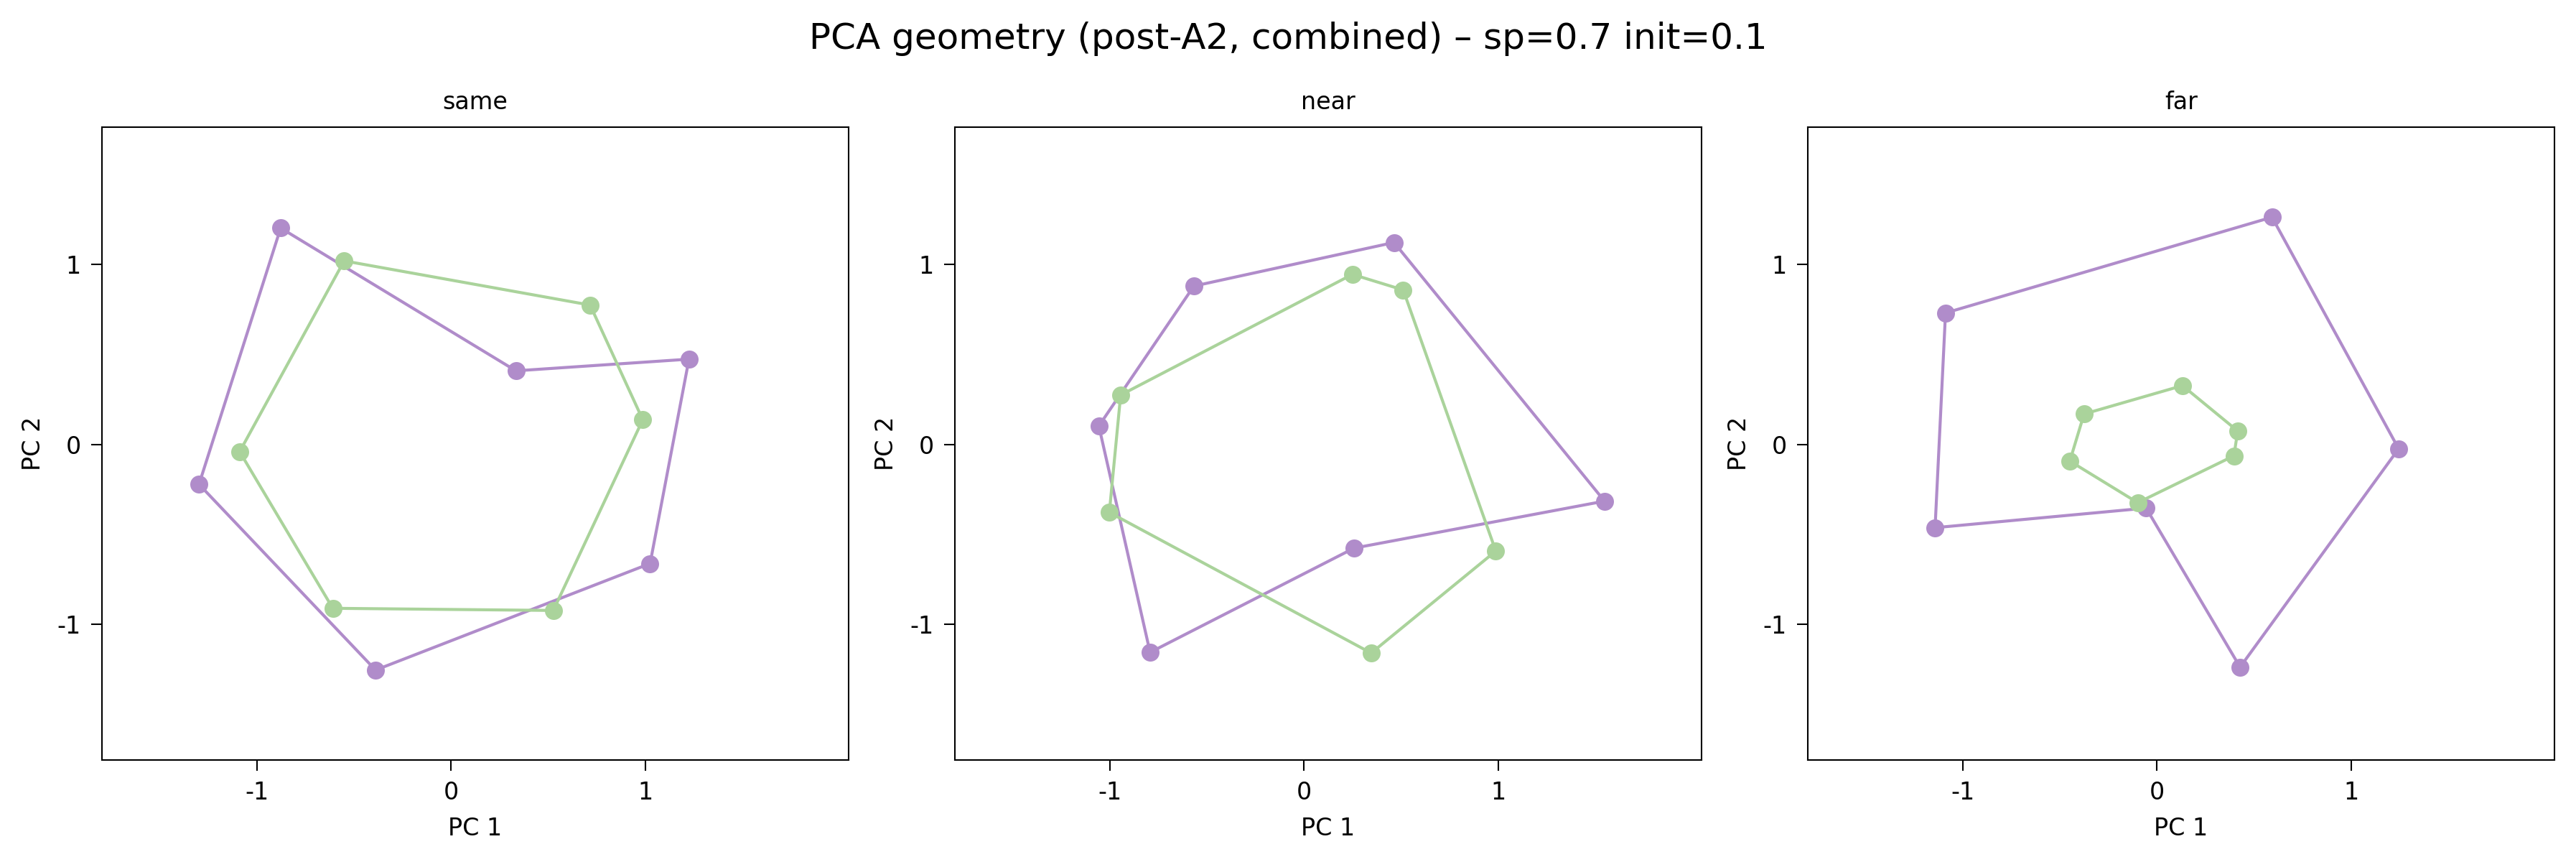

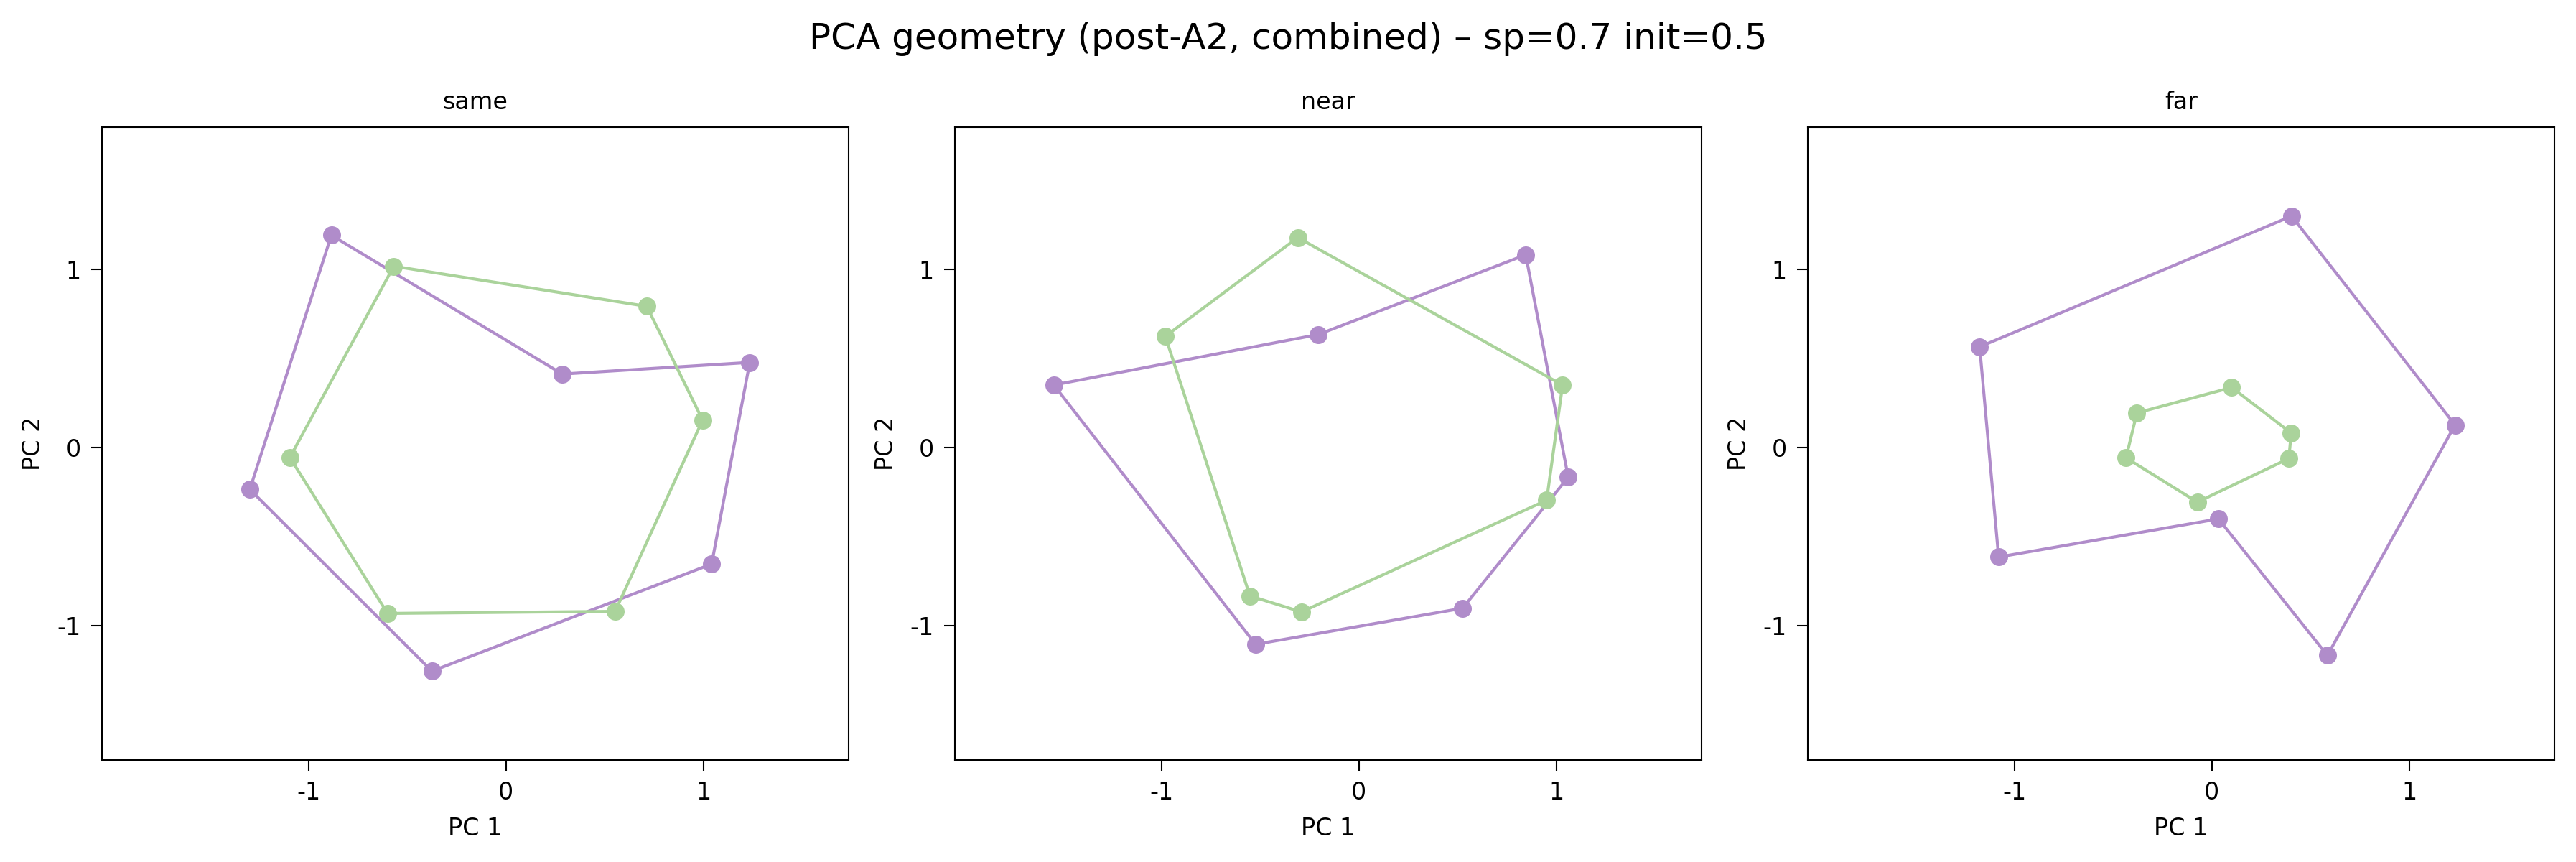

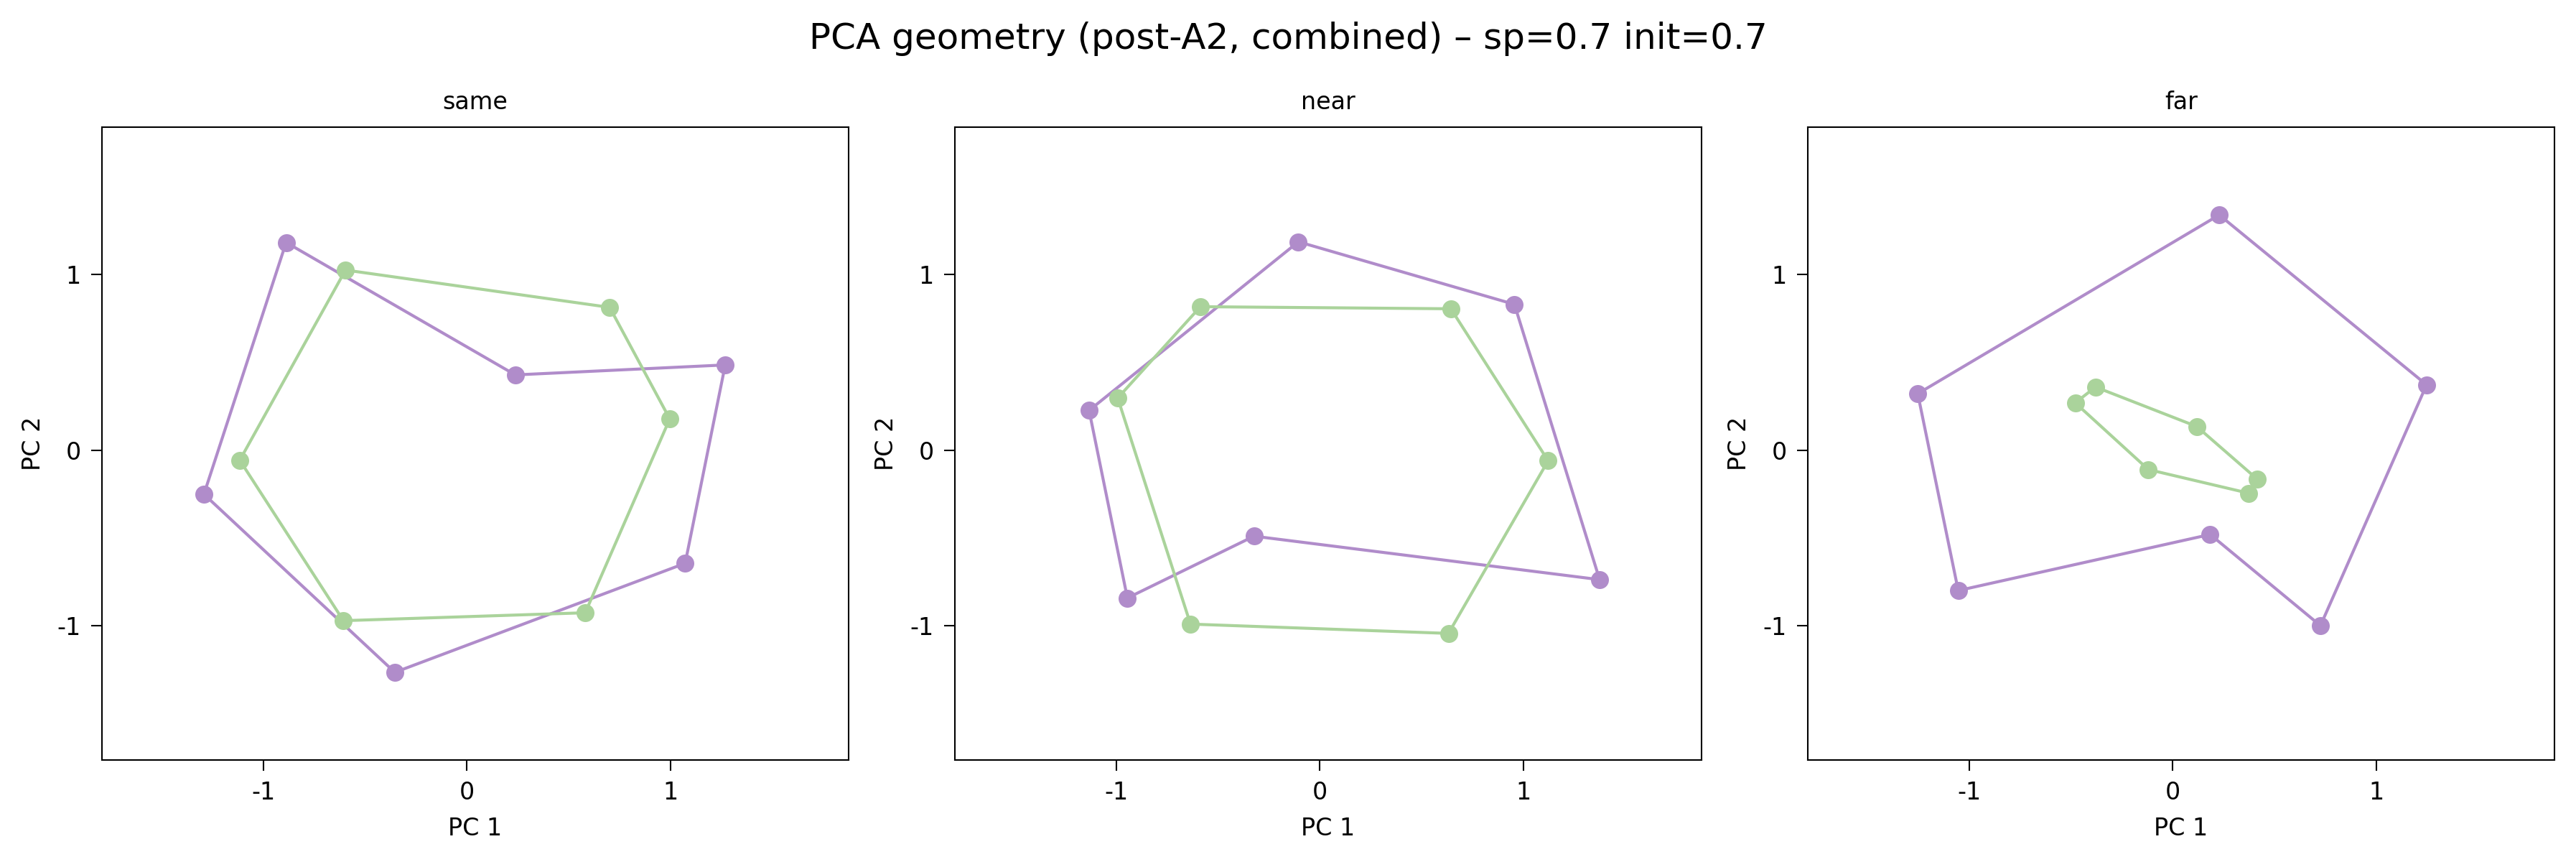

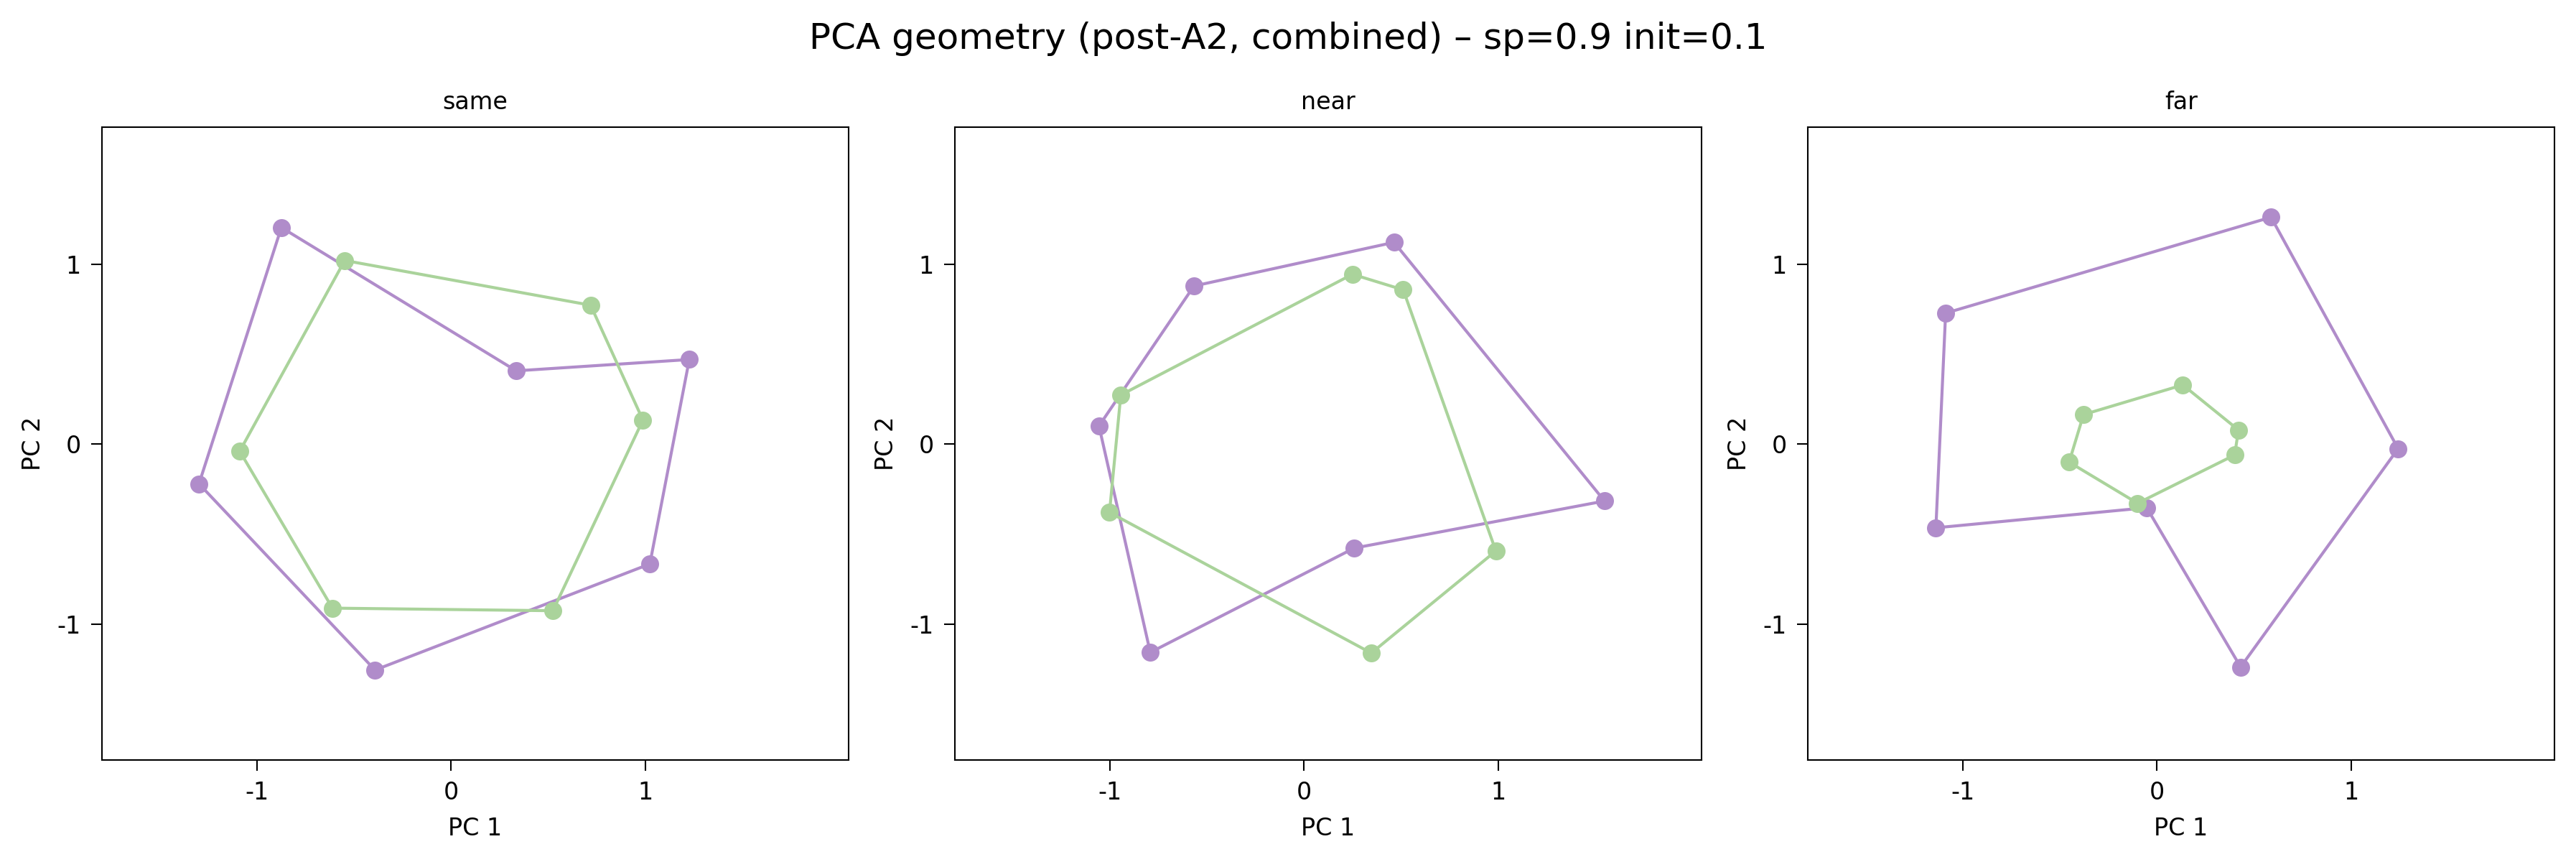

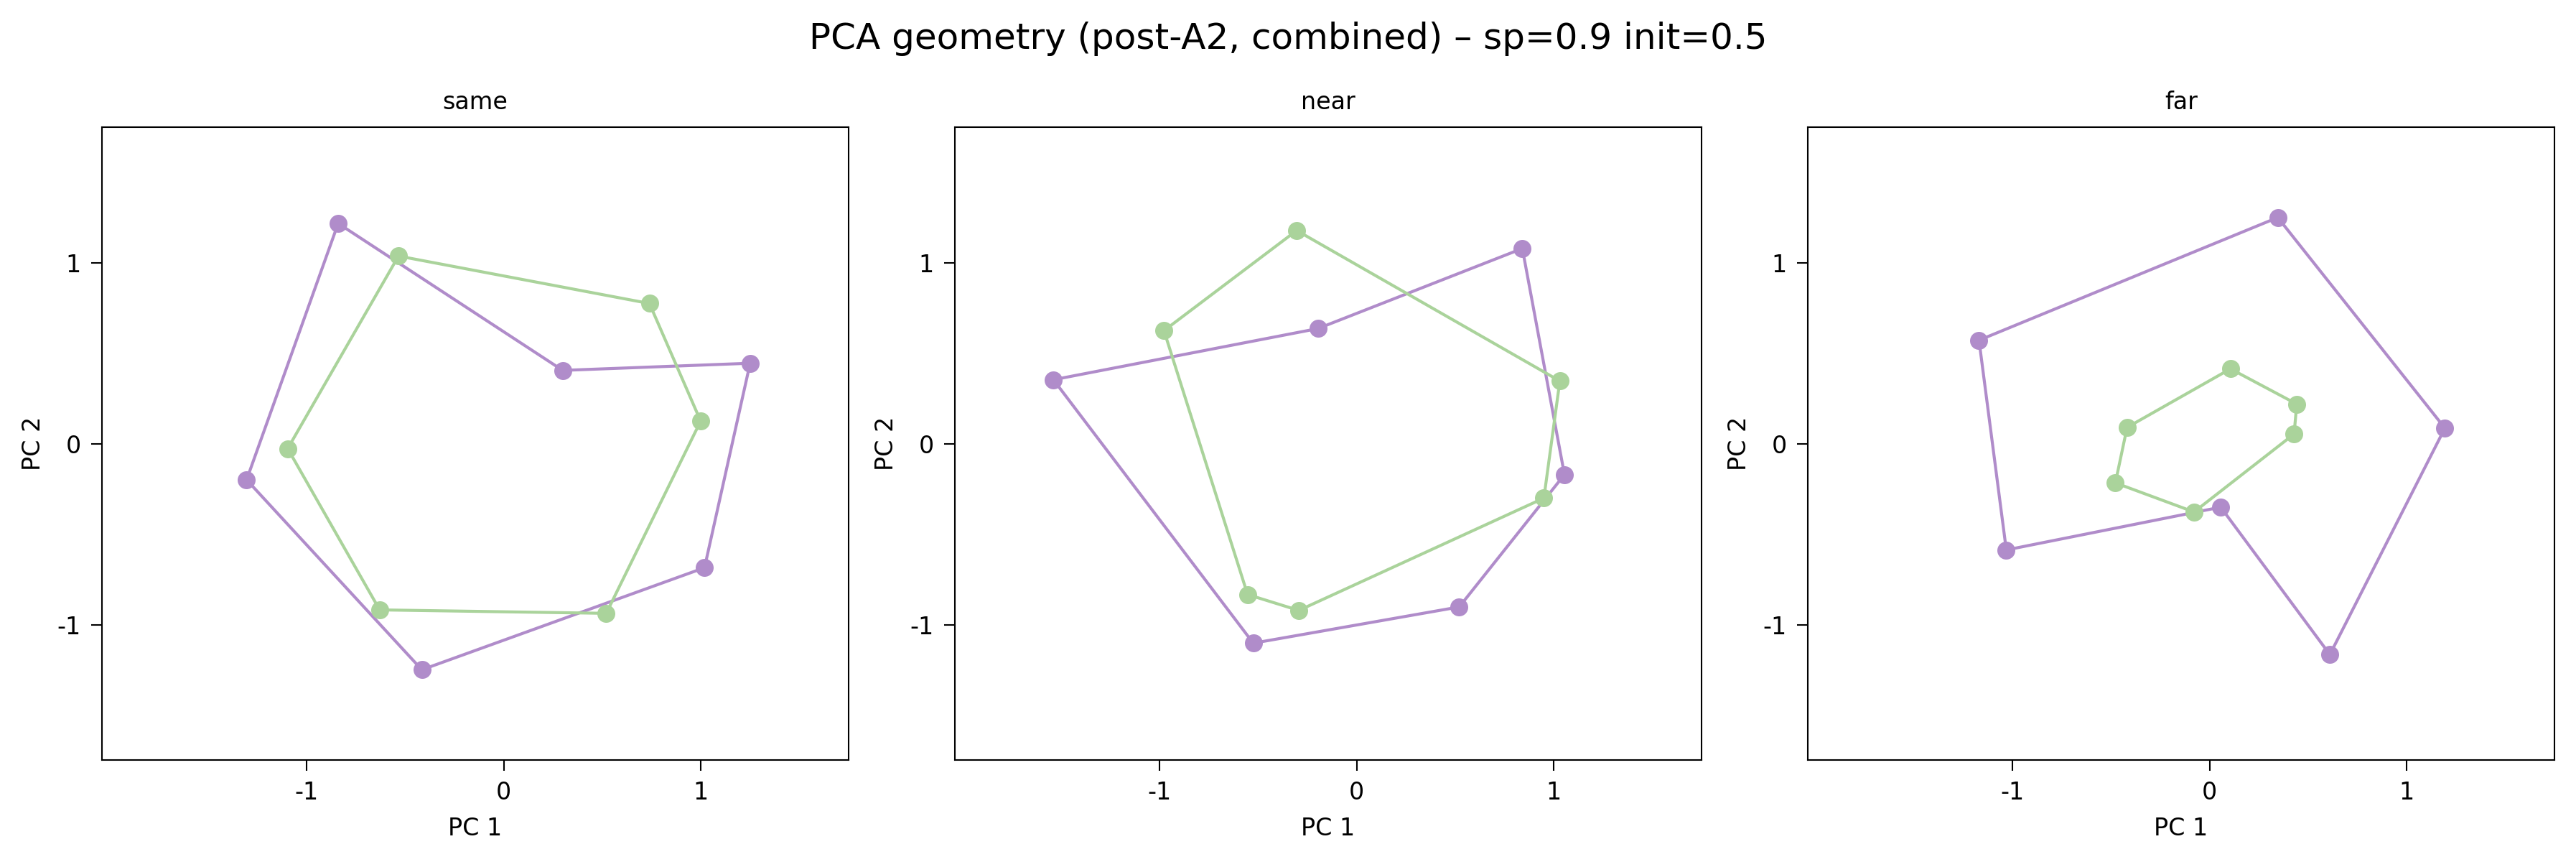

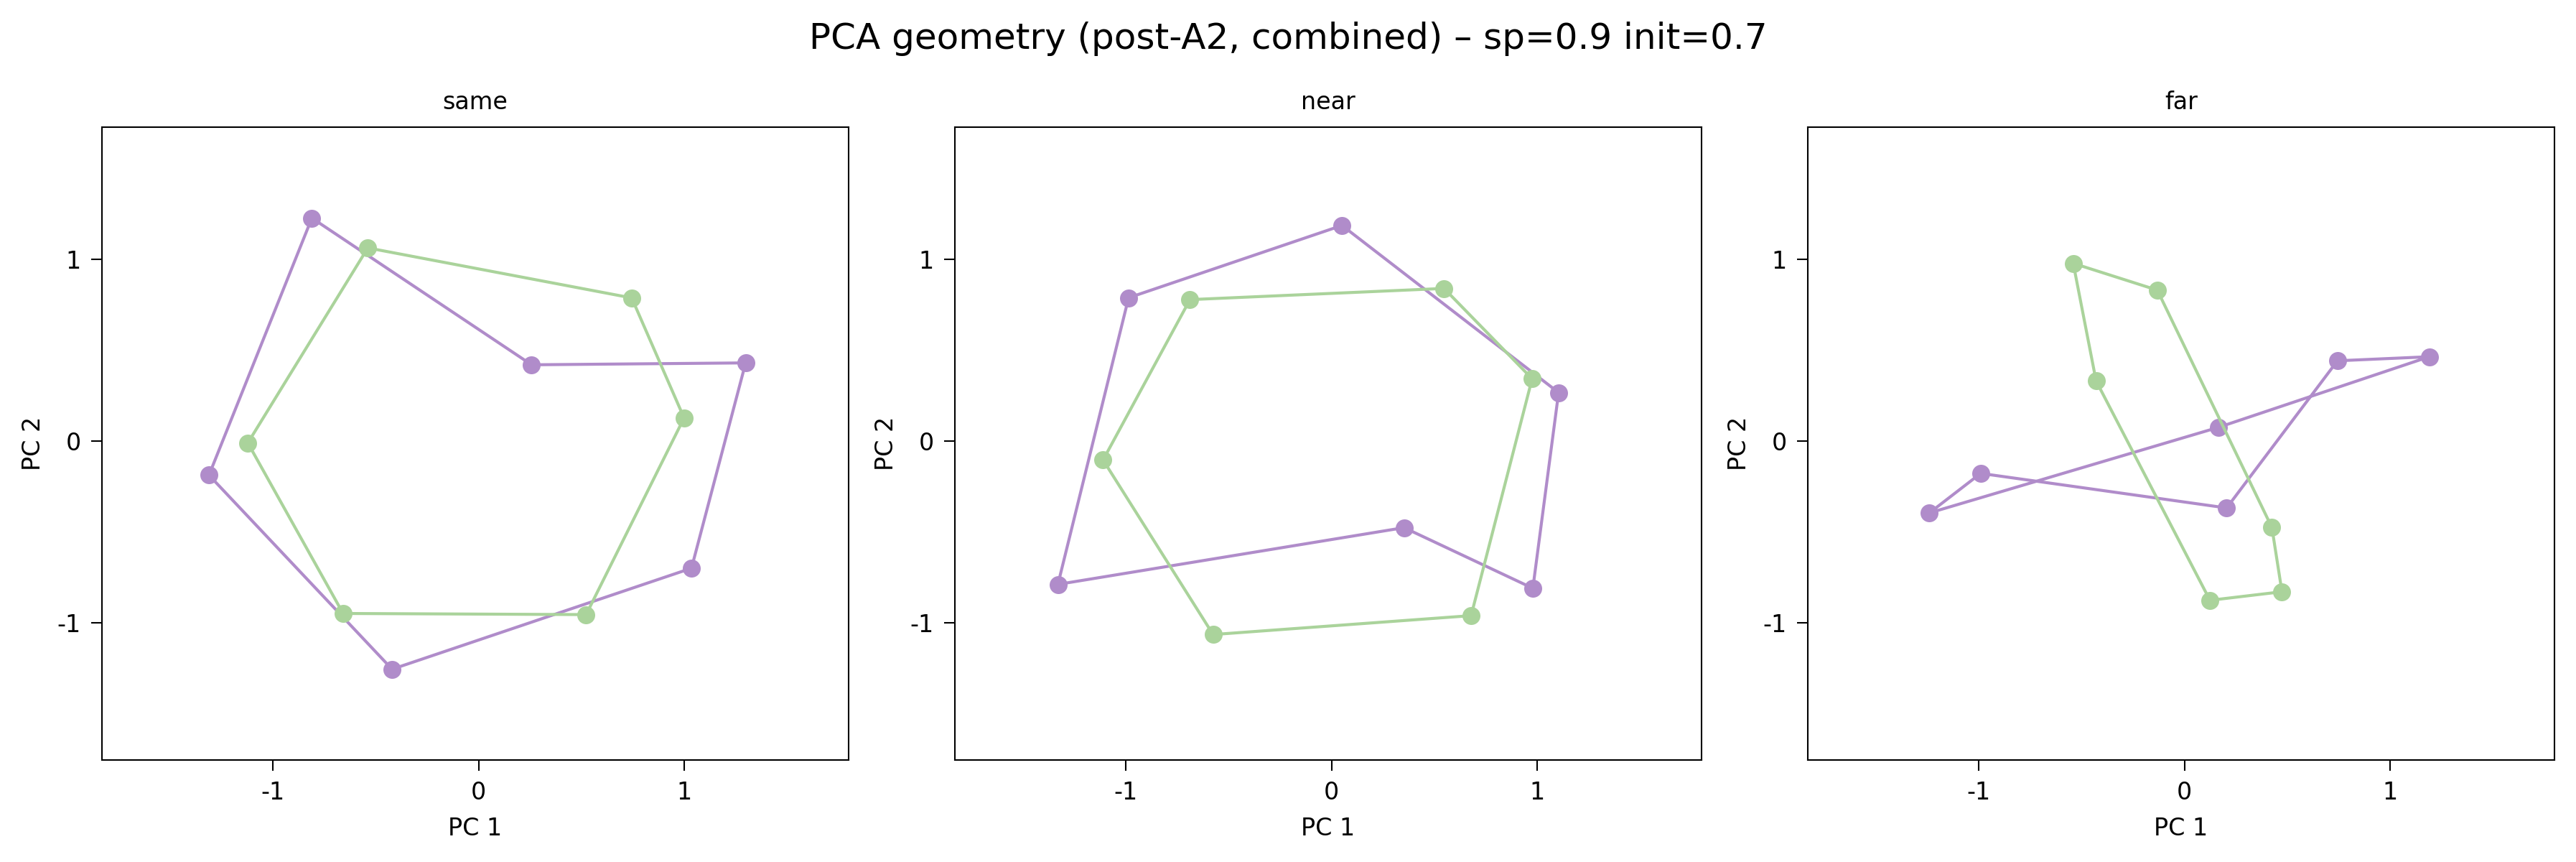

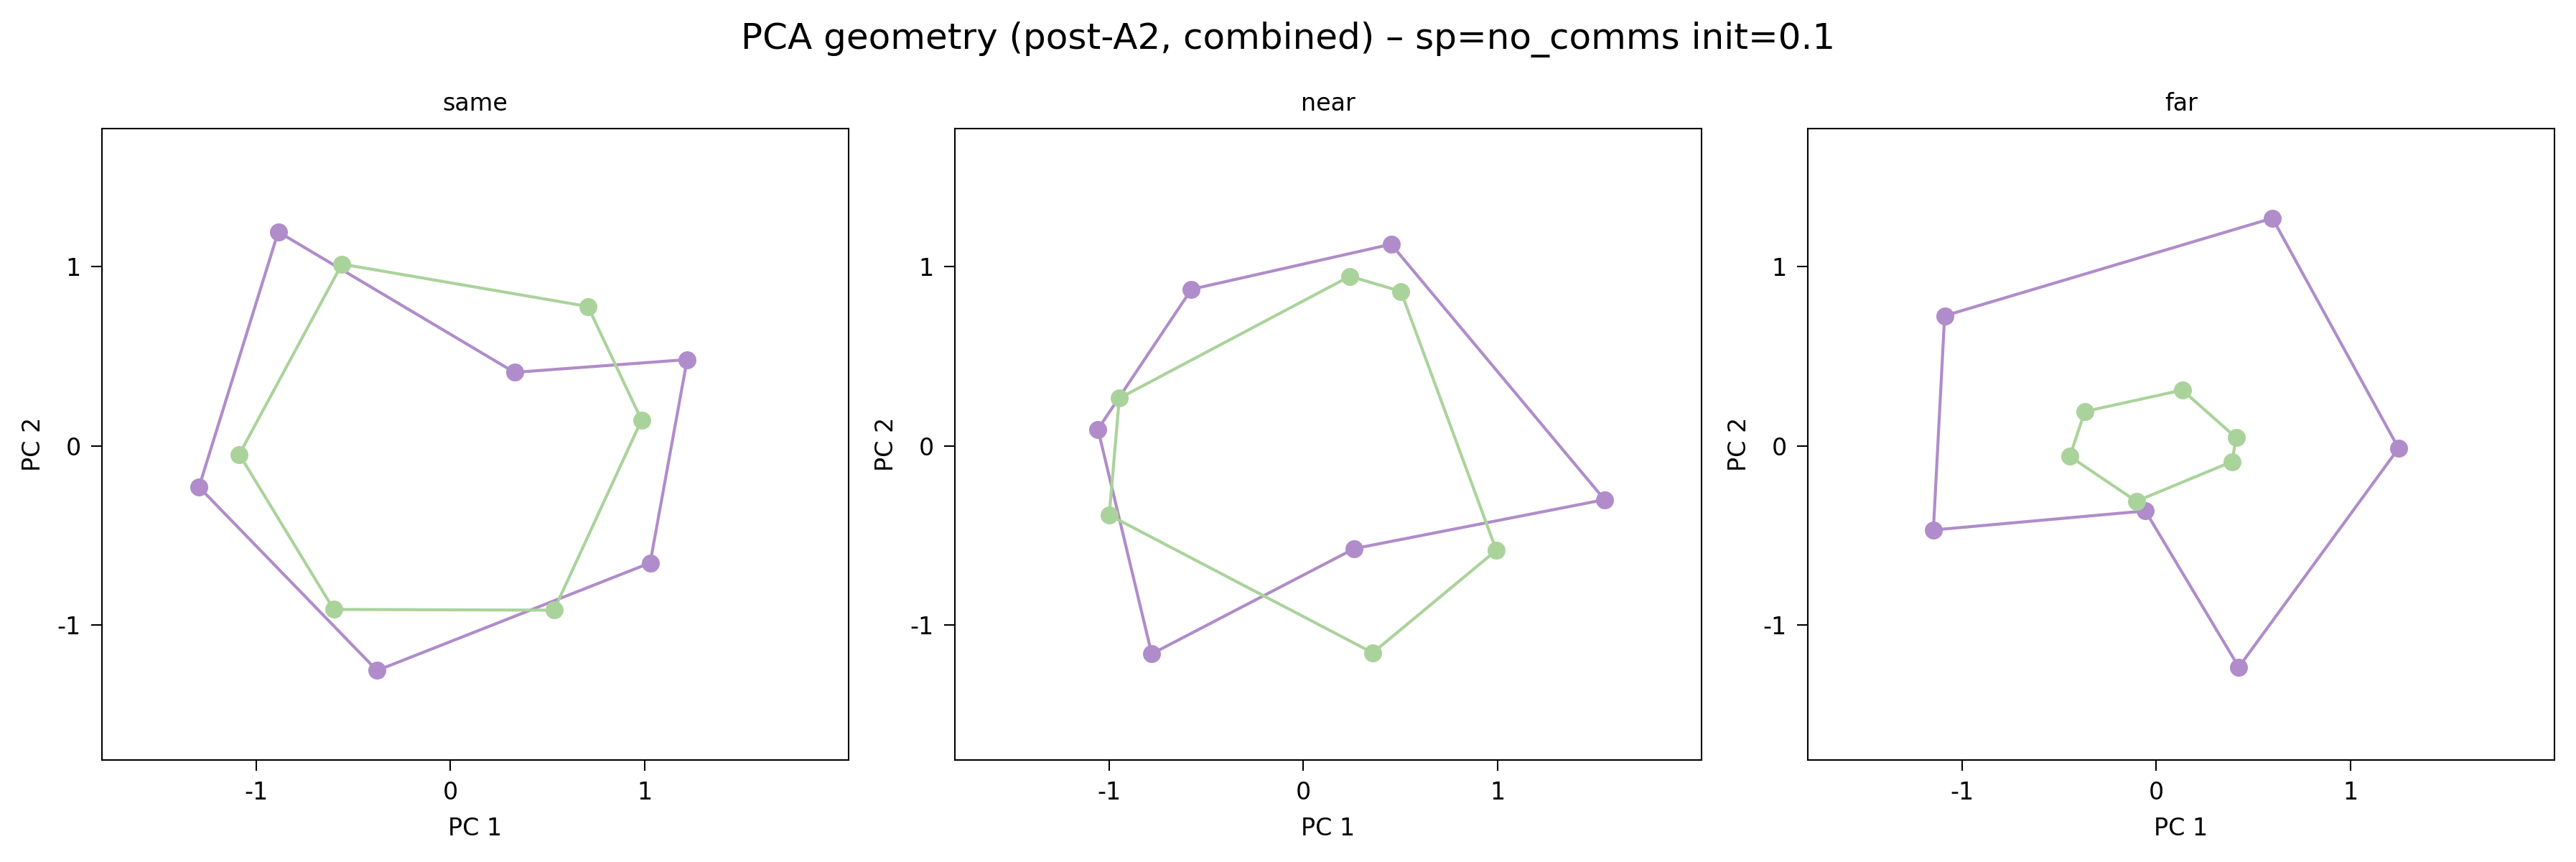

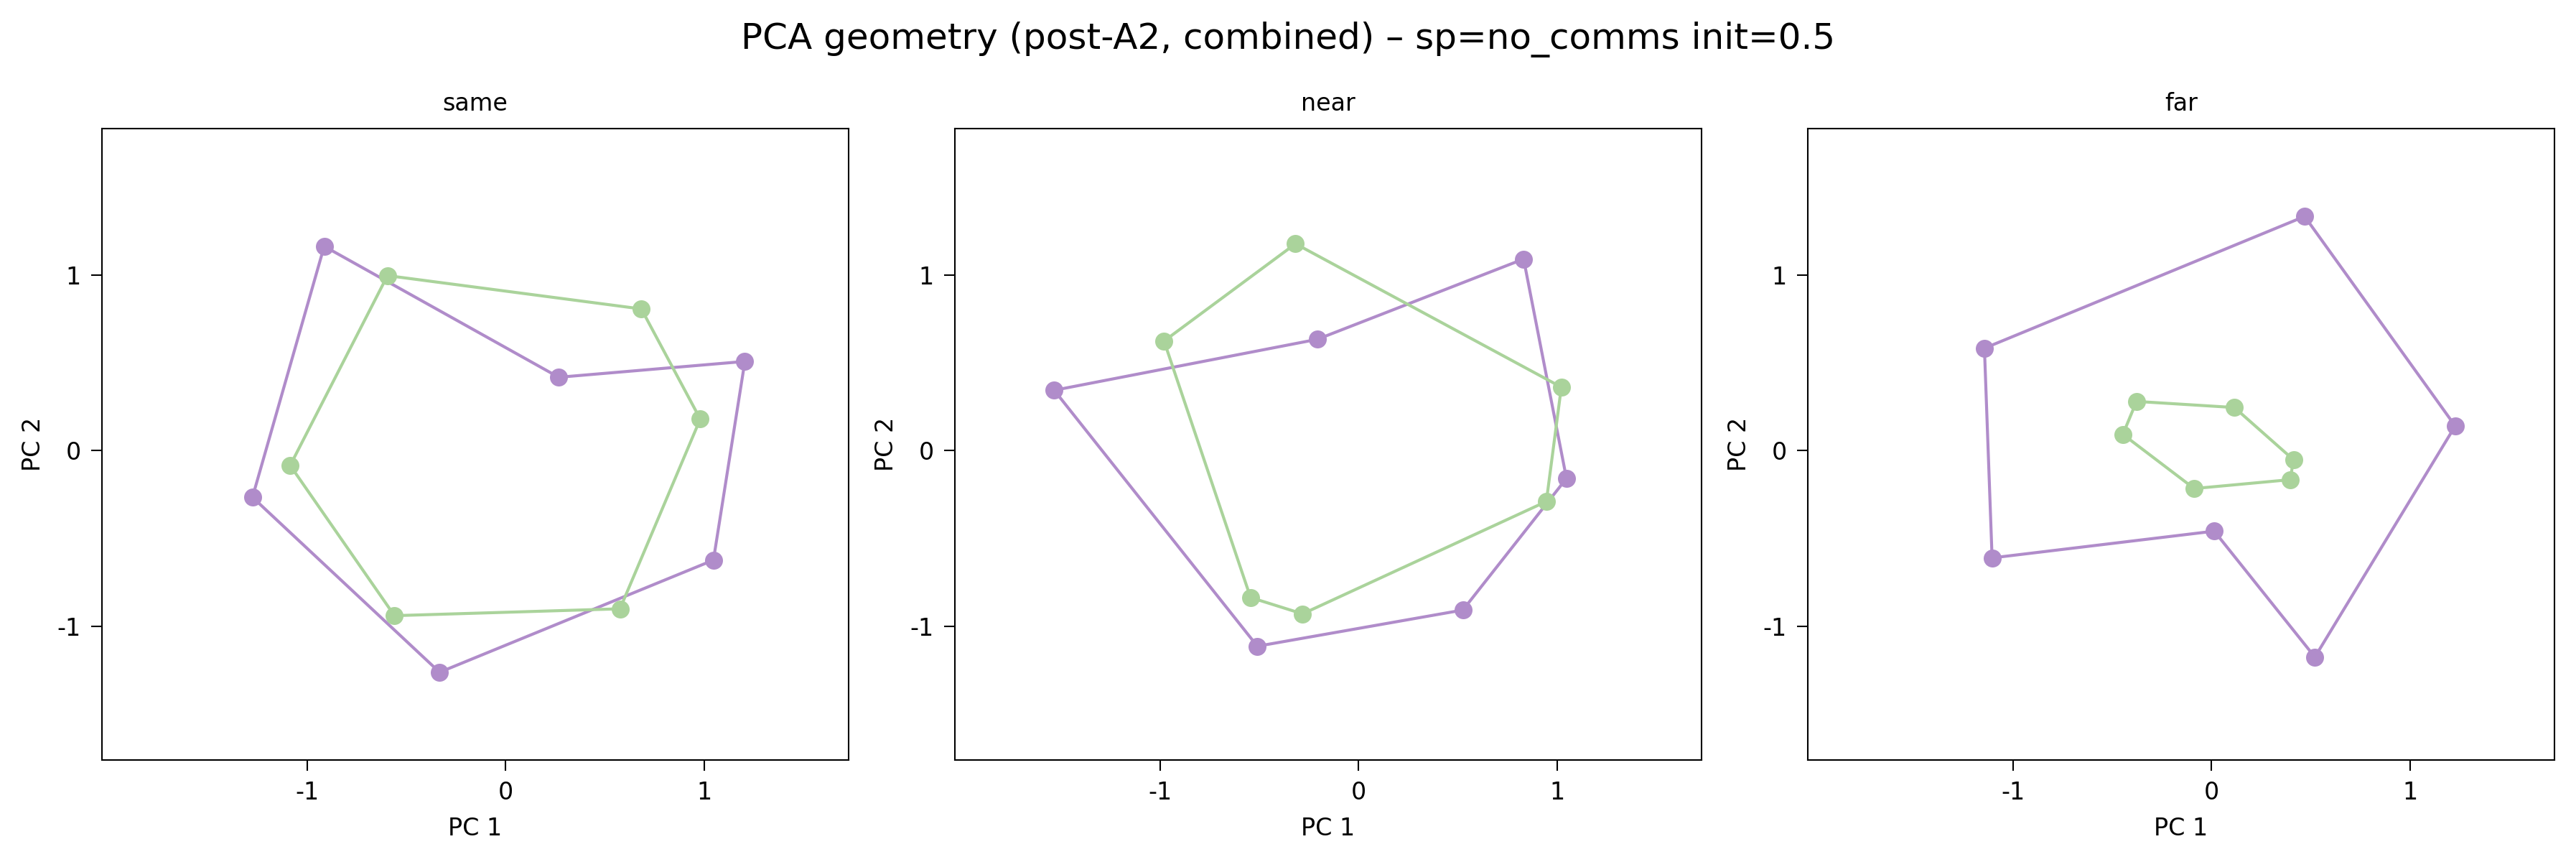

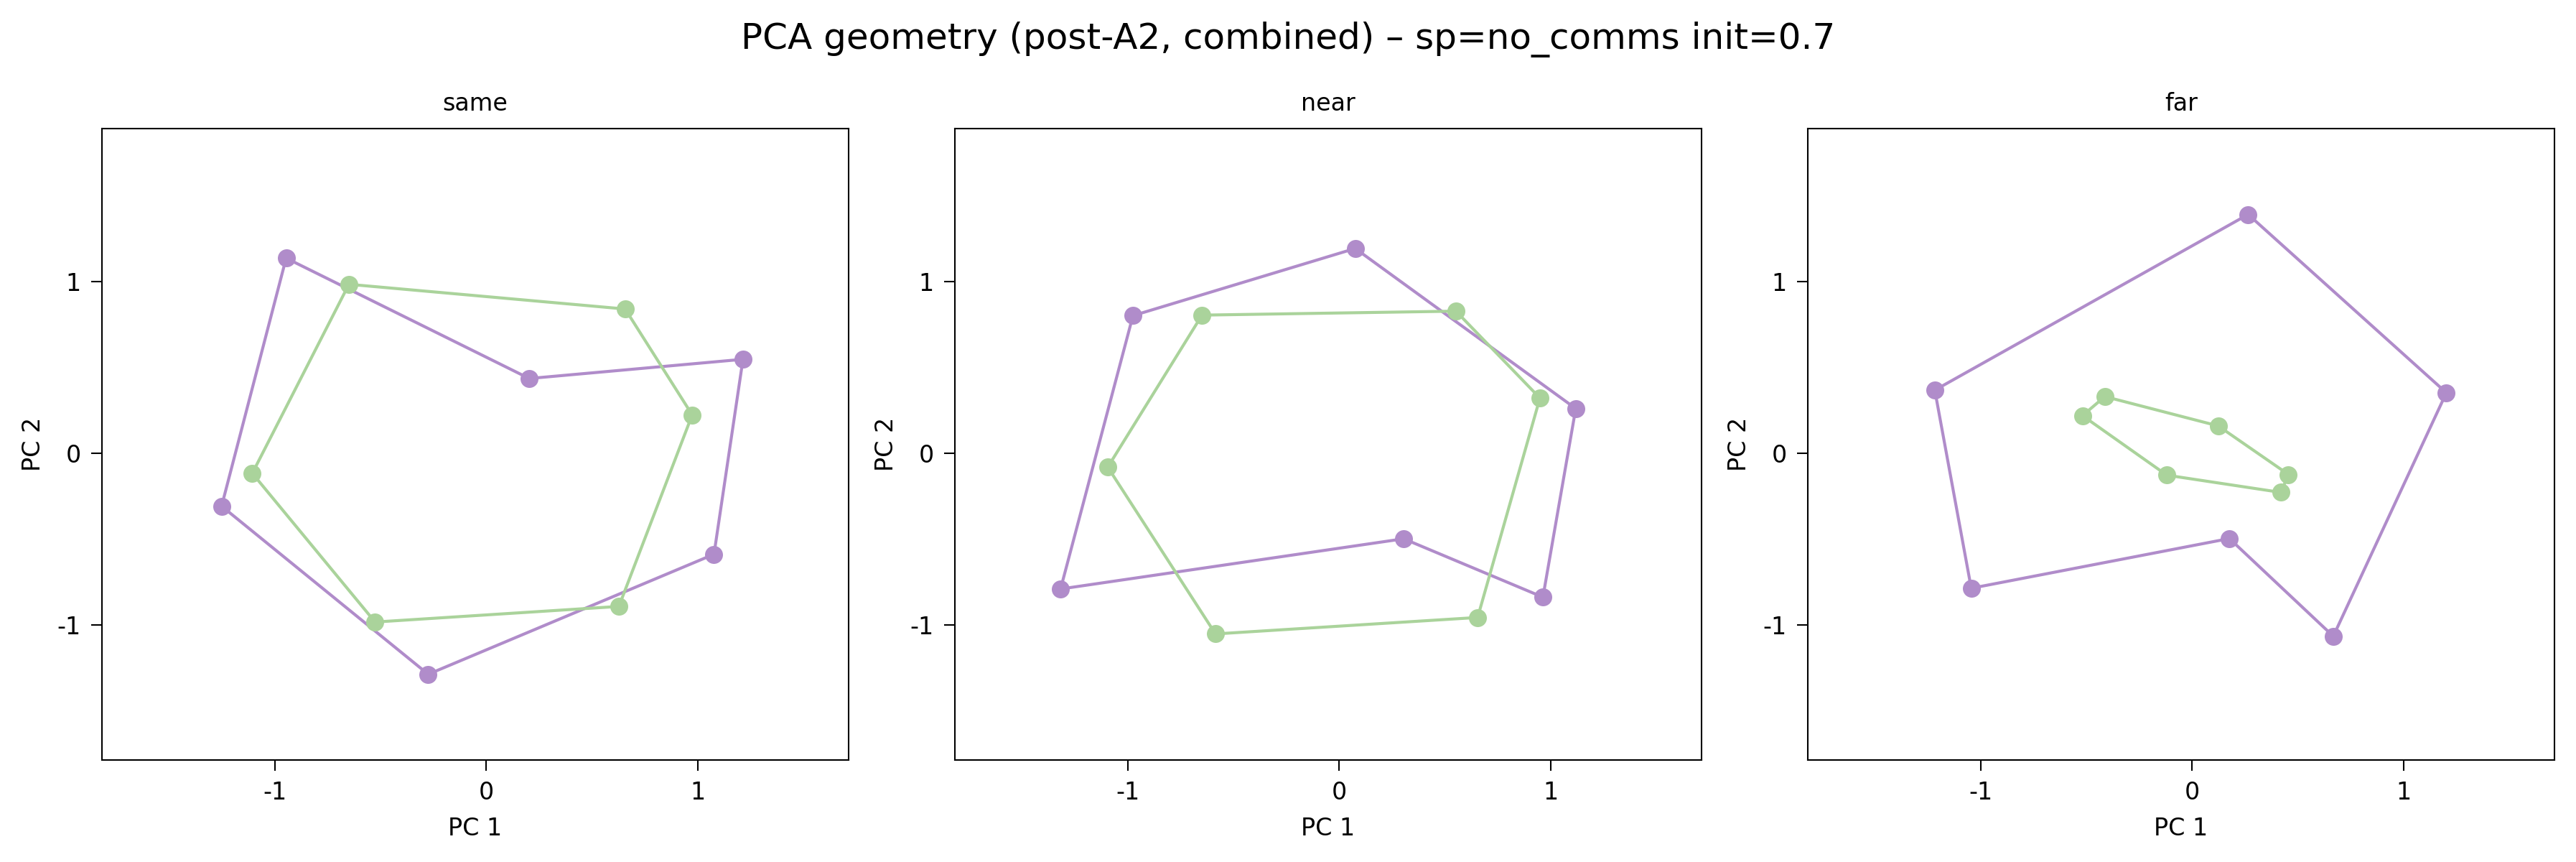

In [ ]:
phase_idx = 2
n_stim_plot = 12

for run_id in run_labels:
    bundle = all_ann_data[run_id]
    ann_data = bundle["data"]
    sp_label = bundle["sparsity_label"]
    init_scale = bundle["init_scale"]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle(f"PCA geometry (post-A2, combined) – sp={sp_label} init={init_scale}", fontsize=12)

    all_2d = []
    for cond in ["same", "near", "far"]:
        entries = ann_data.get(cond, [])
        if not entries:
            all_2d.append(None)
            continue
        entry = entries[0]
        hids = np.asarray(entry.get(f"hiddens_post_phase_{phase_idx}"))
        if hids is None or hids.size == 0 or hids.shape[0] < n_stim_plot:
            all_2d.append(None)
            continue
        hids = hids[:n_stim_plot]
        _, X2 = prepare_pca_single_task(hids)
        all_2d.append(X2)

    valid = [x for x in all_2d if x is not None]
    lims_global = get_axis_limits(np.vstack(valid)) if valid else {}

    for ax, cond, X2 in zip(axes, ["same", "near", "far"], all_2d):
        if X2 is None:
            ax.set_title(f"{cond}\(no data)")
            ax.axis("off")
            continue
        plot_split_stim(ax, X2, task_colours, lims_global)
        ax.set_title(cond)
    plt.tight_layout()
    plt.show()

## 6. Principal angles and transfer vs init_scale

Here we quantify how much task A and task B subspaces separate across initialization scales. We compute principal angles between post-A and post-B representations for each run and similarity condition, and compare them across `init_scale` at fixed sparsity. We also compare transfer and accuracy curves for `init_scale = 1.0, 0.7, 0.5, 0.1` to verify that lower-scale runs are not simply underperforming.

angles_all: (6118, 7)


,participant,condition,principal_angle_between,run_id,init_scale,sparsity,sparsity_label
0,sim_study2_same_sub9,same,33.944107,two_module_rnn_25_task_routed_nb2_nb2_task_rou...,1.0,1.0,1
1,sim_study1_same_sub58,same,45.024300,two_module_rnn_25_task_routed_nb2_nb2_task_rou...,1.0,1.0,1
2,sim_study2_same_sub32,same,36.837299,two_module_rnn_25_task_routed_nb2_nb2_task_rou...,1.0,1.0,1
3,sim_study1_same_sub9,same,36.141693,two_module_rnn_25_task_routed_nb2_nb2_task_rou...,1.0,1.0,1
4,sim_study1_same_sub40,same,44.985634,two_module_rnn_25_task_routed_nb2_nb2_task_rou...,1.0,1.0,1


,index,init_scale,sparsity_label,condition,angle_mean,angle_sem
0,0,0.1,0.3,far,86.231911,0.150654
1,1,0.1,0.3,near,12.284253,0.119410
2,2,0.1,0.3,same,0.529603,0.006520
3,3,0.1,0.5,far,86.232414,0.150488
4,4,0.1,0.5,near,12.283207,0.119268


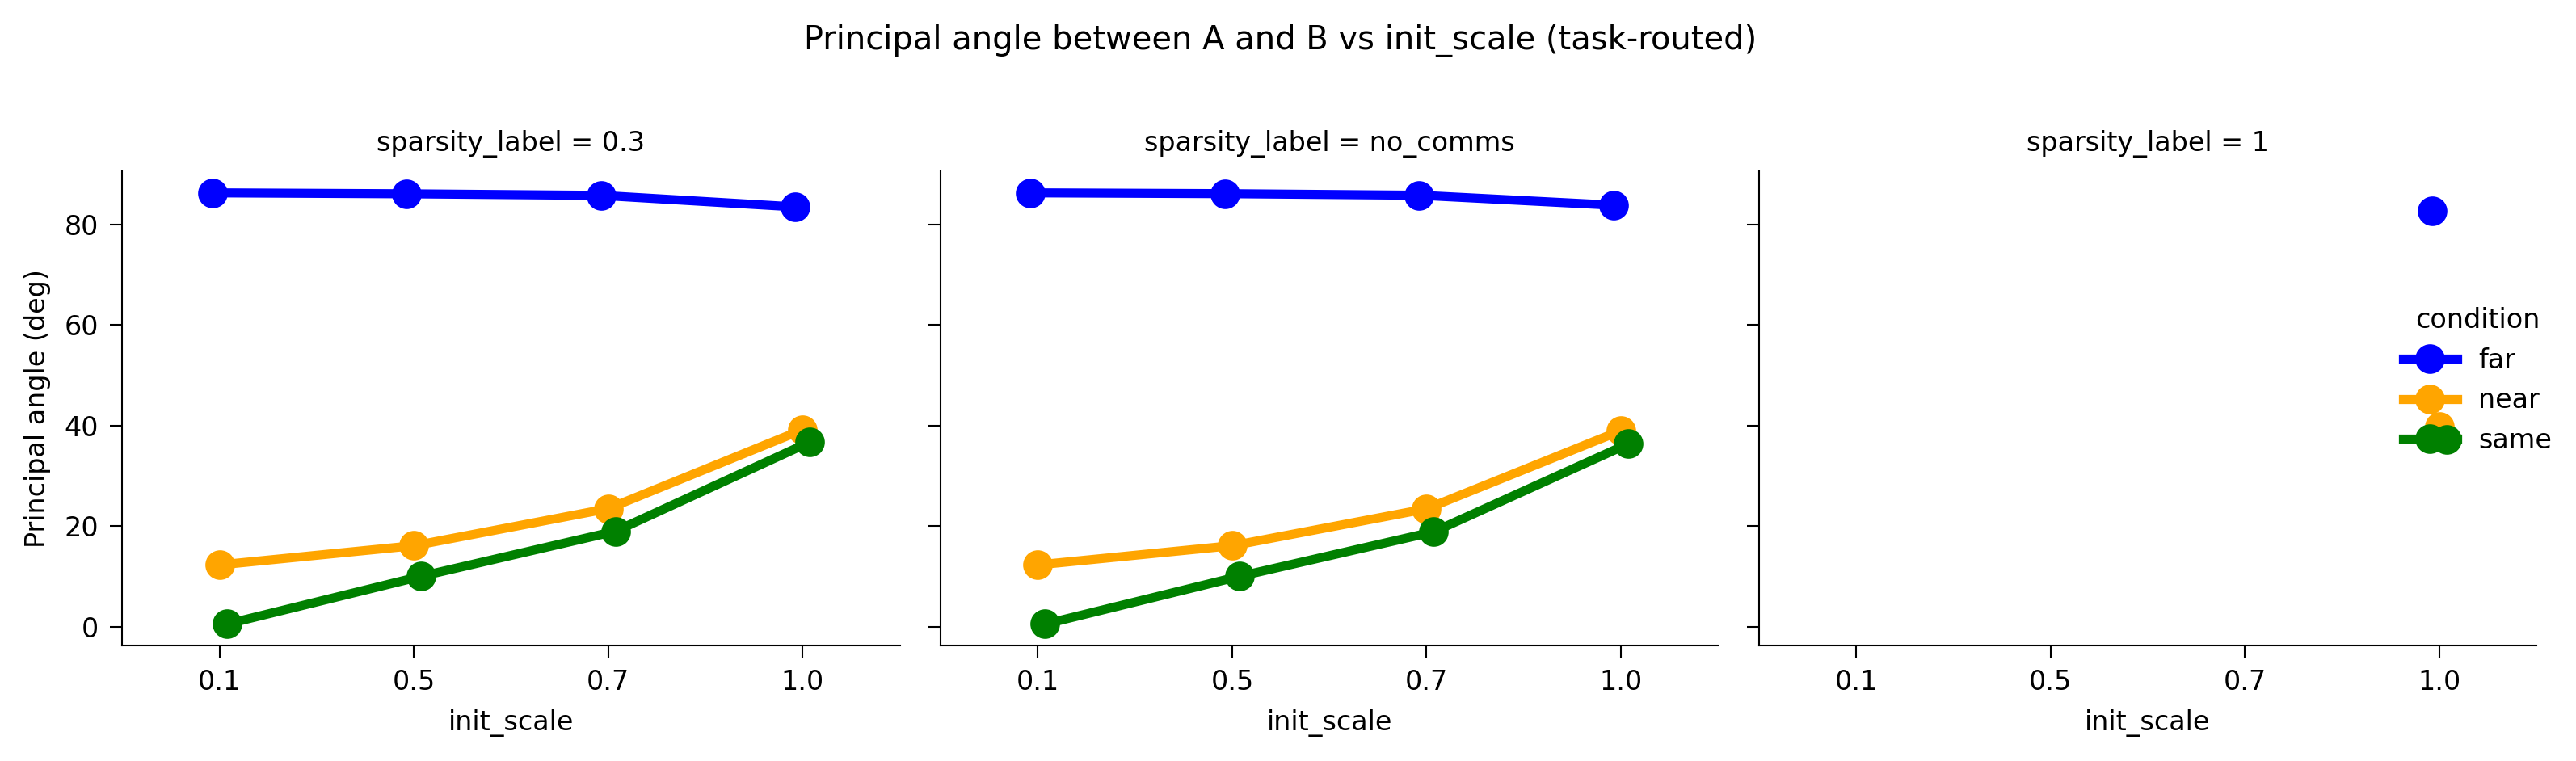

,init_scale,sparsity_label,condition,error_diff
0,0.1,0.3,far,-0.364893
1,0.1,0.3,near,-0.372446
2,0.1,0.3,same,-0.368319
3,0.1,0.5,far,-0.364893
4,0.1,0.5,near,-0.372446


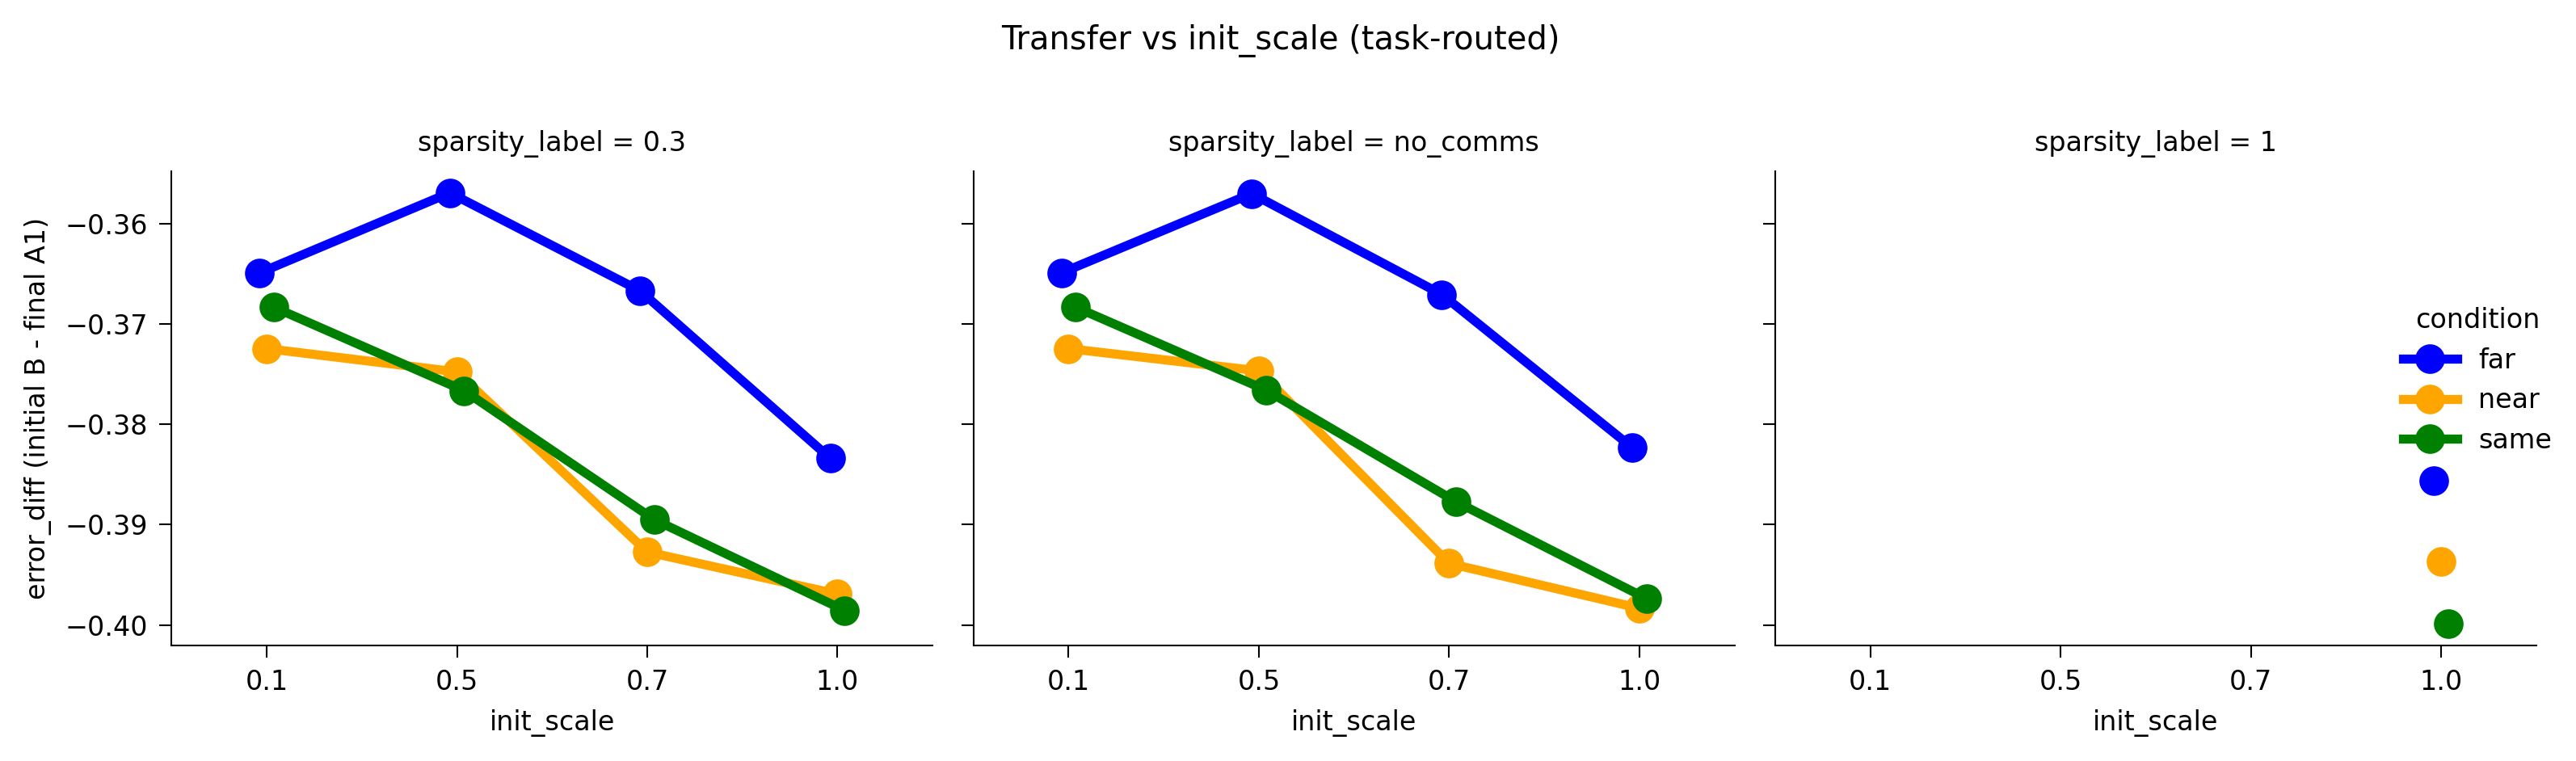

,init_scale,sparsity_label,condition,phase,mean_accuracy
0,0.1,0.3,far,post_A2,0.928496
1,0.1,0.3,far,post_B,0.996621
2,0.1,0.3,near,post_A2,0.929797
3,0.1,0.3,near,post_B,0.996622
4,0.1,0.3,same,post_A2,0.932010


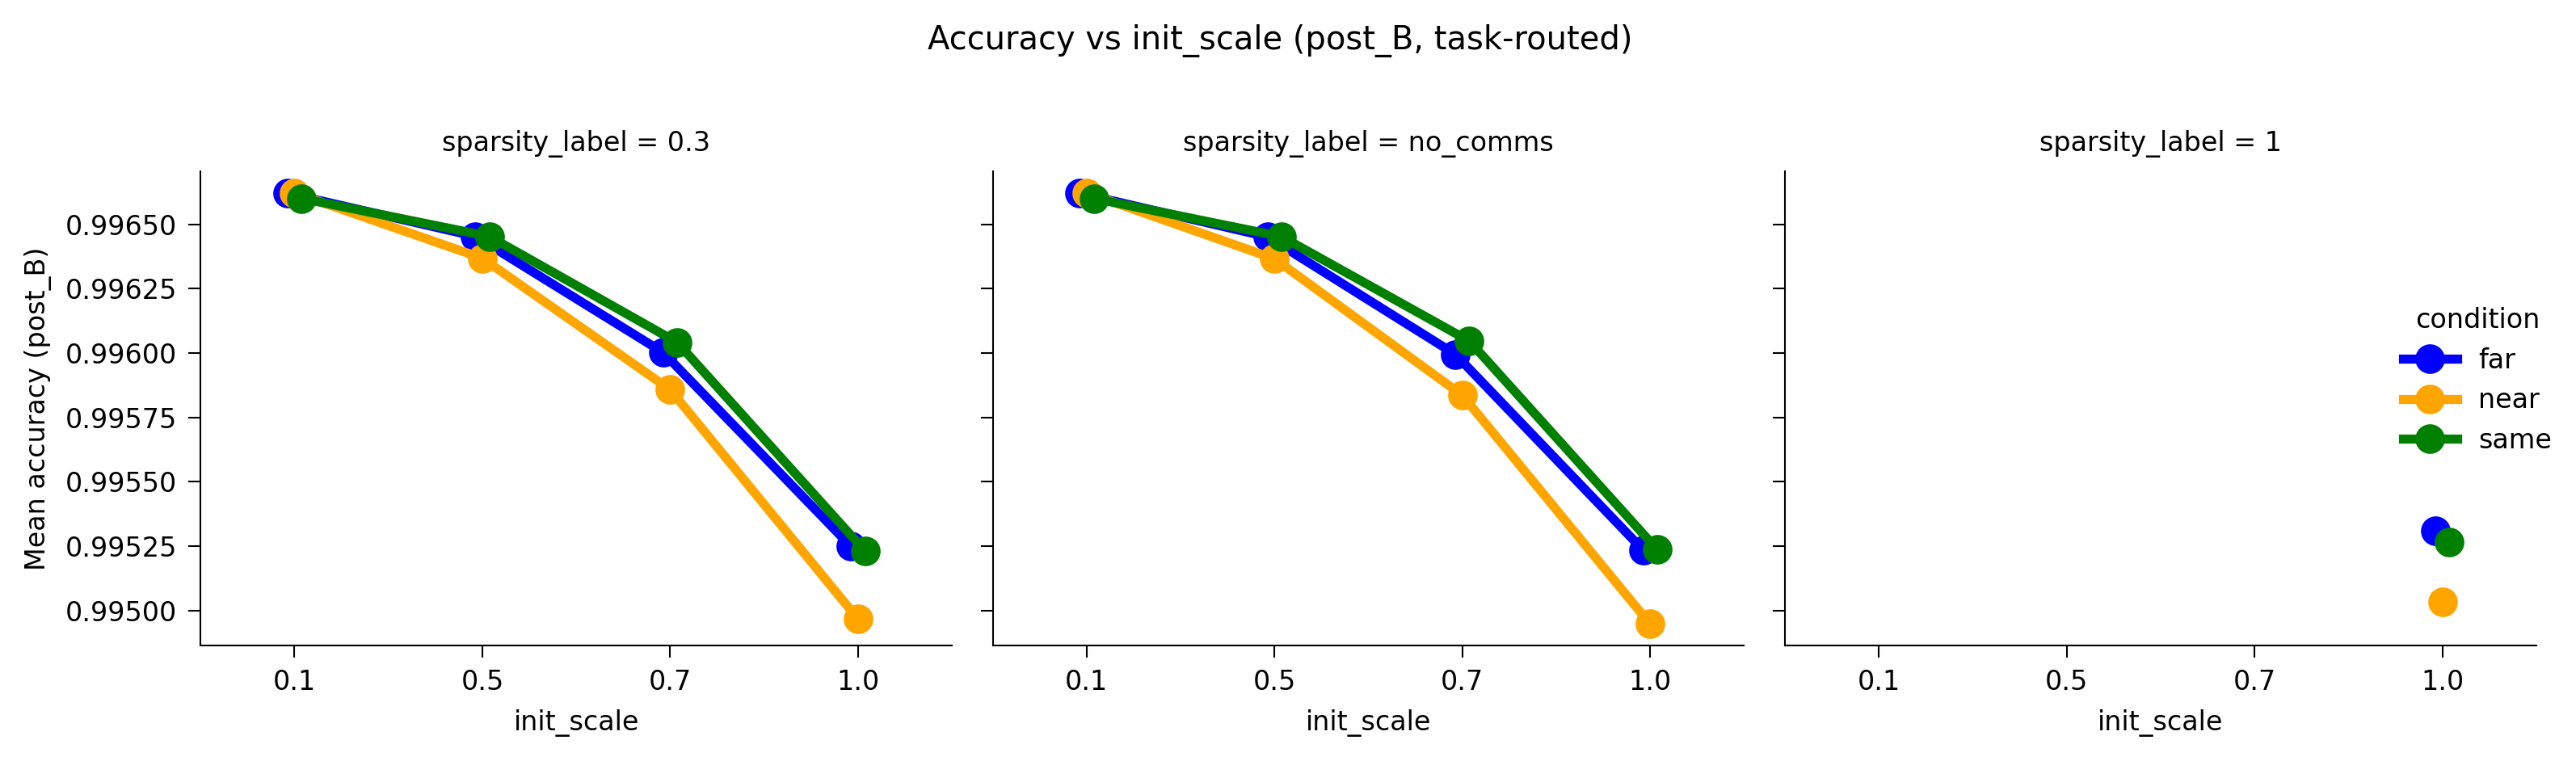

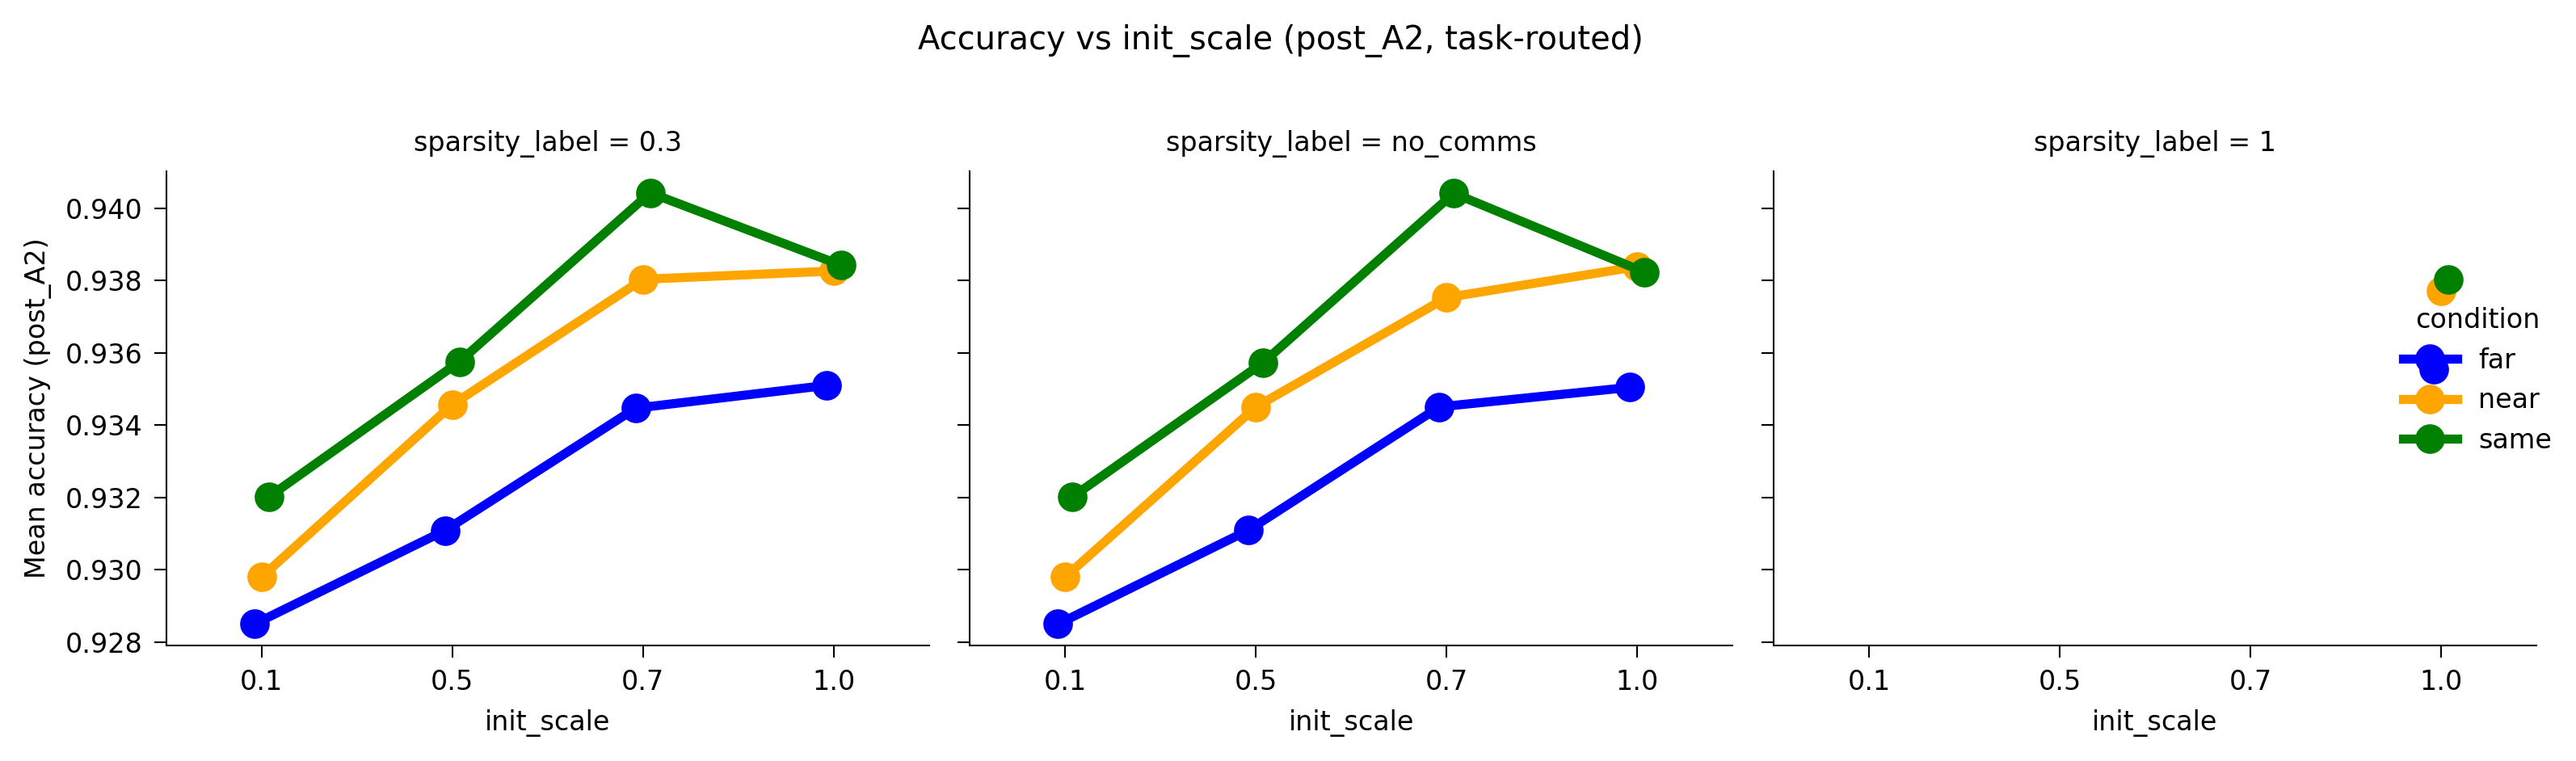

In [ ]:
# 6.1 Principal angles between A and B subspaces across init_scale

angles_records = []

for run_id, bundle in all_ann_data.items():
    ann_data_run = bundle["data"]
    init_scale = bundle["init_scale"]
    sparsity = bundle["sparsity"]
    sp_label = bundle["sparsity_label"]

    # ann.get_principal_angles returns per-participant, per-condition angles
    angles_df = ann.get_principal_angles(ann_data_run)
    angles_df = angles_df.copy()
    angles_df["run_id"] = run_id
    angles_df["init_scale"] = init_scale
    angles_df["sparsity"] = sparsity
    angles_df["sparsity_label"] = sp_label
    angles_records.append(angles_df)

if angles_records:
    angles_all = pd.concat(angles_records, ignore_index=True)
else:
    angles_all = pd.DataFrame(columns=["participant", "condition", "principal_angle_between", "run_id", "init_scale", "sparsity", "sparsity_label"])

print("angles_all:", angles_all.shape)
display(angles_all.head())

# Aggregate angles by init_scale, sparsity, and condition
if not angles_all.empty:
    angles_agg = (
        angles_all
        .groupby(["init_scale", "sparsity_label", "condition"], as_index=False)["principal_angle_between"]
        .agg(["mean", "sem"])
        .reset_index()
    )
    angles_agg.rename(columns={"mean": "angle_mean", "sem": "angle_sem"}, inplace=True)
    display(angles_agg.head())

    # Focus on a few key sparsities: full (1), low_sparse (0.3), and no_comms for comparison
    key_sp = ["1", "0.3", "no_comms"]
    sub = angles_agg[angles_agg["sparsity_label"].isin(key_sp)].copy()
    if not sub.empty:
        g = sns.catplot(
            data=sub,
            x="init_scale",
            y="angle_mean",
            hue="condition",
            palette=SIMILARITY_PALETTE,
            col="sparsity_label",
            kind="point",
            dodge=True,
            height=3,
            aspect=1.1,
        )
        g.set_axis_labels("init_scale", "Principal angle (deg)")
        g.fig.suptitle("Principal angle between A and B vs init_scale (task-routed)", y=1.02)
        plt.tight_layout()
        plt.show()
else:
    print("No principal angle data.")

# 6.2 Transfer vs init_scale (Holton-style summary)

if not transfer_df.empty:
    transfer_init = (
        transfer_df
        .groupby(["init_scale", "sparsity_label", "condition"], as_index=False)["error_diff"]
        .mean()
    )
    display(transfer_init.head())

    key_sp = ["1", "0.3", "no_comms"]
    sub_tr = transfer_init[transfer_init["sparsity_label"].isin(key_sp)].copy()
    if not sub_tr.empty:
        g = sns.catplot(
            data=sub_tr,
            x="init_scale",
            y="error_diff",
            hue="condition",
            palette=SIMILARITY_PALETTE,
            col="sparsity_label",
            kind="point",
            dodge=True,
            height=3,
            aspect=1.1,
        )
        g.set_axis_labels("init_scale", "error_diff (initial B - final A1)")
        g.fig.suptitle("Transfer vs init_scale (task-routed)", y=1.02)
        plt.tight_layout()
        plt.show()
else:
    print("No transfer data.")

# 6.3 Accuracy vs init_scale (post_B and post_A2)

if not accuracy_df.empty:
    acc_phase = accuracy_df[accuracy_df["phase"].isin(["post_B", "post_A2"])].copy()
    acc_init = (
        acc_phase
        .groupby(["init_scale", "sparsity_label", "condition", "phase"], as_index=False)["mean_accuracy"]
        .mean()
    )
    display(acc_init.head())

    key_sp = ["1", "0.3", "no_comms"]
    for phase in ["post_B", "post_A2"]:
        sub_acc = acc_init[(acc_init["sparsity_label"].isin(key_sp)) & (acc_init["phase"] == phase)].copy()
        if sub_acc.empty:
            continue
        g = sns.catplot(
            data=sub_acc,
            x="init_scale",
            y="mean_accuracy",
            hue="condition",
            palette=SIMILARITY_PALETTE,
            col="sparsity_label",
            kind="point",
            dodge=True,
            height=3,
            aspect=1.1,
        )
        g.set_axis_labels("init_scale", f"Mean accuracy ({phase})")
        g.fig.suptitle(f"Accuracy vs init_scale ({phase}, task-routed)", y=1.02)
        plt.tight_layout()
        plt.show()
else:
    print("No accuracy data.")

## 7. Holton-style training trajectories (accuracy and loss)

Here we plot the full training trajectories (A1 → B → A2) of accuracy and loss, in the same spirit as the Holton paper, and compare **init_scale = 1.0, 0.7, 0.5, 0.1** at fixed sparsity and task-routed input. We aggregate over participants for each run and similarity condition (same / near / far).

## 9. Direct comparison: number of PCs across phases

Bar plots of the number of principal components needed to explain 95% and 99% of variance (`n_pcs_95`, `n_pcs_99`) for the **combined** pathway, faceted by `init_scale` and separated by training phase (post_A, post_B, post_A2).


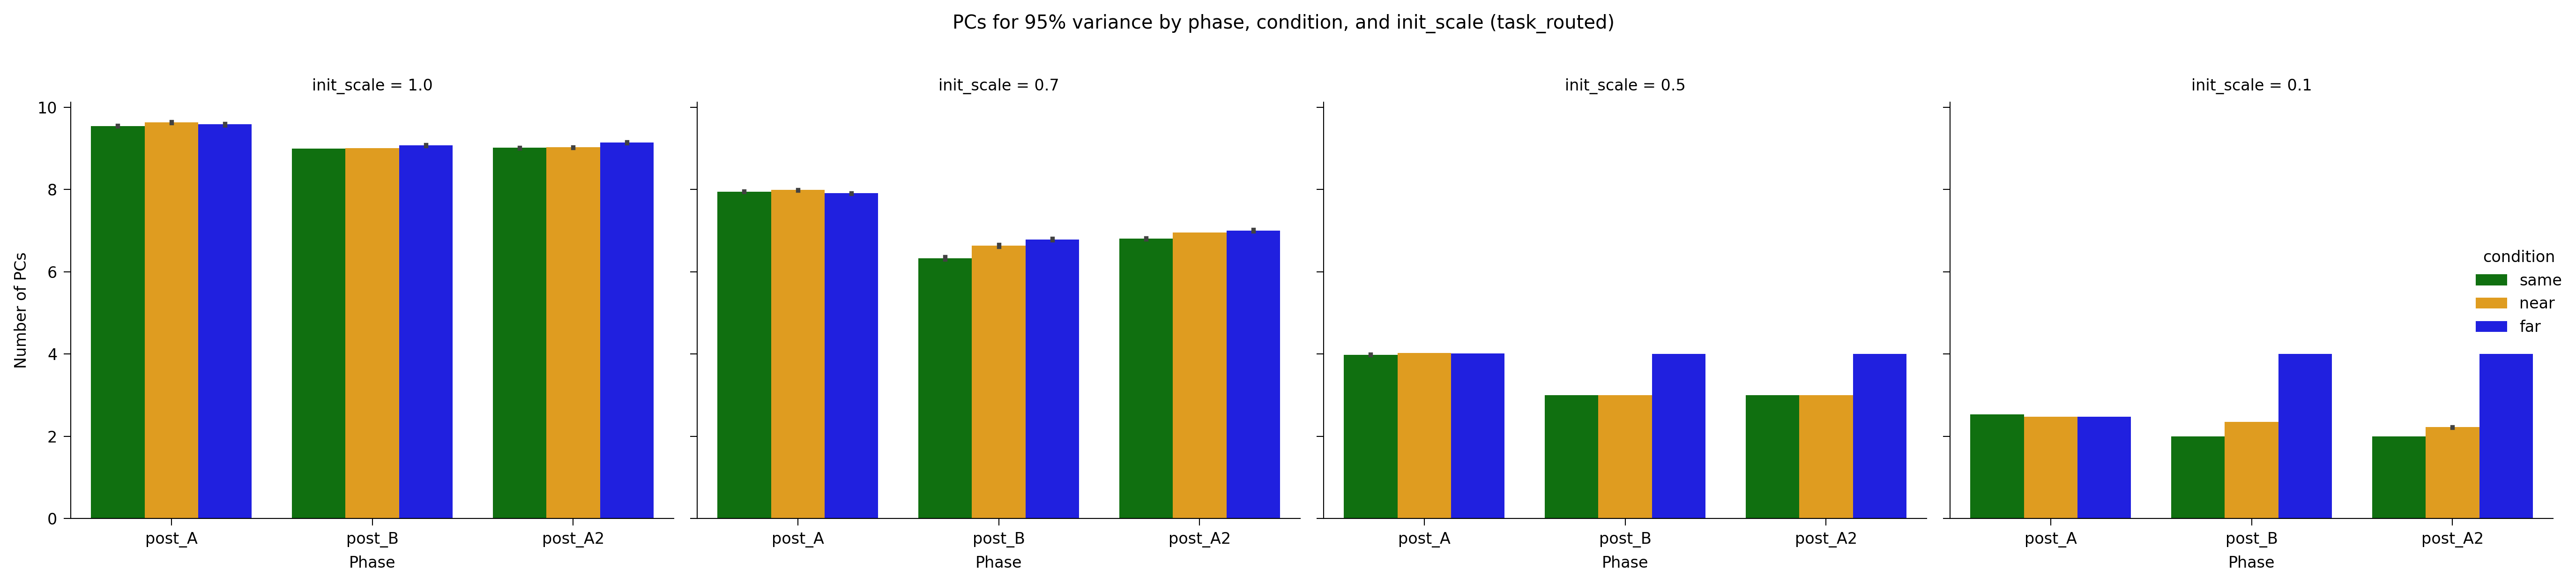

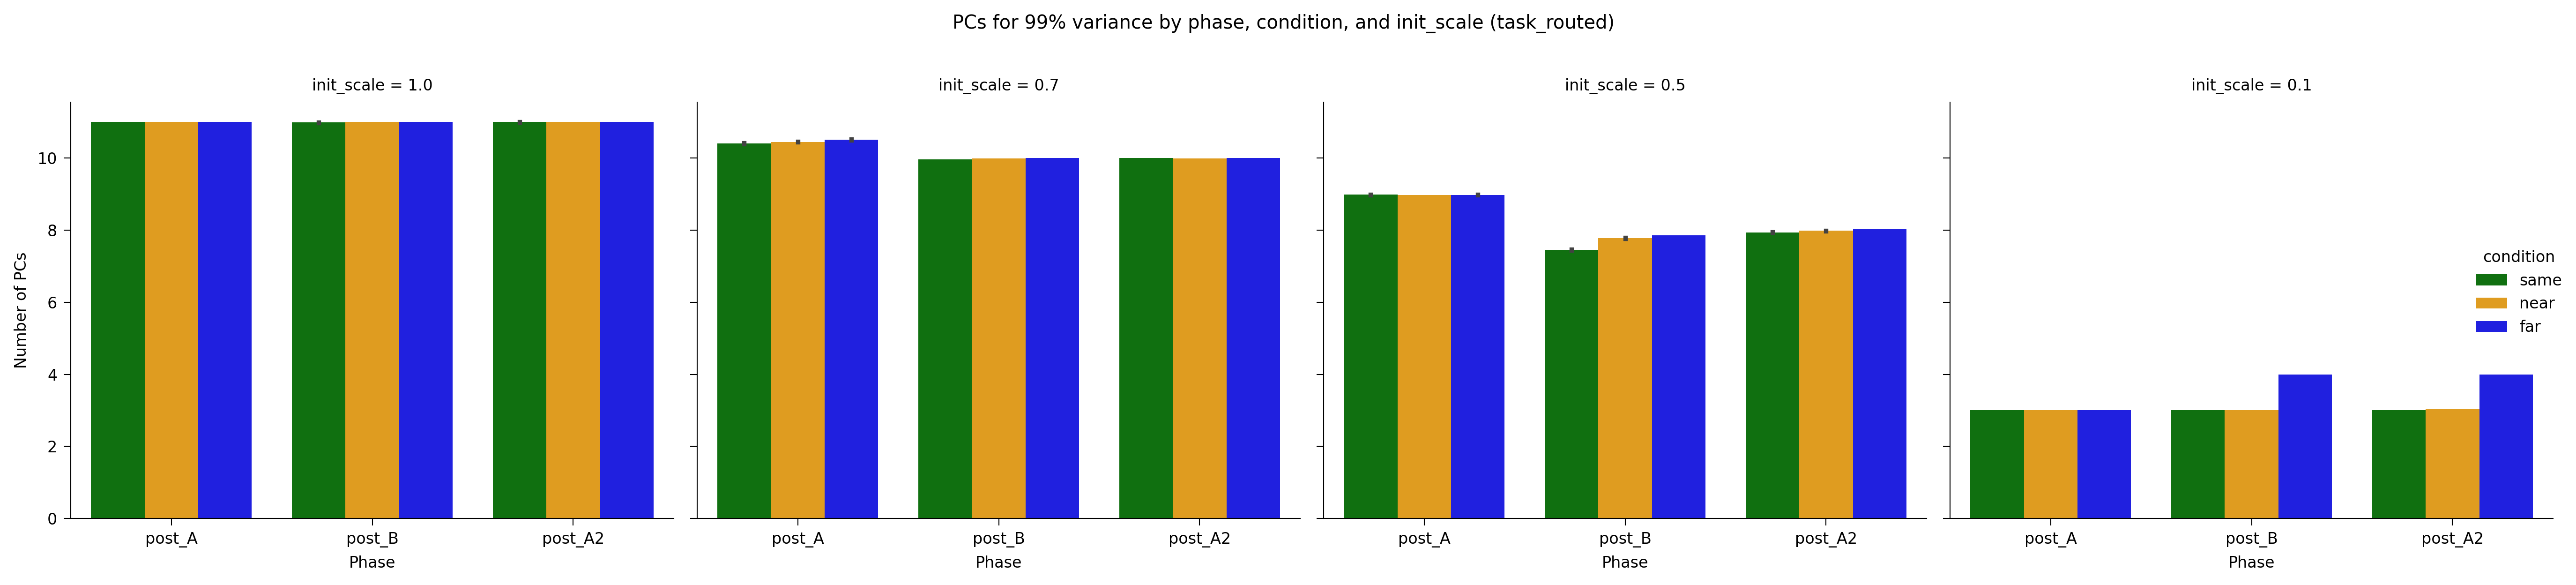

In [ ]:
# Matches the subplot construction used in nb_init_scale_geometry_transfer.ipynb (#6a)

phase_order = ["post_A", "post_B", "post_A2"]

if 'rep_summary' in globals() and not rep_summary.empty:
    comp = rep_summary[rep_summary["pathway"] == "combined"].copy()
    comp["phase"] = pd.Categorical(comp["phase"], categories=phase_order, ordered=True)
    comp["init_scale"] = comp["init_scale"].astype(float)
    col_order = sorted(comp["init_scale"].dropna().unique(), reverse=True)

    for y_col, title in [("n_pcs_95", "PCs for 95% variance"), ("n_pcs_99", "PCs for 99% variance")]:
        if y_col not in comp.columns:
            continue
        g = sns.catplot(
            data=comp,
            x="phase",
            y=y_col,
            hue="condition",
            palette=SIMILARITY_PALETTE,
            col="init_scale",
            col_order=col_order,
            kind="bar",
            dodge=True,
            height=4,
            aspect=1.1,
            order=phase_order,
            hue_order=SIMILARITY_ORDER,
        )
        g.set_axis_labels("Phase", "Number of PCs")
        g.set_titles("init_scale = {col_name}")
        g.fig.suptitle(f"{title} by phase, condition, and init_scale ({TARGET_ROUTING})", y=1.02)
        plt.tight_layout()
        plt.show()
else:
    print("rep_summary not available.")


## 10. Summary

Use these figures and tables to ask:
- How does **init_scale** affect transfer (error_diff) at each sparsity in task-routed networks?
- Do accuracy and loss show the same trends as transfer?
- How does **dimensionality** (n PCs for 95% / 99% variance) change with init_scale and sparsity, for combined/core/comms?
- Does the 2D PCA geometry (PC1–PC2) show qualitatively different clustering or separation across init_scale values?
- How does the **distribution of PC counts** shift across training phases (post_A → post_B → post_A2) for each init_scale and pathway?